## Way to MPRAlm annotations (gene_set, variant_type and enformer class)
1. Map gene_name to gene_set
2. Map AF to variant_type
3. Add the enformer class 

In [28]:
from collections import defaultdict
import pandas as pd
import numpy as np
import re
import os
import yaml


# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

#### Functions 
- get gene name from variant id, get gene annotations from gene_lists
- getAF, getAC and get variant type based on these measures

In [2]:
# helpful functions

def get_gene_name_from_variant_id(variant_id):
    """Returns the gene name"""
    # cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G
    return variant_id.split(':')[1].split('|')[0]


def get_ensembl_id(variant_id):
    """Returns the transcript id"""
    # cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G
    return variant_id.split(':')[1].split('|')[1]


def get_AF(info):
    """
    get AF from INFO: 'AF=0.0126802;AC=1930' => 0.0126802
    """
    return float(info.split(';')[0].split('=')[1])

def get_AF_from_vcf(info):
    """
    get AF from INFO: 'Region=SKI|ENSG00000157933.11|EH38E2778471_fwd_tile1-1;REF_ID=REF_SKI|ENSG00000157933.11|EH38E2778471_fwd_tile1-1;ALT_ID=ALT_SKI|ENSG00000157933.11|EH38E2778471_fwd_tile1-1_SKI|ENSG00000157933.11|EH38E2778471|1-2179591-T-C;AF=0.472883'
    """
    return float(info.split('AF=')[1])

def get_AC(info):
    """
    get AC from INFO: 'AF=0.0126802;AC=1930' => 1930
    """
    return int(info.split(';')[1].split('=')[1])


def get_variant_type(AF, AC):
    """
    get ultra-rare, common, singleton from INFO: 'AF=0.0126802;AC=1930' => common
    """
    if AF > 0.05:
        return 'common'
    elif AF > 0.01:
        return 'rare'
    elif AC == 1:
        return 'singleton'
    else:
        return 'ulra-rare'


def get_gene_lookup_dict(gene_lists):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict


def split_semicolon_variant_ids(variant_id):
    """If variant id contains semicolon (;) split the variant_id and return the first part """
    if ";" in variant_id:
        return variant_id.split(";")[0]
    return variant_id


def has_variant_info_in_header(header):
    """Check if the header has the variant info (chr-pos-ref-alt) in the ending of the header"""
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return True
    else: return False


def get_chrom_pos_ref_alt_pattern(header):
    """
    In the 80K MPRA design each variant has a chr-pos-ref-alt pattern in the header
    This function is able to match it and returns the result
    """
    pattern = r'([A-Z]|[0-9]+)-[0-9]+-[A-Z]-[A-Z]'
    matches = re.search(pattern, header)
    if matches:
        return matches.group()
    else: return "NA"


# combine mprasnakeflow result
def combine_replicates(df_allreps, total_dna_counts, total_rna_counts):
    df_allreps = df_allreps.groupby(by=["condition", "name"]).aggregate(
        {
            "replicate": "count",
            "dna_counts": ["sum", "mean"],
            "rna_counts": ["sum", "mean"],
            "dna_normalized": "mean",
            "rna_normalized": "mean",
            "ratio": "mean",
            "log2": "mean",
            "n_obs_bc": ["sum", "mean"],
        }
    )

    df_allreps = df_allreps.reset_index()
    df_out = df_allreps.iloc[:, 0:2]
    df_out.columns = ["condition", "name"]

    df_out["replicates"] = df_allreps.replicate["count"]

    scaling = 10**6

    df_out["dna_counts"] = df_allreps.dna_counts["sum"]
    df_out["rna_counts"] = df_allreps.rna_counts["sum"]


    df_out["dna_normalized"] = df_out["dna_counts"] / total_dna_counts * scaling
    df_out["rna_normalized"] = df_out["rna_counts"] / total_rna_counts * scaling

    df_out["ratio"] = df_out["rna_normalized"] / df_out["dna_normalized"]
    df_out["log2"] = np.log2(df_out.ratio)

    df_out["mean_dna_counts"] = df_allreps.dna_counts["mean"]
    df_out["mean_rna_counts"] = df_allreps.rna_counts["mean"]
    df_out["mean_dna_normalized"] = df_allreps.dna_normalized["mean"]
    df_out["mean_rna_normalized"] = df_allreps.rna_normalized["mean"]
    df_out["mean_ratio"] = df_allreps.ratio["mean"]
    df_out["mean_log2"] = df_allreps.log2["mean"]

    df_out["mean_n_obs_bc"] = df_allreps.n_obs_bc["mean"].apply(int)
    return df_out

# investigating variant (enformer) metadata file
def get_enformer_class_list(enformer_variant_info):
    """
    return the enformer class list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    enformer_class_list = []
    for elem in enformer_variant_info:
        enformer_class_list.append(elem[2])
    return list(set(enformer_class_list))


def get_variant_type_list(enformer_variant_info):
    """
    return the variant type list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    variant_type_list = []
    for elem in enformer_variant_info:
        variant_type_list.append(elem[1])
    return list(set(variant_type_list))


def get_gene_set_list(enformer_variant_info):
    """
    return the geme set list
    enformer_variant_info: [('gene_set', 'variant_type', 'enformer_class'), ]
    """
    gene_set_list = []
    for elem in enformer_variant_info:
        gene_set_list.append(elem[0])
    return list(set(gene_set_list))


# sanity checking the gene_lists genes
def get_all_gene_lists_genes(gene_lists):
    all_genes = []
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                all_genes.append(gene)
    return all_genes


def is_element_of(column_list, pattern):
    """Check for the pattern in the column_list"""
    return pattern in column_list

### Add gene_set association and variant type association to the MPRAlm results

In [3]:
# read the variant table
bcMPRAlm_df = pd.read_csv(config['files']['creating']['toptable_bcMPRAlm_resequencing'], sep="\t")
bcMPRAlm_df
# only tested:
tested_bcMPRAlm_df = bcMPRAlm_df.loc[bcMPRAlm_df['variant_id'].str.startswith('cardiac_neuro_cava_random')]

# # get gene name from variant id
tested_bcMPRAlm_df['gene_name'] = tested_bcMPRAlm_df['variant_id'].apply(get_gene_name_from_variant_id)
# tested_bcMPRAlm_df['ensembl_id'] = tested_bcMPRAlm_df['variant_id'].apply(get_ensembl_id)
# tested_bcMPRAlm_df

# look the gene name up and find the associated gene sets
# get gene_list files:
gene_list_dir = '/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'
gene_lists = os.listdir(gene_list_dir)

# prepare a dict which has gene_name: (tuple of associated gene_sets)
gene_lookup_dict = get_gene_lookup_dict(gene_lists=gene_lists)

# # add gene_set annotation
# tested_bcMPRAlm_df['gene_set'] = tested_bcMPRAlm_df['gene_name'].apply(lambda gene: gene_lookup_dict[gene])
# tested_bcMPRAlm_df['gene_set'].value_counts()

# all genes are annotated and no list is showing both directions
# gene_set
# [neuro]             14997
# [cardiac]           10167
# [cava]               5729
# [random]             3460
# [neuro, cardiac]     1007
# [neuro, cava]         405
# [cava, cardiac]       403


# add variant info from variant.vcf to MPRAlm results (AF and AC => variant type)
vcf_file = pd.read_csv(config['files']['final_design']['vcf_file'], sep="\t", comment="#", header=None)
vcf_file.columns = ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']
# found not matchable ids with ";" in the header  (mpralm results have 'cardiac_neuro_cava_random:BRCA2|ENSG00000139618.18|EH38E1665846|13-32424473-T-G' and variant.vcf has "cardiac_neuro_cava_random:BRCA2|ENSG00000139618.18|EH38E1665846|13-32424473-T-G;GC_Selvarajan:rs499966")
vcf_file['semicolon_split_variant_id'] = vcf_file['ID'].apply(split_semicolon_variant_ids)

tested_vcf_file = vcf_file.loc[vcf_file['semicolon_split_variant_id'].str.startswith('cardiac_neuro_cava_random')]

# add information to the vcf file
# ...

In [4]:
tested_vcf_file

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,semicolon_split_variant_id
0,chr1,2179591,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,C,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778471_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
1,chr1,2191444,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778490_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2,chr1,2192015,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,T,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778492_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
3,chr1,2192366,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,G,.,PASS,Region=SKI|ENSG00000157933.11|EH38E1311587_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
4,chr1,2193142,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778494_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
...,...,...,...,...,...,...,...,...,...
46138,chrX,154545206,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,A,G,.,PASS,Region=G6PD|ENSG00000160211.20|EH38E3949733_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...
46139,chrX,154549923,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,T,G,.,PASS,Region=G6PD|ENSG00000160211.20|EH38E2774396_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...
46140,chrX,154552289,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,C,T,.,PASS,Region=G6PD|ENSG00000160211.20|EH38E3949745_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...
46141,chrX,154552371,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,G,A,.,PASS,Region=G6PD|ENSG00000160211.20|EH38E3949745_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...


#### Local version using the enformer information again
- plot AF distribution of the ultra-rare variants: can we split between these such that we find singleton?
- common + enformer variants (count how many variants we have)


In [5]:
from ast import literal_eval
common_enformer_varaint_df = pd.read_csv(config['files']['creating']['common_and_enformer_variants'], sep="\t")
common_enformer_varaint_df['chr_pos_ref_alt'] = common_enformer_varaint_df['ID'].apply(get_chrom_pos_ref_alt_pattern)
common_enformer_varaint_df['enformer_variant_info'] = common_enformer_varaint_df['enformer_variant_info'].apply(literal_eval)
common_enformer_varaint_df['enformer_class_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(get_enformer_class_list)
common_enformer_varaint_df['gene_set_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(get_gene_set_list)
common_enformer_varaint_df['variant_type_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(get_variant_type_list)
print(common_enformer_varaint_df.shape[0])
# drop duplicates based on chr_pos_ref_alt
unique_variants = common_enformer_varaint_df.drop_duplicates(subset=['chr_pos_ref_alt'])
unique_variants.shape # 68222 more than in the final design which makes sense

68222


(68222, 15)

#### Enformer file is NOT unique with chrom pos ref alt (enformer_variant_info is a list of tuples)
- fixed by removing gene information (different genes=> different ids for the same chr-pos-ref-alt)

In [6]:
duplicates_enformer_info = common_enformer_varaint_df.loc[common_enformer_varaint_df.duplicated(subset=['chr_pos_ref_alt'], keep=False)].sort_values(by="POS")
# check the ultra-rare: really just duplicated lines?
duplicates_enformer_info['variant_type_list'].value_counts()
duplicates_enformer_info_rare = duplicates_enformer_info.loc[duplicates_enformer_info['variant_type_list'].apply(lambda x: not 'common' in x)]
# duplicates_enformer_info_rare['variant_type_list'].value_counts()
duplicates_enformer_info_rare
# enformer_variant_info step was not working because cava, cardiac should build one column => if dropping duplicates I would lose information

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,chr_pos_ref_alt,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list


In [7]:
# get the ids of errors in the enformer_variant_info column in order to look them up while fixing
duplicates_enformer_info_rare['ID'].to_list()

[]

In [8]:
common_enformer_varaint_df['chr_pos_ref_alt'].nunique()

68222

In [9]:
# only important columns:
unique_variants = unique_variants[['chr_pos_ref_alt', 'INFO', 'enformer_variant_info', 'DNase_max']]
unique_variants['AF'] = unique_variants['INFO'].apply(get_AF)
unique_variants['AC'] = unique_variants['INFO'].apply(get_AC)
unique_variants_with_AC = unique_variants.drop(columns=['INFO'])
unique_variants_with_AC.head()

,chr_pos_ref_alt,enformer_variant_info,DNase_max,AF,AC
0,1-2177753-C-T,"[(neuro, rare, NA)]",NaN,0.012680,1930
1,1-2180660-T-C,"[(neuro, rare, NA)]",NaN,0.014303,2175
2,1-2182832-C-T,"[(neuro, rare, NA)]",NaN,0.045011,6841
3,1-2191284-C-G,"[(neuro, rare, NA)]",NaN,0.046652,7101
4,1-2191444-G-A,"[(neuro, rare, NA)]",NaN,0.017203,2617


##### Can all variants of the final design be found? yes

In [10]:
vcf_file.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,semicolon_split_variant_id
0,chr1,2179591,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,C,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778471_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
1,chr1,2191444,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778490_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2,chr1,2192015,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,T,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778492_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
3,chr1,2192366,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,G,.,PASS,Region=SKI|ENSG00000157933.11|EH38E1311587_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
4,chr1,2193142,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778494_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....


In [11]:
vcf_file['chr_pos_ref_alt'] = vcf_file['semicolon_split_variant_id'].apply(get_chrom_pos_ref_alt_pattern)
vcf_file['chr_pos_ref_alt'] # 45738




vcf_with_AC = vcf_file.merge(unique_variants_with_AC, on='chr_pos_ref_alt', how="left")
vcf_with_AC['AC'].isna().sum()
tested_vcf_with_AC = vcf_with_AC.loc[~vcf_with_AC['AC'].isna()]
tested_vcf_with_AC['gene_name'] = tested_vcf_with_AC['ID'].apply(get_gene_name_from_variant_id)
tested_vcf_with_AC['gene_set'] = tested_vcf_with_AC['gene_name'].apply(lambda gene: gene_lookup_dict[gene])
tested_vcf_with_AC['variant_type'] = tested_vcf_with_AC.apply(lambda row: get_variant_type(AF=row['AF'], AC=row['AC']), axis=1)


print('Number of tested variants with AC ', tested_vcf_with_AC.shape[0])
print('Number of tested variants in the vcf: ', tested_vcf_file.shape[0])

/tmp/ipykernel_132263/1278724768.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_vcf_with_AC['gene_name'] = tested_vcf_with_AC['ID'].apply(get_gene_name_from_variant_id)
/tmp/ipykernel_132263/1278724768.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_vcf_with_AC['gene_set'] = tested_vcf_with_AC['gene_name'].apply(lambda gene: gene_lookup_dict[gene])


Number of tested variants with AC  45737
Number of tested variants in the vcf:  45737


/tmp/ipykernel_132263/1278724768.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_vcf_with_AC['variant_type'] = tested_vcf_with_AC.apply(lambda row: get_variant_type(AF=row['AF'], AC=row['AC']), axis=1)


### Finally having all variants in the design with AF and AC
- We will now add the variant type (common, rare, ultra-rare, singleton)
- Add all these informations to the vcf file and match the information to the MPRAlm results


In [12]:
tested_vcf_with_AC.head()
important_columns = ['ID', 'INFO', 'semicolon_split_variant_id', 'AF', 'AC', 'enformer_variant_info', 'DNase_max']
tested_vcf_interesting_cols = tested_vcf_with_AC[important_columns]
tested_vcf_interesting_cols

,ID,INFO,semicolon_split_variant_id,AF,AC,enformer_variant_info,DNase_max
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,Region=SKI|ENSG00000157933.11|EH38E2778471_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.472883,71917.0,"[(neuro, common, NA)]",NaN
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,Region=SKI|ENSG00000157933.11|EH38E2778490_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.017203,2617.0,"[(neuro, rare, NA)]",NaN
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,Region=SKI|ENSG00000157933.11|EH38E2778492_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.000007,1.0,"[(neuro, singleton, enformer_random)]",11.757670
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,Region=SKI|ENSG00000157933.11|EH38E1311587_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.000007,1.0,"[(neuro, singleton, enformer_high)]",578.039200
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,Region=SKI|ENSG00000157933.11|EH38E2778494_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.047348,7205.0,"[(neuro, rare, NA)]",NaN
...,...,...,...,...,...,...,...
46138,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,Region=G6PD|ENSG00000160211.20|EH38E3949733_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,0.000009,1.0,"[(cava, singleton, enformer_random)]",22.891985
46139,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,Region=G6PD|ENSG00000160211.20|EH38E2774396_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,0.000009,1.0,"[(cava, singleton, enformer_high)]",213.413990
46140,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,Region=G6PD|ENSG00000160211.20|EH38E3949745_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,0.000009,1.0,"[(cava, singleton, enformer_low)]",0.118935
46141,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,Region=G6PD|ENSG00000160211.20|EH38E3949745_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,0.000018,2.0,"[(cava, ultra-rare, enformer_high)]",186.734560


In [13]:
# merge with mpralm results
# left join of tested_bcMPRAlm_df and vcf_file[['ID','INFO']]
bcMPRAlm_variant_info = tested_bcMPRAlm_df.merge(tested_vcf_interesting_cols, left_on='variant_id', right_on='semicolon_split_variant_id', how='left')
# check NA of info (because of splitting step all can be matched)
not_matched = bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['AC'].isna()]

# drop ID column
bcMPRAlm_variant_info = bcMPRAlm_variant_info.drop(columns=['semicolon_split_variant_id', 'ID'])

print(f"Number of matched variants MPRAlm: {bcMPRAlm_variant_info.shape[0]}, unique: {bcMPRAlm_variant_info['variant_id'].nunique()}")
bcMPRAlm_variant_info.head()


Number of matched variants MPRAlm: 36168, unique: 36168


,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,enformer_variant_info,DNase_max
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,"[(neuro, singleton, enformer_high)]",496.12640
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,"[(neuro, rare, NA)]",NaN
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,"[(random, singleton, enformer_high)]",116.32464
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,"[(cava, ultra-rare, enformer_high)]",359.43910
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,"[(cava, singleton, enformer_high)]",655.28420


In [14]:
bcMPRAlm_variant_info['enformer_class_list'] = bcMPRAlm_variant_info['enformer_variant_info'].apply(get_enformer_class_list)
bcMPRAlm_variant_info['gene_set_list'] = bcMPRAlm_variant_info['enformer_variant_info'].apply(get_gene_set_list)
bcMPRAlm_variant_info['variant_type_list'] = bcMPRAlm_variant_info['enformer_variant_info'].apply(get_variant_type_list)
bcMPRAlm_variant_info.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,enformer_variant_info,DNase_max,enformer_class_list,gene_set_list,variant_type_list
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,"[(neuro, singleton, enformer_high)]",496.12640,[enformer_high],[neuro],[singleton]
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,"[(neuro, rare, NA)]",NaN,[NA],[neuro],[rare]
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,"[(random, singleton, enformer_high)]",116.32464,[enformer_high],[random],[singleton]
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,"[(cava, ultra-rare, enformer_high)]",359.43910,[enformer_high],[cava],[ultra-rare]
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,"[(cava, singleton, enformer_high)]",655.28420,[enformer_high],[cava],[singleton]


#### Add columns for plotting 
- significant or not
- number of assignments (length of enformer_variant_info list)
- make variant type to a one line value and not a list
 

In [15]:
def is_significant(adj_pvalue):
    return 'yes' if adj_pvalue < 0.05 else 'no'


def get_number_of_assignments(enformer_variant_info):
    if isinstance(enformer_variant_info, list):
        return len(enformer_variant_info)
    raise Exception('Input is expected to be a list')


def get_element_from_list(element_list):
    if len(element_list) == 1:
        return element_list[0]
    print(f'Not only one element in {element_list}')
    return element_list

In [16]:
bcMPRAlm_variant_info['is_significant'] = bcMPRAlm_variant_info['adj.P.Val'].apply(is_significant)
bcMPRAlm_variant_info['assignment_number'] = bcMPRAlm_variant_info['enformer_variant_info'].apply(get_number_of_assignments)


In [17]:
bcMPRAlm_variant_info['variant_type_list'].value_counts()

[singleton]     9681
[ultra-rare]    9569
[common]        9374
[rare]          7544
Name: variant_type_list, dtype: int64

##### Exploded the mpralm file ended up with only one annotation per variant
- variant type is a single value but gene_set and enformer_class can vary 

In [18]:
# Explode the list of tuples into separate rows
bcMPRAlm_df_exploded = bcMPRAlm_variant_info.explode('enformer_variant_info')

# Split the tuples into separate columns
bcMPRAlm_df_exploded[['gene_set', 'variant_type', 'enformer_class']] = pd.DataFrame(bcMPRAlm_df_exploded['enformer_variant_info'].tolist(), index=bcMPRAlm_df_exploded.index)
bcMPRAlm_df_exploded.loc[bcMPRAlm_df_exploded['assignment_number'] != 1].sort_values(by='variant_id') # initially: 2196
bcMPRAlm_df_exploded.loc[bcMPRAlm_df_exploded['assignment_number'] != 1].sort_values(by='variant_id')['variant_id'].to_list()

# e.g. for : bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['variant_id'] == 'cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E2165405|22-40298594-G-A,TNRC6B|ENSG00000100354.21|EH38E2165405|22-40298594-G-A'] we had multiple variants at the same position in the design
# you can look up these cases using: /home/kisa/coding/80K_MPRA/enformer_data/enformer_matched_with_variants/merged_variants_table_chr_pos_ref_alt_duplicates.tsv (look for the genomic position and you find two different genes)

['cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E2165405|22-40298594-G-A,TNRC6B|ENSG00000100354.21|EH38E2165405|22-40298594-G-A',
 'cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E2165405|22-40298594-G-A,TNRC6B|ENSG00000100354.21|EH38E2165405|22-40298594-G-A',
 'cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E2165434|22-40329145-A-G,TNRC6B|ENSG00000100354.21|EH38E2165434|22-40329145-A-G',
 'cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E2165434|22-40329145-A-G,TNRC6B|ENSG00000100354.21|EH38E2165434|22-40329145-A-G',
 'cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E3482753|22-40311824-T-C,TNRC6B|ENSG00000100354.21|EH38E3482753|22-40311824-T-C',
 'cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E3482753|22-40311824-T-C,TNRC6B|ENSG00000100354.21|EH38E3482753|22-40311824-T-C',
 'cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E3482753|22-40311839-G-A,TNRC6B|ENSG00000100354.21|EH38E3482753|22-40311839-G-A',
 'cardiac_neuro_cava_random:ADSL|E

In [19]:
bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['variant_id'] == 'cardiac_neuro_cava_random:ADSL|ENSG00000239900.14|EH38E2165405|22-40298594-G-A,TNRC6B|ENSG00000100354.21|EH38E2165405|22-40298594-G-A']
bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['variant_id'] == 'cardiac_neuro_cava_random:AHDC1|ENSG00000126705.15|EH38E1331478|1-27522123-A-G']

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,enformer_variant_info,DNase_max,enformer_class_list,gene_set_list,variant_type_list,is_significant,assignment_number
19097,-0.103198,-0.009104,-0.941641,0.346897,0.834408,-5.937354,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,Region=AHDC1|ENSG00000126705.15|EH38E1331478_r...,0.158364,24083.0,"[(neuro, common, NA), (cava, common, NA)]",NaN,[NA],"[cava, neuro]",[common],no,2


#### Merge the replicate merged count tables and have this log2fc as well for plotting
- merge with variant map
- this is the reference activity


In [20]:
# read MPRAsnakeflow results
mprasnakeflow_count_df = pd.read_csv(config['files']['creating']['mprasnakeflow_resequencing_count_minthreshold'], sep='\t')

# merge the sequences over the replicates
total_dna_counts = mprasnakeflow_count_df[["dna_counts"]].sum().iloc[0]
total_rna_counts = mprasnakeflow_count_df[["rna_counts"]].sum().iloc[0]
combined_df = combine_replicates(mprasnakeflow_count_df, total_dna_counts, total_rna_counts)
# filter it
combined_filtered_df = combined_df.loc[combined_df['replicates'] == 3]
tested_combined_filtered_df = combined_filtered_df.loc[combined_filtered_df['name'].str.startswith('cardiac_neuro_cava_random')]

print("Number of different oligos with at least 10 barcodes in all 3 replicates: ", combined_filtered_df['name'].nunique()) # 67833
print("Number of different tested oligos with at least 10 barcodes in all 3 replicates: ", tested_combined_filtered_df['name'].nunique()) # 62916

Number of different oligos with at least 10 barcodes in all 3 replicates:  67833
Number of different tested oligos with at least 10 barcodes in all 3 replicates:  62916


In [21]:
mprasnakeflow_interesting_columns = ['name', 'mean_log2', 'mean_n_obs_bc']
tested_combined_filtered_df.head()
tested_combined_filtered_df.loc[tested_combined_filtered_df['name'] == 'cardiac_neuro_cava_random:ALT_APOL2|ENSG00000128335.14|EH38E3478559~APOL4|ENSG00000100336.18|EH38E3478559_rev_tile1-1_APOL4|ENSG00000100336.18|EH38E3478559|22-36196008-T-C']
tested_combined_filtered_df.loc[tested_combined_filtered_df['name'] == 'cardiac_neuro_cava_random:ALT_MYH6|ENSG00000197616.13|EH38E3086988~MYH7|ENSG00000092054.13|EH38E3086988_rev_tile1-1_MYH7|ENSG00000092054.13|EH38E3086988|14-23406016-C-T']
tested_combined_filtered_df.loc[tested_combined_filtered_df['name'] == 'cardiac_neuro_cava_random:REF_NEBL|ENSG00000078114.19|EH38E2890009_rev_tile1-1']
tested_combined_filtered_df.loc[tested_combined_filtered_df['name'] == 'cardiac_neuro_cava_random:REF_KIAA0232|ENSG00000170871.12|EH38E3570771_fwd_tile1-1']
tested_combined_filtered_df.loc[tested_combined_filtered_df['name'] == 'cardiac_neuro_cava_random:ALT_JAG1|ENSG00000101384.12|EH38E2097544_rev_tile1-1_JAG1|ENSG00000101384.12|EH38E2097544|20-10618940-T-G']
# combined_filtered_df['replicates'].value_counts()
# tested_combined_filtered_df['replicates'].value_counts()

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc
22583,NGN2,cardiac_neuro_cava_random:ALT_JAG1|ENSG0000010...,3,456,1186,4.31586,4.709631,1.091238,0.125966,152.0,395.333333,0.153646,0.16778,1.130605,0.174995,28


In [22]:
# For a small number of variants I can find results of mpralm but not for MPRAsnakeflow?

In [23]:
def add_design_style_header(header):
    """gets a design style header (with * instead of > and ~ instead of ,) and returns a matching header"""
    header = header.replace('>', '*')
    header = header.replace(',', '~')
    return header

In [24]:
print(bcMPRAlm_variant_info.shape[0])
print(bcMPRAlm_variant_info['variant_id'].nunique())

36168
36168


In [25]:
# merge to mpralm result with variant map
variant_table = pd.read_csv(config['files']['final_design']['variant_table'], sep="\t")

variant_table['REF_ID_matchable'] = variant_table['REF_ID'].apply(add_design_style_header)
variant_table['ALT_ID_matchable'] = variant_table['ALT_ID'].apply(add_design_style_header)

variant_table.head()
# add ref_id and alt_id to the table
bcMPRAlm_variant_info_REF_ALT = bcMPRAlm_variant_info.merge(variant_table, left_on='variant_id', right_on='Variant', how='left')
# make logFC to variant_effect
bcMPRAlm_variant_info_REF_ALT = bcMPRAlm_variant_info_REF_ALT.rename(columns={'logFC': 'variant_log2FC'})

# bcMPRAlm_variant_info_REF_ALT.loc[bcMPRAlm_variant_info_REF_ALT['ALT_ID'].isna()] # no missing
# use ref_id to add info from tested_combined
bcMPRAlm_variant_info_mprasnakeflow_ref = bcMPRAlm_variant_info_REF_ALT.merge(tested_combined_filtered_df[mprasnakeflow_interesting_columns], left_on='REF_ID_matchable', right_on='name', how='left')

print(bcMPRAlm_variant_info_mprasnakeflow_ref.shape[0])
print(bcMPRAlm_variant_info_mprasnakeflow_ref['variant_id'].nunique())

# rename columns and drop name
bcMPRAlm_variant_info_mprasnakeflow_ref = bcMPRAlm_variant_info_mprasnakeflow_ref.rename(columns={'mean_log2': 'REF_mean_log2', 'mean_n_obs_bc': 'REF_mean_n_obs_bc'})
bcMPRAlm_variant_info_mprasnakeflow_ref = bcMPRAlm_variant_info_mprasnakeflow_ref.drop(['Variant', 'name'], axis=1)
bcMPRAlm_variant_info_mprasnakeflow_ref.head()
bcMPRAlm_variant_info_mprasnakeflow_ref_alt = bcMPRAlm_variant_info_mprasnakeflow_ref.merge(tested_combined_filtered_df[mprasnakeflow_interesting_columns], left_on='ALT_ID_matchable', right_on='name', how='left')
bcMPRAlm_variant_info_mprasnakeflow_ref_alt = bcMPRAlm_variant_info_mprasnakeflow_ref_alt.rename(columns={'mean_log2': 'ALT_mean_log2', 'mean_n_obs_bc': 'ALT_mean_n_obs_bc'})
bcMPRAlm_variant_info_mprasnakeflow_ref_alt = bcMPRAlm_variant_info_mprasnakeflow_ref_alt.drop(['name'], axis=1)

print(bcMPRAlm_variant_info_mprasnakeflow_ref_alt.shape[0])
print(bcMPRAlm_variant_info_mprasnakeflow_ref_alt['variant_id'].nunique())
print(bcMPRAlm_variant_info_mprasnakeflow_ref_alt.loc[bcMPRAlm_variant_info_mprasnakeflow_ref_alt['ALT_mean_log2'].isna()].shape[0])
print(bcMPRAlm_variant_info_mprasnakeflow_ref_alt.loc[bcMPRAlm_variant_info_mprasnakeflow_ref_alt['REF_mean_log2'].isna()].shape[0])
# alt: 78
# ref: 52

# 4
# 5

# continue with the rows you have
merged_bcMPRAlm_snakeflow_info = bcMPRAlm_variant_info_mprasnakeflow_ref_alt.loc[~((bcMPRAlm_variant_info_mprasnakeflow_ref_alt['REF_mean_log2'].isna())&(bcMPRAlm_variant_info_mprasnakeflow_ref_alt['REF_mean_log2'].isna()))]
merged_bcMPRAlm_snakeflow_info['chr_pos_ref_alt'] = merged_bcMPRAlm_snakeflow_info['variant_id'].apply(get_chrom_pos_ref_alt_pattern)

merged_bcMPRAlm_snakeflow_info.shape[0]

# bcMPRAlm_variant_info_mprasnakeflow_ref_alt.loc[bcMPRAlm_variant_info_mprasnakeflow_ref_alt[''].isna()]


36186
36168
36186
36168
4
5


/tmp/ipykernel_132263/1034982241.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info['chr_pos_ref_alt'] = merged_bcMPRAlm_snakeflow_info['variant_id'].apply(get_chrom_pos_ref_alt_pattern)


36181

In [36]:
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['variant_id'] == 'cardiac_neuro_cava_random:HAND1|ENSG00000113196.3|EH38E2423209|5-154484288-T-G']
# bcMPRAlm_variant_info_mprasnakeflow_ref_alt.loc[bcMPRAlm_variant_info_mprasnakeflow_ref_alt['variant_id'] == 'cardiac_neuro_cava_random:HAND1|ENSG00000113196.3|EH38E2423209|5-154484288-T-G']

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,Region,REF_ID,ALT_ID,REF_ID_matchable,ALT_ID_matchable,REF_mean_log2,REF_mean_n_obs_bc,ALT_mean_log2,ALT_mean_n_obs_bc,chr_pos_ref_alt
20153,0.066931,-0.363629,0.364044,0.716099,0.953973,-5.978429,cardiac_neuro_cava_random:HAND1|ENSG0000011319...,Region=HAND1|ENSG00000113196.3|EH38E3672309_re...,0.00002,3.0,...,cardiac_neuro_cava_random:HAND1|ENSG0000011319...,cardiac_neuro_cava_random:REF_HAND1|ENSG000001...,cardiac_neuro_cava_random:ALT_HAND1|ENSG000001...,cardiac_neuro_cava_random:REF_HAND1|ENSG000001...,cardiac_neuro_cava_random:ALT_HAND1|ENSG000001...,-0.136654,29.0,-0.085052,21.0,5-154484288-T-G


#### High effect examples (common and negative effect)

In [37]:
bcMPRAlm_variant_info.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B', 'variant_id',
       'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'is_significant', 'assignment_number'],
      dtype='object')

In [38]:
print(round(109 / significant.shape[0], 3))
(significant['AF'] > 0.05).sum()
significant['variant_type_list'].value_counts()


NameError: name 'significant' is not defined

In [39]:
common_sig = significant.loc[significant['variant_type_list'].apply(lambda x: is_element_of(x, 'common'))]
# get distribution of gene_set_list from common
common_sig['gene_set_list'].value_counts()

NameError: name 'significant' is not defined

In [40]:
significant = bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['is_significant'] == 'yes']
significant['abs_variant_log2FC'] = significant['logFC'].abs()

# 95 percentile
significant['abs_variant_log2FC'].quantile(0.95) # 1.14

significant_high_effect = significant.loc[significant['abs_variant_log2FC'] > 1.14]
significant_high_negative_effect = significant.loc[significant['logFC'] < - 1]
significant_high_effect.shape[0]
#  # # sort AF
# significant_af_sorted = significant_high_effect.sort_values(by='AF')

significant_high_effect_common = significant_high_negative_effect.loc[significant_high_negative_effect['AF'] > 0.01]
print(significant_high_effect_common.shape[0])
# # # sort effect size
# significant_high_effect_common[['variant_id', 'AF', 'enformer_variant_info', 'logFC']].to_csv('common_high_negative_effect.tsv', sep="\t", index=False)


9


/tmp/ipykernel_474412/2969734997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant['abs_variant_log2FC'] = significant['logFC'].abs()


#### Finally merged_bcMPRAlm results for 36181 variants without missing log2 values from MPRAsnakeflow

In [41]:

print(merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['ALT_mean_log2'].isna()].shape[0])
print(merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].isna()].shape[0])
merged_bcMPRAlm_snakeflow_info.columns

0
0


Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'is_significant', 'assignment_number', 'Region', 'REF_ID', 'ALT_ID',
       'REF_ID_matchable', 'ALT_ID_matchable', 'REF_mean_log2',
       'REF_mean_n_obs_bc', 'ALT_mean_log2', 'ALT_mean_n_obs_bc',
       'chr_pos_ref_alt'],
      dtype='object')

In [107]:
# all variants have information about enformer
print(merged_bcMPRAlm_snakeflow_info['enformer_variant_info'].isna().sum())
print(merged_bcMPRAlm_snakeflow_info['enformer_class_list'].value_counts())
# enformer_class_list
# [NA]                                16925
# [enformer_high]                     14125
# [enformer_random]                    2737
# [enformer_low]                       2392
# [enformer_high, enformer_random]        1
# [enformer_random, enformer_low]         1

print(merged_bcMPRAlm_snakeflow_info['gene_set_list'].value_counts())
# gene_set_list
# [neuro]             15002
# [cardiac]           10451
# [cava]               6283
# [random]             3463
# [neuro, cardiac]      702
# [cardiac, cava]       166
# [neuro, cava]         114
print(merged_bcMPRAlm_snakeflow_info['variant_type_list'].value_counts())
# variant_type_list
# [singleton]     9684
# [ultra-rare]    9572
# [common]        9377
# [rare]          7548

print(merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['is_significant'] == 'yes']['enformer_class_list'].value_counts())
print(merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['is_significant'] == 'yes'].shape[0])

0
enformer_class_list
[NA]                                16925
[enformer_high]                     14125
[enformer_random]                    2737
[enformer_low]                       2392
[enformer_high, enformer_random]        1
[enformer_low, enformer_random]         1
Name: count, dtype: int64
gene_set_list
[neuro]             15002
[cardiac]           10451
[cava]               6283
[random]             3463
[cardiac, neuro]      702
[cava, cardiac]       166
[cava, neuro]         114
Name: count, dtype: int64
variant_type_list
[singleton]     9684
[ultra-rare]    9572
[common]        9377
[rare]          7548
Name: count, dtype: int64
enformer_class_list
[enformer_high]      264
[NA]                 207
[enformer_random]     31
[enformer_low]        20
Name: count, dtype: int64
522


In [108]:
# table_total

In [109]:
significant_high = 264
significant_not_high = 31+20
all_high = 14126
all_not_high = 2737 + 2392
all_values = all_high + all_not_high


total_sig = 264 + 31 + 20
total_non_sig = 14126 + 2737 + 2392 + 2 - total_sig
total_high = all_high
total_non_high = all_not_high
table_total = 14125 + 2737 + 2392 + 2

In [110]:
recall_enformer_all_high = significant_high / total_sig
print(recall_enformer_all_high)

precision_enformer_all_high = significant_high / all_high
precision_enformer_all_high
print(precision_enformer_all_high)

0.8380952380952381
0.01868894237576101


#### Investigate that some informations are missing (because of multiple matchings with variant id)

In [111]:
# problems with ~ instead of , in headers of mprasnakeflow results

merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['ALT_mean_log2'].isna()]['ALT_ID_matchable'].to_list()
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].isna()]['REF_ID_matchable'].to_list()
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['ALT_mean_log2'].isna()]
# merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].isna()]

# merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].value_counts()
# merged_bcMPRAlm_snakeflow_info

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,Region,REF_ID,ALT_ID,REF_ID_matchable,ALT_ID_matchable,REF_mean_log2,REF_mean_n_obs_bc,ALT_mean_log2,ALT_mean_n_obs_bc,chr_pos_ref_alt


In [112]:
# expectation no number decrease but there is because not all #
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].isna()]['variant_id'].to_list()
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].isna()]['ALT_ID'].to_list()

[]

In [113]:
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].isna()]['variant_id'].to_list()


[]

In [114]:
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].isna()]

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,Region,REF_ID,ALT_ID,REF_ID_matchable,ALT_ID_matchable,REF_mean_log2,REF_mean_n_obs_bc,ALT_mean_log2,ALT_mean_n_obs_bc,chr_pos_ref_alt


In [115]:
print(merged_bcMPRAlm_snakeflow_info.shape[0])
merged_bcMPRAlm_snakeflow_info['variant_id'].nunique()

36181


36168

In [116]:
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['variant_id'] == 'cardiac_neuro_cava_random:JAG1|ENSG00000101384.12|EH38E2097544|20-10618940-T-G']

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,Region,REF_ID,ALT_ID,REF_ID_matchable,ALT_ID_matchable,REF_mean_log2,REF_mean_n_obs_bc,ALT_mean_log2,ALT_mean_n_obs_bc,chr_pos_ref_alt
11375,-0.148953,0.181039,-1.15379,0.249348,0.7751,-5.565262,cardiac_neuro_cava_random:JAG1|ENSG00000101384...,Region=JAG1|ENSG00000101384.12|EH38E2097543_re...,0.021036,833.0,...,cardiac_neuro_cava_random:JAG1|ENSG00000101384...,cardiac_neuro_cava_random:REF_JAG1|ENSG0000010...,cardiac_neuro_cava_random:ALT_JAG1|ENSG0000010...,cardiac_neuro_cava_random:REF_JAG1|ENSG0000010...,cardiac_neuro_cava_random:ALT_JAG1|ENSG0000010...,0.191845,61.0,0.174995,28.0,20-10618940-T-G


#### Add the enformer predictions: 
- sequence wise and variant predictions
- dnase max / median: 
  - brain specific
  - over all

Know what you are doing if you execute the following lines: computation of DNase Max values for the sequences

In [117]:
# enformer_dnase_predictions = pd.read_csv(config['files']['creating']['enformer_sequence_predictions'], sep="\t")
# enformer_dnase = enformer_dnase_predictions.rename(columns={'id': 'DNASE_id'})
# # subsample the columns
# dnase_columns = [col for col in enformer_dnase.columns if 'DNASE' in col]

# enformer_dnase = enformer_dnase[dnase_columns]
# enformer_dnase = enformer_dnase.rename(columns={'DNASE_id': 'id'})

# enformer_dnase['DNase_max'] = enformer_dnase.iloc[:,1:].values.max(axis = 1)
# enformer_dnase['max_col'] = enformer_dnase.iloc[:,1:].idxmax(axis = 1)

# # # drop all columns with 'DNASE' in name
# enformer_dnase_predictions_clean = enformer_dnase.drop(enformer_dnase.filter(regex='DNASE').columns, axis=1)

In [118]:
# output_dir_enformer_dnase_max_sequences = '/data/gpfs-1/users/kisa11_c/work/coding/MPRA/IGVF_Y1_design/projects/enformer_predictions/sequences_enformer_DNase_max.tsv.gz'

In [119]:
# enformer_dnase_predictions_clean.to_csv(output_dir_enformer_dnase_max_sequences, sep="\t", index=False, compression='gzip')

Adding dnase_max and dnase_neuro predictions to the variant table

In [120]:
enformer_sequence_predictions_max = pd.read_csv(config['files']['creating']['enformer_sequence_dnase_max_predictions'], sep="\t")
enformer_sequence_predictions_max = enformer_sequence_predictions_max.rename(columns={'DNase_max': 'sequence_DNase_max', 'max_col': 'sequence_max_col'})


In [121]:
enformer_sequence_predictions_neuro_median = pd.read_csv(config['files']['creating']['enformer_sequence_neuro_median_predictions'], sep="\t")
enformer_sequence_predictions_neuro_median = enformer_sequence_predictions_neuro_median.rename(columns={'ID': 'header'})


In [122]:
enformer_sequence_predictions_max.head()

,id,sequence_DNase_max,sequence_max_col
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1717,DNASE:BE2C
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.4162,DNASE:spleen male adult (54 years)
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.2817,DNASE:RPMI-7951
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,1.1004,DNASE:BE2C
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.9793,DNASE:RPMI-7951


In [123]:
enformer_sequence_predictions_neuro_median.head()

,header,neuro_specific_DNase_median,neuro_specific_DNase_max
0,MK:tile_4121|chr1-234724162-234724431|reference,7.56295,14.1260
1,MK:newcore_188398|chr19-36127863+36128132|refe...,6.80740,15.6008
2,MK:tile_20462|chr19-36127853+36128122|reference,6.06725,13.1437
3,MK:ZNF132|chr19-58440173-58440442|reference,6.02140,14.9329
4,MK:tile_45386|chr9-33290305+33290574|reference,5.09980,12.1916


In [124]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'is_significant', 'assignment_number', 'Region', 'REF_ID', 'ALT_ID',
       'REF_ID_matchable', 'ALT_ID_matchable', 'REF_mean_log2',
       'REF_mean_n_obs_bc', 'ALT_mean_log2', 'ALT_mean_n_obs_bc',
       'chr_pos_ref_alt'],
      dtype='object')

In [125]:
# REF_ID_matchable contains "~" not ","
# merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['REF_ID_matchable'].str.contains('~')]

In [126]:
merged_bcMPRAlm_snakeflow_info.head()
merged_bcMPRAlm_snakeflow_info['enformer_variant_info']

0          [(neuro, singleton, enformer_high)]
1                          [(neuro, rare, NA)]
2         [(random, singleton, enformer_high)]
3          [(cava, ultra-rare, enformer_high)]
4           [(cava, singleton, enformer_high)]
                         ...                  
36181    [(cardiac, singleton, enformer_high)]
36182                      [(neuro, rare, NA)]
36183                    [(cardiac, rare, NA)]
36184                    [(cardiac, rare, NA)]
36185                    [(neuro, common, NA)]
Name: enformer_variant_info, Length: 36181, dtype: object

In [127]:
merged_bcMPRAlm_snakeflow_info_raw = merged_bcMPRAlm_snakeflow_info

In [128]:
merged_bcMPRAlm_snakeflow_info_ref_dnase = merged_bcMPRAlm_snakeflow_info.merge(enformer_sequence_predictions_max, left_on='REF_ID_matchable', right_on='id', how='left')
merged_bcMPRAlm_snakeflow_info_ref_dnase
merged_bcMPRAlm_snakeflow_info_ref_dnase.loc[merged_bcMPRAlm_snakeflow_info_ref_dnase['sequence_DNase_max'].isna()] # no missing
merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info_ref_dnase.merge(enformer_sequence_predictions_neuro_median, left_on='REF_ID_matchable', right_on='header', how='left')
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median'].isna()] # no missing
merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info.drop(columns=['header', 'id'])

In [129]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'is_significant', 'assignment_number', 'Region', 'REF_ID', 'ALT_ID',
       'REF_ID_matchable', 'ALT_ID_matchable', 'REF_mean_log2',
       'REF_mean_n_obs_bc', 'ALT_mean_log2', 'ALT_mean_n_obs_bc',
       'chr_pos_ref_alt', 'sequence_DNase_max', 'sequence_max_col',
       'neuro_specific_DNase_median', 'neuro_specific_DNase_max'],
      dtype='object')

##### H1 - neuro stem progenitor cell predictions

In [130]:
h1_variant_prediction_path = '/home/kisa/coding/80K_MPRA/enformer_data/baseline_activity/H1_neural_stem_progenitor_enformer_dnase_variant.tsv.gz'
h1_sequence_prediction_path = '/home/kisa/coding/80K_MPRA/enformer_data/baseline_activity/H1_neural_stem_progenitor_enformer_dnase.tsv.gz'
h1_variant_prediction_df = pd.read_csv(h1_variant_prediction_path, sep="\t")
h1_variant_prediction_df.columns = ['id', 'variant_DNASE:neural stem progenitor cell originated from H1-hESC']
h1_sequence_prediction_df = pd.read_csv(h1_sequence_prediction_path, sep="\t")
h1_sequence_prediction_df.columns = ['id', 'REF_DNASE:neural stem progenitor cell originated from H1-hESC']
h1_variant_prediction_df

,id,variant_DNASE:neural stem progenitor cell originated from H1-hESC
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,2.888809
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.485653
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-1.175753
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,47.745340
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-0.109756
...,...,...
46139,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,0.897417
46140,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,3.820660
46141,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,-6.842181
46142,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,4.349354


In [131]:
# merged_bcMPRAlm_snakeflow_info_h1.columns

In [132]:
# merge sequences with REF_ID
merged_bcMPRAlm_snakeflow_info_h1 = merged_bcMPRAlm_snakeflow_info.merge(h1_sequence_prediction_df, left_on='REF_ID_matchable', right_on='id', how='left')
merged_bcMPRAlm_snakeflow_info_h1.drop(columns=['id'], inplace=True)
# merge variants with chr_pos_ref_alt
h1_variant_prediction_df['chr_pos_ref_alt'] = h1_variant_prediction_df['id'].apply(hf.get_chrom_pos_ref_alt_pattern)
merged_bcMPRAlm_snakeflow_info_h1 = merged_bcMPRAlm_snakeflow_info_h1.merge(h1_variant_prediction_df, on='chr_pos_ref_alt', how='left')
merged_bcMPRAlm_snakeflow_info_h1.drop(columns=['id'], inplace=True)

# remove duplicates after matching (REF_ID and chr_pos_ref_alt are possible unique variant_id)
merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info_h1.drop_duplicates(subset=['chr_pos_ref_alt', 'REF_ID'])

In [133]:
merged_bcMPRAlm_snakeflow_info.shape[0]

36181

##### Variant predictions: 

In [134]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'is_significant', 'assignment_number', 'Region', 'REF_ID', 'ALT_ID',
       'REF_ID_matchable', 'ALT_ID_matchable', 'REF_mean_log2',
       'REF_mean_n_obs_bc', 'ALT_mean_log2', 'ALT_mean_n_obs_bc',
       'chr_pos_ref_alt', 'sequence_DNase_max', 'sequence_max_col',
       'neuro_specific_DNase_median', 'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC'],
      dtype='object')

In [135]:
# add id to merge variant predictions (ID already there)
# merged_bcMPRAlm_snakeflow_info['chr_pos_ref_alt'] = merged_bcMPRAlm_snakeflow_info['variant_id'].apply(hf.get_chrom_pos_ref_alt_pattern)

In [136]:
enformer_variant_predictions_all_path = config['files']['creating']['enformer_variant_all_dnase_predictions']
enformer_variant_predictions_neuro_specific_path = config['files']['creating']['enformer_variant_neuro_specific_dnase_predictions']
enformer_variant_predictions_all = pd.read_csv(enformer_variant_predictions_all_path, sep="\t")
enformer_variant_predictions_neuro_specific = pd.read_csv(enformer_variant_predictions_neuro_specific_path, sep="\t")
# add chr_pos_ref_alt
enformer_variant_predictions_neuro_specific['chr_pos_ref_alt'] = enformer_variant_predictions_neuro_specific['ID'].apply(hf.get_chrom_pos_ref_alt_pattern)
enformer_variant_predictions_all['chr_pos_ref_alt'] = enformer_variant_predictions_all['ID'].apply(hf.get_chrom_pos_ref_alt_pattern)

print(enformer_variant_predictions_all.shape[0])
print(enformer_variant_predictions_neuro_specific.shape[0])

46144
46144


In [137]:
enformer_variant_predictions_neuro_specific.head()

,ID,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,chr_pos_ref_alt
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.099404,7.420129,1-2179591-T-C
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,0.579922,1.274558,1-2191444-G-A
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-2.268455,1.248633,1-2192015-G-T
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,5.915337,334.341060,1-2192366-T-G
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,-0.512221,17.665040,1-2193142-G-A


In [138]:
enformer_variant_predictions_all.head()

,ID,variant_specific_DNase_max,variant_specific_DNase_median,chr_pos_ref_alt
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,23.384700,0.559816,1-2179591-T-C
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,7.053661,0.439755,1-2191444-G-A
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,11.759624,-4.946903,1-2192015-G-T
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,578.039200,41.570675,1-2192366-T-G
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,20.512642,-0.215765,1-2193142-G-A


In [139]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'is_significant', 'assignment_number', 'Region', 'REF_ID', 'ALT_ID',
       'REF_ID_matchable', 'ALT_ID_matchable', 'REF_mean_log2',
       'REF_mean_n_obs_bc', 'ALT_mean_log2', 'ALT_mean_n_obs_bc',
       'chr_pos_ref_alt', 'sequence_DNase_max', 'sequence_max_col',
       'neuro_specific_DNase_median', 'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC'],
      dtype='object')

In [140]:
enformer_variant_predictions_all

,ID,variant_specific_DNase_max,variant_specific_DNase_median,chr_pos_ref_alt
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,23.384700,0.559816,1-2179591-T-C
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,7.053661,0.439755,1-2191444-G-A
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,11.759624,-4.946903,1-2192015-G-T
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,578.039200,41.570675,1-2192366-T-G
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,20.512642,-0.215765,1-2193142-G-A
...,...,...,...,...
46139,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,22.891985,1.466600,X-154545206-A-G
46140,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,213.413990,-2.032412,X-154549923-T-G
46141,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,0.118935,-6.312114,X-154552289-C-T
46142,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,186.734560,6.024418,X-154552371-G-A


In [141]:
merged_bcMPRAlm_snakeflow_info_variant_info = merged_bcMPRAlm_snakeflow_info.merge(enformer_variant_predictions_all, on='chr_pos_ref_alt', how='left')
merged_bcMPRAlm_snakeflow_info_variant_info
merged_bcMPRAlm_snakeflow_info_variant_info.loc[merged_bcMPRAlm_snakeflow_info_variant_info['variant_specific_DNase_max'].isna()] # no missing
# drop column ID
merged_bcMPRAlm_snakeflow_info_variant_info.drop(columns=['ID'], inplace=True)
# add absolute values
merged_bcMPRAlm_snakeflow_info_variant_info['variant_specific_abs_DNase_max'] = merged_bcMPRAlm_snakeflow_info_variant_info['variant_specific_DNase_max'].abs()
merged_bcMPRAlm_snakeflow_info_variant_info['variant_specific_abs_DNase_median'] = merged_bcMPRAlm_snakeflow_info_variant_info['variant_specific_DNase_median'].abs()

merged_bcMPRAlm_snakeflow_info_variant_info = merged_bcMPRAlm_snakeflow_info_variant_info.merge(enformer_variant_predictions_neuro_specific, on='chr_pos_ref_alt', how='left')
merged_bcMPRAlm_snakeflow_info_variant_info
merged_bcMPRAlm_snakeflow_info_variant_info.loc[merged_bcMPRAlm_snakeflow_info_variant_info['neuro_specific_variant_DNase_median'].isna()] # no missing
merged_bcMPRAlm_snakeflow_info_variant_info['neuro_specific_variant_abs_DNase_median'] = merged_bcMPRAlm_snakeflow_info_variant_info['neuro_specific_variant_DNase_median'].abs()
merged_bcMPRAlm_snakeflow_info_variant_info['neuro_specific_variant_abs_DNase_max'] = merged_bcMPRAlm_snakeflow_info_variant_info['neuro_specific_variant_DNase_max'].abs()

merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info_variant_info.drop(columns=['ID'])
merged_bcMPRAlm_snakeflow_info.columns
# merged_bcMPRAlm_snakeflow_info_variant_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'is_significant', 'assignment_number', 'Region', 'REF_ID', 'ALT_ID',
       'REF_ID_matchable', 'ALT_ID_matchable', 'REF_mean_log2',
       'REF_mean_n_obs_bc', 'ALT_mean_log2', 'ALT_mean_n_obs_bc',
       'chr_pos_ref_alt', 'sequence_DNase_max', 'sequence_max_col',
       'neuro_specific_DNase_median', 'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       '

In [142]:
merged_bcMPRAlm_snakeflow_info # 36181

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,REF_DNASE:neural stem progenitor cell originated from H1-hESC,variant_DNASE:neural stem progenitor cell originated from H1-hESC,variant_specific_DNase_max,variant_specific_DNase_median,variant_specific_abs_DNase_max,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,0.2112,3.230990,496.126400,26.678520,496.126400,26.678520,16.150892,343.479770,16.150892,343.479770
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,0.1749,12.338594,66.035180,3.795257,66.035180,3.795257,11.369314,19.146544,11.369314,19.146544
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,0.3061,14.999283,116.324640,-5.332857,116.324640,5.332857,0.763544,39.061070,0.763544,39.061070
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,0.1496,14.484218,359.439100,21.589469,359.439100,21.589469,14.814480,26.345566,14.814480,26.345566
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,0.1550,4.657819,655.284200,1.717218,655.284200,1.717218,5.488126,110.387634,5.488126,110.387634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36176,-0.000170,-0.383716,-0.002306,9.981607e-01,9.993533e-01,-6.829957,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,Region=TMEM70|ENSG00000175606.11|EH38E3840361_...,0.000007,1.0,...,0.1185,-5.781922,370.762800,7.204287,370.762800,7.204287,-2.571840,13.445777,2.571840,13.445777
36177,0.001108,0.266076,0.016283,9.870124e-01,9.966272e-01,-6.829960,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,Region=CHD7|ENSG00000171316.14|EH38E3836279_fw...,0.021523,3273.0,...,0.0942,-2.955165,9.381547,0.193621,9.381547,0.193621,-2.892175,9.381547,2.892175,9.381547
36178,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,0.0894,-0.944763,37.653484,1.591375,37.653484,1.591375,5.422453,17.745241,5.422453,17.745241
36179,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,0.1176,-0.944763,37.653484,1.591375,37.653484,1.591375,5.422453,17.745241,5.422453,17.745241


#### Make variant type to single string

In [143]:
merged_bcMPRAlm_snakeflow_info['variant_type'] = merged_bcMPRAlm_snakeflow_info['variant_type_list'].apply(get_element_from_list)

merged_bcMPRAlm_snakeflow_info.drop(columns=['variant_type_list'], inplace=True)

In [144]:
merged_bcMPRAlm_snakeflow_info

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_DNASE:neural stem progenitor cell originated from H1-hESC,variant_specific_DNase_max,variant_specific_DNase_median,variant_specific_abs_DNase_max,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,3.230990,496.126400,26.678520,496.126400,26.678520,16.150892,343.479770,16.150892,343.479770,singleton
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,12.338594,66.035180,3.795257,66.035180,3.795257,11.369314,19.146544,11.369314,19.146544,rare
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,14.999283,116.324640,-5.332857,116.324640,5.332857,0.763544,39.061070,0.763544,39.061070,singleton
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,14.484218,359.439100,21.589469,359.439100,21.589469,14.814480,26.345566,14.814480,26.345566,ultra-rare
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,4.657819,655.284200,1.717218,655.284200,1.717218,5.488126,110.387634,5.488126,110.387634,singleton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36176,-0.000170,-0.383716,-0.002306,9.981607e-01,9.993533e-01,-6.829957,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,Region=TMEM70|ENSG00000175606.11|EH38E3840361_...,0.000007,1.0,...,-5.781922,370.762800,7.204287,370.762800,7.204287,-2.571840,13.445777,2.571840,13.445777,singleton
36177,0.001108,0.266076,0.016283,9.870124e-01,9.966272e-01,-6.829960,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,Region=CHD7|ENSG00000171316.14|EH38E3836279_fw...,0.021523,3273.0,...,-2.955165,9.381547,0.193621,9.381547,0.193621,-2.892175,9.381547,2.892175,9.381547,rare
36178,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,-0.944763,37.653484,1.591375,37.653484,1.591375,5.422453,17.745241,5.422453,17.745241,rare
36179,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,-0.944763,37.653484,1.591375,37.653484,1.591375,5.422453,17.745241,5.422453,17.745241,rare


#### Write resulting dataframe into tsv file
- first with list of gene_set 
- second with exploded gene_set

In [145]:
bcMPRAlm_info_outpath = '/home/kisa/coding/80K_MPRA/combined_info_results/bcMPRAlm_variants_predictions.tsv.gz'
# bcMPRAlm_info_outpath = '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/80K_combined_variant_prediction_results/bcMPRAlm_variants_predictions.tsv.gz'

In [146]:
merged_bcMPRAlm_snakeflow_info.shape[0]

36181

In [147]:
# merged_bcMPRAlm_snakeflow_info.to_csv(bcMPRAlm_info_outpath, sep="\t", index=False, compression='gzip')

##### Explode gene_set_list

In [148]:
# merged_bcMPRAlm_snakeflow_info_exploded.loc[merged_bcMPRAlm_snakeflow_info_exploded['adj.P.Val'] < 0.05].shape[0] # 535 number of significants

In [149]:
# Explode the DataFrame to get each list element in a separate row
merged_bcMPRAlm_snakeflow_info_exploded = merged_bcMPRAlm_snakeflow_info.explode('gene_set_list').rename(columns={'gene_set_list': 'gene_set'})
# merged_bcMPRAlm_snakeflow_info_exploded.shape[0] # 37163

# remove unuseful columns:
merged_bcMPRAlm_snakeflow_info_exploded_ratio_info = merged_bcMPRAlm_snakeflow_info_exploded[['adj.P.Val', 'variant_id', 'gene_set', 'variant_type']]
# write to file
bcMPRAlm_info_outpath_ratios = '/home/kisa/coding/80K_MPRA/combined_info_results/bcMPRAlm_variants_exploded_gene_set.tsv.gz'
# bcMPRAlm_info_outpath_ratios = '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/80K_combined_variant_prediction_results/bcMPRAlm_variants_exploded_gene_set.tsv.gz'
# merged_bcMPRAlm_snakeflow_info_exploded_ratio_info.to_csv(bcMPRAlm_info_outpath_ratios, sep="\t", index=False, compression='gzip')
# merged_bcMPRAlm_snakeflow_info_exploded_ratio_info.head()

In [150]:
# add variant log2
# remove unuseful columns:
merged_bcMPRAlm_snakeflow_info_exploded_ratio_info = merged_bcMPRAlm_snakeflow_info_exploded[['adj.P.Val', 'variant_log2FC', 'variant_id', 'gene_set', 'variant_type']]
# write to file
bcMPRAlm_info_outpath_ratios = '/home/kisa/coding/80K_MPRA/combined_info_results/bcMPRAlm_variants_exploded_gene_set.tsv.gz'
bcMPRAlm_info_outpath_ratios = '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/80K_combined_variant_prediction_results/bcMPRAlm_variants_exploded_gene_set.tsv.gz'
# merged_bcMPRAlm_snakeflow_info_exploded_ratio_info.to_csv(bcMPRAlm_info_outpath_ratios, sep="\t", index=False, compression='gzip')
# merged_bcMPRAlm_snakeflow_info_exploded_ratio_info.head()

In [151]:
breakpoint
adsf

NameError: name 'adsf' is not defined

#### Investigating neuro specific sorting of random set

In [152]:
print(f'Shape of merged_bcMPRAlm_snakeflow_info is: {merged_bcMPRAlm_snakeflow_info.shape[0]}')

Shape of merged_bcMPRAlm_snakeflow_info is: 36181


In [153]:
# read new random class df
new_random_path = config['files']['creating']['enformer_random_variants']
# new_random_path = config['files']['creating']['enformer_random_variants_old_version']
new_random_classes = pd.read_csv(new_random_path, sep="\t")
# interesting columns random class:
interesting_random_cols = ['ID', 'INFO', 'chr_pos_ref_alt', 'DNase_max', 'enformer_variant_info']
new_random_classes = new_random_classes[interesting_random_cols] # 5456
new_random_classes['chr_pos_ref_alt'] = new_random_classes['ID'].apply(get_chrom_pos_ref_alt_pattern)
new_random_classes

,ID,INFO,chr_pos_ref_alt,DNase_max,enformer_variant_info
0,DSG2|ENSG00000046604.14|EH38E1907516|18-314906...,AF=0.00816117;AC=1242,18-31490614-C-T,873.882600,"('cardiac', 'ultra-rare', 'enformer_high')"
1,PBX1|ENSG00000185630.20|EH38E1393315|1-1647944...,AF=1.31413e-05;AC=2,1-164794455-G-A,410.446000,"('cardiac', 'ultra-rare', 'enformer_high')"
2,SREBF1|ENSG00000072310.18|EH38E3212322|17-1784...,AF=1.31368e-05;AC=2,17-17840972-C-T,405.337860,"('cardiac', 'ultra-rare', 'enformer_high')"
3,MAP2K2|ENSG00000126934.15|EH38E3284367|19-4052...,AF=1.97267e-05;AC=3,19-4052024-G-C,373.998380,"('cardiac', 'ultra-rare', 'enformer_high')"
4,PIGL|ENSG00000108474.17|EH38E1849289|17-162972...,AF=3.28528e-05;AC=5,17-16297226-C-G,342.911300,"('cardiac', 'ultra-rare', 'enformer_high')"
...,...,...,...,...,...
5451,SLC5A1|ENSG00000100170.10|EH38E2159120|22-3210...,AF=6.578e-06;AC=1,22-32100959-C-G,1.544069,"('random', 'singleton', 'enformer_low')"
5452,MOGS|ENSG00000115275.15|EH38E3353079|2-7445993...,AF=6.57022e-06;AC=1,2-74459935-C-T,1.396676,"('random', 'singleton', 'enformer_low')"
5453,SFTPA1|ENSG00000122852.15|EH38E2912112|10-7958...,AF=6.56953e-06;AC=1,10-79586224-G-T,1.358134,"('random', 'singleton', 'enformer_low')"
5454,CPS1|ENSG00000021826.18|EH38E2071165|2-2105167...,AF=6.58389e-06;AC=1,2-210516723-G-T,1.279766,"('random', 'singleton', 'enformer_low')"


In [154]:
new_random_classes.head()

,ID,INFO,chr_pos_ref_alt,DNase_max,enformer_variant_info
0,DSG2|ENSG00000046604.14|EH38E1907516|18-314906...,AF=0.00816117;AC=1242,18-31490614-C-T,873.88260,"('cardiac', 'ultra-rare', 'enformer_high')"
1,PBX1|ENSG00000185630.20|EH38E1393315|1-1647944...,AF=1.31413e-05;AC=2,1-164794455-G-A,410.44600,"('cardiac', 'ultra-rare', 'enformer_high')"
2,SREBF1|ENSG00000072310.18|EH38E3212322|17-1784...,AF=1.31368e-05;AC=2,17-17840972-C-T,405.33786,"('cardiac', 'ultra-rare', 'enformer_high')"
3,MAP2K2|ENSG00000126934.15|EH38E3284367|19-4052...,AF=1.97267e-05;AC=3,19-4052024-G-C,373.99838,"('cardiac', 'ultra-rare', 'enformer_high')"
4,PIGL|ENSG00000108474.17|EH38E1849289|17-162972...,AF=3.28528e-05;AC=5,17-16297226-C-G,342.91130,"('cardiac', 'ultra-rare', 'enformer_high')"


In [155]:
tested_enformer_sequence_predictions_max = enformer_sequence_predictions_max.loc[enformer_sequence_predictions_max['id'].str.startswith('cardiac_neuro_cava_random')]
tested_variants_enformer_sequence_predictions_max = tested_enformer_sequence_predictions_max.loc[tested_enformer_sequence_predictions_max['id'].apply(has_variant_info_in_header)]
print('Number of tested variants: ', tested_variants_enformer_sequence_predictions_max.shape[0]) # 46458
tested_variants_enformer_sequence_predictions_max['chr_pos_ref_alt'] = tested_variants_enformer_sequence_predictions_max['id'].apply(get_chrom_pos_ref_alt_pattern)
tested_variants_enformer_sequence_predictions_max['chr_pos_ref_alt'].nunique() # 45819 => not unique

Number of tested variants:  46458


/tmp/ipykernel_53984/2484925862.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_variants_enformer_sequence_predictions_max['chr_pos_ref_alt'] = tested_variants_enformer_sequence_predictions_max['id'].apply(get_chrom_pos_ref_alt_pattern)


45819

In [156]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'chr_pos_ref_alt',
       'sequence_DNase_max', 'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_varian

In [157]:
# merged_bcMPRAlm_snakeflow_info['chr_pos_ref_alt'] = merged_bcMPRAlm_snakeflow_info['variant_id'].apply(get_chrom_pos_ref_alt_pattern)

merged_bcMPRAlm_snakeflow_info.columns

prioritized_variants_bcMPRAlm = merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['variant_type'].apply(lambda x: True if (('ultra-rare' == x) or ('singleton' == x)) else False)]
print(f'Number of prioritized variants in MPRAlm results: {prioritized_variants_bcMPRAlm.shape[0]}') # 19256

Number of prioritized variants in MPRAlm results: 19256


###### merge with merged_bcMPRAlm_snakeflow_info over chr_pos_ref_alt and add the neuro specific prediction subsequently (already done above)


In [158]:
# enformer_sequence_predictions_neuro_median = pd.read_csv(config['files']['creating']['enformer_sequence_neuro_median_predictions'], sep="\t")
# enformer_sequence_predictions_neuro_median.columns = ['header', 'neuro_specific_DNase_median', 'neuro_specific_DNase_max']

In [159]:
# enformer_sequence_predictions_neuro_median.head()

In [160]:
# new_random_classes

In [161]:
# merged_bcMPRAlm_snakeflow_info

##### Merge Random class df and the bcMPRAlm results

In [162]:
# merge with merged_bcMPRAlm_snakeflow_info over chr_pos_ref_alt and add the neuro specific prediction subsequently

# PROBLEM: merging is not unique, because not the same IDs known (new_random_classes uses old IDs)
# # IDEA: try to match only subset of data (ultra-rare, singleton data) (only working if one takes the REF id and the region into account while matching)
random_class_bcMPRAlm = new_random_classes.drop(columns=['DNase_max', 'enformer_variant_info', 'INFO']).merge(merged_bcMPRAlm_snakeflow_info, on='chr_pos_ref_alt', how='left')
print('Not matchable: ', random_class_bcMPRAlm.loc[random_class_bcMPRAlm['adj.P.Val'].isna()].shape[0])
# # check if unique matching was possible:
new_shape = random_class_bcMPRAlm.shape[0]
matchable_random_class_bcMPRAlm = random_class_bcMPRAlm.loc[~random_class_bcMPRAlm['adj.P.Val'].isna()]
print('Check for multiple matching of left join: New vs old shape: ', random_class_bcMPRAlm.shape[0], new_random_classes.shape[0]) # new higher than old shape => multiple rows with same chr_pos_ref_alt matched
print(f'Check for # of merged rows: Old shape: {new_random_classes.shape[0]} Matchable with bcMPRAlm results: {matchable_random_class_bcMPRAlm.shape[0]}') # new higher than old shape => multiple rows with same chr_pos_ref_alt matched

Not matchable:  2599
Check for multiple matching of left join: New vs old shape:  5457 5456
Check for # of merged rows: Old shape: 5456 Matchable with bcMPRAlm results: 2858


In [163]:
print(f"Number of significants within random class: {matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm['adj.P.Val']< 0.05].shape[0]}") # 34

Number of significants within random class: 34


##### how many have enformer_high in signficicant?
- compute min and max dnase from enformer file


In [164]:
common_enformer_varaint_df = pd.read_csv(config['files']['creating']['common_and_enformer_variants'], sep="\t")
common_enformer_varaint_df['enformer_variant_info'] = common_enformer_varaint_df['enformer_variant_info'].apply(literal_eval)
# common_enformer_varaint_df['enformer_class_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(hf.get_enformer_class_list)
# common_enformer_varaint_df['gene_set_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(hf.get_gene_set_list)
# common_enformer_varaint_df['variant_type_list'] = common_enformer_varaint_df['enformer_variant_info'].apply(hf.get_variant_type_list)

enformer_class_df = common_enformer_varaint_df.loc[~common_enformer_varaint_df['DNase_max'].isna()]

# Explode the list of tuples into separate rows
df_initial_exploded = enformer_class_df.explode('enformer_variant_info')

# Split the tuples into separate columns
df_initial_exploded[['gene_set', 'variant_type', 'enformer_class']] = pd.DataFrame(df_initial_exploded['enformer_variant_info'].tolist(), index=df_initial_exploded.index)

# Filter for enformer_class='enformer_high'
df_high = df_initial_exploded[df_initial_exploded['enformer_class'] == 'enformer_high']

# Group by gene_set and variant_type, and find the minimum DNase_max of enformer_high and the max DNase_max of enformer_low
min_dnase = df_high.groupby(['gene_set', 'variant_type'])['DNase_max'].min().reset_index()
min_dnase = min_dnase.rename(columns={'DNase_max': 'high_min_DNase_max'})

df_enformer_low = df_initial_exploded[df_initial_exploded['enformer_class'] == 'enformer_low']
max_dnase = df_enformer_low.groupby(['gene_set', 'variant_type'])['DNase_max'].max().reset_index()
max_dnase = max_dnase.rename(columns={'DNase_max': 'low_max_DNase_max'})

In [165]:
def investigate_random_df(random_df, high_enformer_threshold_df, low_enformer_threshold_df):
    # Merge with min_dnase to apply the threshold for enformer_high
    current_random_df = pd.merge(random_df, high_enformer_threshold_df, on=['gene_set', 'variant_type'], how='left')
    current_random_df = pd.merge(current_random_df, low_enformer_threshold_df, on=['gene_set', 'variant_type'], how='left')

    # Count the number of enformer_random rows with DNase_max above the min_dnase thresholds
    count_enformer_high = current_random_df[current_random_df['DNase_max'] >= current_random_df['high_min_DNase_max']].shape[0]

    # Count the number of enformer_random rows with DNase_max below the max_dnase thresholds
    count_enformer_low = current_random_df[current_random_df['DNase_max'] <= current_random_df['low_max_DNase_max']].shape[0]
    print(f"Number of enformer_random rows with DNase_max above the min_dnase thresholds: {count_enformer_high}")
    print(f"Number of enformer_random rows with DNase_max below the max_dnase thresholds: {count_enformer_low}")
    return count_enformer_high, count_enformer_low

In [166]:
min_dnase

,gene_set,variant_type,high_min_DNase_max
0,cardiac,singleton,304.926800
1,cardiac,ultra-rare,274.176540
2,cava,singleton,123.103165
3,cava,ultra-rare,108.784100
4,neuro,singleton,409.231380
5,neuro,ultra-rare,381.130000
6,random,singleton,105.228670
7,random,ultra-rare,96.032210


##### Check for the different columns how the number of significant changes of the top 106


In [167]:
matchable_random_class_bcMPRAlm.columns

Index(['ID', 'chr_pos_ref_alt', 'variant_log2FC', 'AveExpr', 't', 'P.Value',
       'adj.P.Val', 'B', 'variant_id', 'INFO', 'AF', 'AC',
       'enformer_variant_info', 'DNase_max', 'enformer_class_list',
       'gene_set_list', 'is_significant', 'assignment_number', 'Region',
       'REF_ID', 'ALT_ID', 'REF_ID_matchable', 'ALT_ID_matchable',
       'REF_mean_log2', 'REF_mean_n_obs_bc', 'ALT_mean_log2',
       'ALT_mean_n_obs_bc', 'sequence_DNase_max', 'sequence_max_col',
       'neuro_specific_DNase_median', 'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_

In [168]:
def check_significant_of_dnase_column(df, dnase_column, top_n):
    """Checks for a given dnase column how many of the given number top are signficantn"""
    # sort df by dnase_column ascending false
    sorted_df = df.sort_values(by=dnase_column, ascending=False)
    # take top_n rows
    top_n_rows = sorted_df.head(top_n)
    # value count the significant values
    print(dnase_column)
    print(top_n_rows['is_significant'].value_counts())

In [169]:
# variant_DNASE:neural stem progenitor cell originated from H1-hESC
matchable_random_class_bcMPRAlm['abs_variant_DNASE:neural stem progenitor cell originated from H1-hESC'] = matchable_random_class_bcMPRAlm['variant_DNASE:neural stem progenitor cell originated from H1-hESC'].abs()

/tmp/ipykernel_53984/1611279157.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matchable_random_class_bcMPRAlm['abs_variant_DNASE:neural stem progenitor cell originated from H1-hESC'] = matchable_random_class_bcMPRAlm['variant_DNASE:neural stem progenitor cell originated from H1-hESC'].abs()


In [170]:
dnase_columns = ['DNase_max', 'sequence_DNase_max', 'sequence_max_col',
       'neuro_specific_DNase_median', 'neuro_specific_DNase_max',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC',
       'abs_variant_DNASE:neural stem progenitor cell originated from H1-hESC']

for dnase_col in dnase_columns:
    check_significant_of_dnase_column(matchable_random_class_bcMPRAlm, dnase_col, 106)

DNase_max
is_significant
no     105
yes      1
Name: count, dtype: int64
sequence_DNase_max
is_significant
no     102
yes      4
Name: count, dtype: int64
sequence_max_col
is_significant
no     104
yes      2
Name: count, dtype: int64
neuro_specific_DNase_median
is_significant
no     105
yes      1
Name: count, dtype: int64
neuro_specific_DNase_max
is_significant
no     102
yes      4
Name: count, dtype: int64
variant_specific_DNase_max
is_significant
no     105
yes      1
Name: count, dtype: int64
variant_specific_DNase_median
is_significant
no    106
Name: count, dtype: int64
variant_specific_abs_DNase_max
is_significant
no     105
yes      1
Name: count, dtype: int64
variant_specific_abs_DNase_median
is_significant
no     105
yes      1
Name: count, dtype: int64
neuro_specific_variant_DNase_median
is_significant
no     105
yes      1
Name: count, dtype: int64
neuro_specific_variant_DNase_max
is_significant
no     103
yes      3
Name: count, dtype: int64
neuro_specific_variant_abs_DN

In [171]:
# add prediction information: matchable_random_class_bcMPRAlm has already neuro_specific_DNase_ info (not needed anymore)
# random_class_neuro_prediction = matchable_random_class_bcMPRAlm.merge(enformer_sequence_predictions_neuro_median, left_on='REF_ID_matchable', right_on='header', how='left')
# random_class_neuro_prediction
matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm['neuro_specific_DNase_median'].isna()] # No missing
neuro_sorted_matchable_random_class_bcMPRAlm = matchable_random_class_bcMPRAlm.sort_values(by='neuro_specific_DNase_median', ascending=False)
neuro_max_sorted_matchable_random_class_bcMPRAlm = matchable_random_class_bcMPRAlm.sort_values(by='neuro_specific_DNase_max', ascending=False)
sorted_dnase_max_random_class = matchable_random_class_bcMPRAlm.sort_values(by='DNase_max', ascending=False)
significant_random_class = matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm['adj.P.Val'] < 0.05]
# significant_random_class.to_csv('significant_random_class.tsv', sep="\t", index=False)
significant_random_class['is_significant'].value_counts()
top_103_neuro_specific = neuro_sorted_matchable_random_class_bcMPRAlm.head(103)
top_103_neuro_specific_max = neuro_max_sorted_matchable_random_class_bcMPRAlm.head(103)
top_106_neuro_specific_max = neuro_max_sorted_matchable_random_class_bcMPRAlm.head(106)
# top_103_neuro_specific['neuro_specific_DNase_median'].describe()
# top_101_dnase_max = sorted_dnase_max_random_class.head(101)

top_103_neuro_specific['is_significant'].value_counts()
top_103_neuro_specific_max['is_significant'].value_counts()
top_106_neuro_specific_max['is_significant'].value_counts()
# top_101_dnase_max['is_significant'].value_counts()

is_significant
no     102
yes      4
Name: count, dtype: int64

In [172]:
# explode gene_set
matchable_random_class_bcMPRAlm_gene_set_exploded = matchable_random_class_bcMPRAlm.explode('gene_set_list').rename(columns={'gene_set_list': 'gene_set'})
significant_random_class_gene_set_exploded = significant_random_class.explode('gene_set_list').rename(columns={'gene_set_list': 'gene_set'})
all_high, all_low = investigate_random_df(matchable_random_class_bcMPRAlm_gene_set_exploded, high_enformer_threshold_df=min_dnase, low_enformer_threshold_df=max_dnase)
sig_high, sig_low = investigate_random_df(significant_random_class_gene_set_exploded, high_enformer_threshold_df=min_dnase, low_enformer_threshold_df=max_dnase)
# top_101_dnase_max['DNase_max'].describe()

Number of enformer_random rows with DNase_max above the min_dnase thresholds: 106
Number of enformer_random rows with DNase_max below the max_dnase thresholds: 17
Number of enformer_random rows with DNase_max above the min_dnase thresholds: 2
Number of enformer_random rows with DNase_max below the max_dnase thresholds: 1


In [174]:
# print(f'Number of prioritized random variants with bcMPRAlm results: ', random_class_neuro_prediction.shape[0]) # 5456
# random_class_neuro_prediction.columns

In [175]:
breakpoint
asdfasdf

NameError: name 'asdfasdf' is not defined

#### Investigate if we have duplicates in the table at hand
- No
- Investigating which significant results have a prediction dnase over 200

In [176]:
print(matchable_random_class_bcMPRAlm.shape[0])
print(significant_random_class.shape[0])

2858
34


In [177]:
significant_random_class.columns

Index(['ID', 'chr_pos_ref_alt', 'variant_log2FC', 'AveExpr', 't', 'P.Value',
       'adj.P.Val', 'B', 'variant_id', 'INFO', 'AF', 'AC',
       'enformer_variant_info', 'DNase_max', 'enformer_class_list',
       'gene_set_list', 'is_significant', 'assignment_number', 'Region',
       'REF_ID', 'ALT_ID', 'REF_ID_matchable', 'ALT_ID_matchable',
       'REF_mean_log2', 'REF_mean_n_obs_bc', 'ALT_mean_log2',
       'ALT_mean_n_obs_bc', 'sequence_DNase_max', 'sequence_max_col',
       'neuro_specific_DNase_median', 'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_

In [178]:
significant_random_class.duplicated(subset='chr_pos_ref_alt').sum() # 0

0

In [179]:
matchable_random_class_bcMPRAlm.duplicated(subset='chr_pos_ref_alt').sum() # 1
matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm.duplicated(subset='chr_pos_ref_alt')] # 1
# duplicated predictions
matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm['chr_pos_ref_alt'] == '2-224490259-A-G']

# REF_ALT different? REF_ID is different
matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm['chr_pos_ref_alt'] == '2-224490259-A-G'][['REF_ID', 'ALT_ID']]
matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm['chr_pos_ref_alt'] == '2-224490259-A-G']['ALT_ID'].to_list()

# class enformer high?
matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm['chr_pos_ref_alt'] == '2-224490259-A-G'][['chr_pos_ref_alt', 'enformer_variant_info']]


,chr_pos_ref_alt,enformer_variant_info
4311,2-224490259-A-G,"[(neuro, singleton, enformer_random)]"
4312,2-224490259-A-G,"[(neuro, singleton, enformer_random)]"


In [180]:
# significant_random_class.loc[significant_random_class['enformer_class_list'].apply(lambda x: hf.is_element_of(x, 'enformer_high'))]
matchable_random_class_bcMPRAlm.loc[matchable_random_class_bcMPRAlm['enformer_class_list'].apply(lambda x: hf.is_element_of(x, 'enformer_high'))]


,ID,chr_pos_ref_alt,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,...,variant_specific_DNase_max,variant_specific_DNase_median,variant_specific_abs_DNase_max,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type,abs_variant_DNASE:neural stem progenitor cell originated from H1-hESC
0,DSG2|ENSG00000046604.14|EH38E1907516|18-314906...,18-31490614-C-T,-0.011214,-0.106079,-0.158007,0.874486,0.982369,-6.817530,cardiac_neuro_cava_random:DSG2|ENSG00000046604...,Region=DSG2|ENSG00000046604.14|EH38E1907516_fw...,...,873.882600,-10.352828,873.882600,10.352828,-32.703373,634.343900,32.703373,634.343900,ultra-rare,12.449785
1,PBX1|ENSG00000185630.20|EH38E1393315|1-1647944...,1-164794455-G-A,0.025174,0.131076,0.214108,0.830563,0.974537,-6.329224,cardiac_neuro_cava_random:PBX1|ENSG00000185630...,Region=PBX1|ENSG00000185630.20|EH38E1393315_fw...,...,410.447600,8.854288,410.447600,8.854288,1.280523,178.195190,1.280523,178.195190,ultra-rare,5.217001
4,PIGL|ENSG00000108474.17|EH38E1849289|17-162972...,17-16297226-C-G,-0.018334,0.259138,-0.185783,0.852685,0.978481,-6.495129,cardiac_neuro_cava_random:PIGL|ENSG00000108474...,Region=PIGL|ENSG00000108474.17|EH38E1849289_fw...,...,342.911300,3.597638,342.911300,3.597638,2.546896,13.803999,2.546896,13.803999,ultra-rare,5.661765
5,FHL2|ENSG00000115641.19|EH38E2021835|2-1054438...,2-105443872-G-C,0.351198,0.174538,1.937894,0.053787,0.502026,-4.178736,cardiac_neuro_cava_random:FHL2|ENSG00000115641...,Region=FHL2|ENSG00000115641.19|EH38E2021835_re...,...,336.372400,4.221281,336.372400,4.221281,1.259608,15.192190,1.259608,15.192190,ultra-rare,0.567432
6,NF1|ENSG00000196712.20|EH38E3217358|17-3114797...,17-31147978-A-C,-0.139647,0.073633,-1.217508,0.224055,0.756650,-5.660701,cardiac_neuro_cava_random:NF1|ENSG00000196712....,Region=NF1|ENSG00000196712.20|EH38E3217358_fwd...,...,296.267900,-1.462414,296.267900,1.462414,10.374542,29.033527,10.374542,29.033527,ultra-rare,3.940459
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5065,PPP2R2A|ENSG00000221914.11|EH38E3824295|8-2630...,8-26303213-A-T,0.035765,-0.578126,0.331428,0.740454,0.957919,-6.446060,cardiac_neuro_cava_random:PPP2R2A|ENSG00000221...,Region=PPP2R2A|ENSG00000221914.11|EH38E3824295...,...,139.873200,4.725143,139.873200,4.725143,2.372940,10.007791,2.372940,10.007791,singleton,5.835007
5068,H1-3|ENSG00000124575.7|EH38E3697725|6-26269055...,6-26269055-T-A,-0.015430,0.352856,-0.111028,0.911662,0.989573,-6.170794,cardiac_neuro_cava_random:H1-3|ENSG00000124575...,Region=H1-3|ENSG00000124575.7|EH38E3697725_rev...,...,131.173320,3.344762,131.173320,3.344762,-3.382759,41.854145,3.382759,41.854145,singleton,6.046628
5069,CFAP91|ENSG00000183833.16|EH38E3533760|3-11977...,3-119779112-T-C,-0.058559,0.035668,-0.556601,0.578030,0.918700,-6.343022,cardiac_neuro_cava_random:CFAP91|ENSG000001838...,Region=CFAP91|ENSG00000183833.16|EH38E3533760_...,...,127.620480,1.991847,127.620480,1.991847,0.243432,6.205367,0.243432,6.205367,singleton,1.361191
5070,HADH|ENSG00000138796.18|EH38E2318598|4-1079880...,4-107988059-T-G,-0.168321,0.750063,-2.094727,0.036528,0.435757,-4.550223,cardiac_neuro_cava_random:HADH|ENSG00000138796...,Region=HADH|ENSG00000138796.18|EH38E2318598_fw...,...,127.118675,6.512507,127.118675,6.512507,4.867416,8.595617,4.867416,8.595617,singleton,23.566715


In [181]:
significant_random_class.gene_set_list.value_counts()

gene_set_list
[cardiac]    13
[cava]        9
[neuro]       6
[random]      6
Name: count, dtype: int64

In [182]:
significant_random_class.variant_type.value_counts()

variant_type
ultra-rare    19
singleton     15
Name: count, dtype: int64

In [183]:
significant_random_class.loc[significant_random_class['DNase_max'] > 200]

,ID,chr_pos_ref_alt,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,...,variant_specific_DNase_max,variant_specific_DNase_median,variant_specific_abs_DNase_max,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type,abs_variant_DNASE:neural stem progenitor cell originated from H1-hESC
1535,SDHB|ENSG00000117118.10|EH38E2790006|1-1706377...,1-17063771-T-C,-0.361734,-0.020842,-3.455242,0.000595,0.043994,-0.700947,cardiac_neuro_cava_random:SDHB|ENSG00000117118...,Region=SDHB|ENSG00000117118.10|EH38E2790006_re...,...,209.01953,-10.664964,209.01953,10.664964,-10.666961,10.892306,10.666961,10.892306,ultra-rare,18.080345


#### Build a function above From here on additional code snippets:

##### Same procedure with DNase_abs_max DNase_abs_median of variant predictions and DNase_abs_max / median for neurospecific
- files with absolute values are not required you can load the median/ max (+ neuro specific) and sort by absolute values (compute another column yourself)
- read random class + enformer (with significants values)
- read info you want to write

In [184]:
# # read enformer variant predictions of absolute values
# variant_enformer_abs_max_median_path = '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/variant_prediction_DNase_abs_max_median.tsv.gz'
# variant_enformer_abs_max_median_neuro_specific_path = '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/variant_prediction_DNase_abs_max_median_neuro_specific.tsv.gz'
# variant_enformer_abs_max_median = pd.read_csv(variant_enformer_abs_max_median_path, sep="\t")
# variant_enformer_abs_max_median_neuro_specific = pd.read_csv(variant_enformer_abs_max_median_neuro_specific_path, sep="\t")



FileNotFoundError: [Errno 2] No such file or directory: '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/enformer_predictions/variant_prediction_DNase_abs_max_median.tsv.gz'

In [ ]:
# match with chrom_pos_ref_alt
variant_enformer_abs_max_median['chr_pos_ref_alt'] = variant_enformer_abs_max_median['ID'].apply(hf.get_chrom_pos_ref_alt_pattern) # 46473
variant_enformer_abs_max_median_neuro_specific['chr_pos_ref_alt'] = variant_enformer_abs_max_median['ID'].apply(hf.get_chrom_pos_ref_alt_pattern) # 46473

# # sanity check are the values of the duplicates same?
# variant_enformer_abs_max_median_neuro_specific.loc[variant_enformer_abs_max_median_neuro_specific.duplicated(subset=['chr_pos_ref_alt'], keep=False)].sort_values(by='chr_pos_ref_alt')


# drop ID column
variant_enformer_abs_max_median_unique = variant_enformer_abs_max_median.drop_duplicates(subset=['chr_pos_ref_alt']).drop(columns=['ID'])
variant_enformer_abs_max_median_neuro_specific_unique = variant_enformer_abs_max_median_neuro_specific.drop_duplicates(subset=['chr_pos_ref_alt']).drop(columns=['ID'])

In [ ]:
variant_enformer_abs_max_median_unique.head()

,variant_specific_DNase_max,variant_specific_DNase_median,chr_pos_ref_alt
0,61.407032,2.452196,1-2179591-T-C
1,7.049387,0.503269,1-2191444-G-A
2,50.819250,5.075316,1-2192015-G-T
3,578.039200,54.252550,1-2192366-T-G
4,70.059870,2.102641,1-2193142-G-A


In [ ]:
variant_enformer_abs_max_median_neuro_specific_unique.head()

,variant_neuro_specific_DNase_max,variant_neuro_specific_DNase_median,chr_pos_ref_alt
0,24.532421,0.824078,1-2179591-T-C
1,1.272117,0.550441,1-2191444-G-A
2,8.808463,2.290323,1-2192015-G-T
3,334.341920,13.021047,1-2192366-T-G
4,17.674800,0.959269,1-2193142-G-A


In [ ]:
random_class_all_variant_prediction

,ID,chr_pos_ref_alt,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,...,ALT_ID,REF_ID_matchable,ALT_ID_matchable,REF_mean_log2,REF_mean_n_obs_bc,ALT_mean_log2,ALT_mean_n_obs_bc,header,variant_specific_DNase_max,variant_specific_DNase_median
0,DSG2|ENSG00000046604.14|EH38E1907516|18-314906...,18-31490614-C-T,-0.011214,-0.106079,-0.158007,0.874486,0.982369,-6.817530,cardiac_neuro_cava_random:DSG2|ENSG00000046604...,Region=DSG2|ENSG00000046604.14|EH38E1907516_fw...,...,cardiac_neuro_cava_random:ALT_DSG2|ENSG0000004...,cardiac_neuro_cava_random:REF_DSG2|ENSG0000004...,cardiac_neuro_cava_random:ALT_DSG2|ENSG0000004...,-0.033702,179.0,-0.066816,186.0,NaN,NaN,NaN
1,PBX1|ENSG00000185630.20|EH38E1393315|1-1647944...,1-164794455-G-A,0.025174,0.131076,0.214108,0.830563,0.974537,-6.329224,cardiac_neuro_cava_random:PBX1|ENSG00000185630...,Region=PBX1|ENSG00000185630.20|EH38E1393315_fw...,...,cardiac_neuro_cava_random:ALT_PBX1|ENSG0000018...,cardiac_neuro_cava_random:REF_PBX1|ENSG0000018...,cardiac_neuro_cava_random:ALT_PBX1|ENSG0000018...,0.096292,44.0,0.172898,69.0,NaN,NaN,NaN
2,PIGL|ENSG00000108474.17|EH38E1849289|17-162972...,17-16297226-C-G,-0.018334,0.259138,-0.185783,0.852685,0.978481,-6.495129,cardiac_neuro_cava_random:PIGL|ENSG00000108474...,Region=PIGL|ENSG00000108474.17|EH38E1849289_fw...,...,cardiac_neuro_cava_random:ALT_PIGL|ENSG0000010...,cardiac_neuro_cava_random:REF_PIGL|ENSG0000010...,cardiac_neuro_cava_random:ALT_PIGL|ENSG0000010...,0.294213,83.0,0.261491,79.0,NaN,NaN,NaN
3,FHL2|ENSG00000115641.19|EH38E2021835|2-1054438...,2-105443872-G-C,0.351198,0.174538,1.937894,0.053787,0.502026,-4.178736,cardiac_neuro_cava_random:FHL2|ENSG00000115641...,Region=FHL2|ENSG00000115641.19|EH38E2021835_re...,...,cardiac_neuro_cava_random:ALT_FHL2|ENSG0000011...,cardiac_neuro_cava_random:REF_FHL2|ENSG0000011...,cardiac_neuro_cava_random:ALT_FHL2|ENSG0000011...,-0.043165,20.0,0.295374,20.0,NaN,NaN,NaN
4,NF1|ENSG00000196712.20|EH38E3217358|17-3114797...,17-31147978-A-C,-0.139647,0.073633,-1.217508,0.224055,0.756650,-5.660701,cardiac_neuro_cava_random:NF1|ENSG00000196712....,Region=NF1|ENSG00000196712.20|EH38E3217358_fwd...,...,cardiac_neuro_cava_random:ALT_NF1|ENSG00000196...,cardiac_neuro_cava_random:REF_NF1|ENSG00000196...,cardiac_neuro_cava_random:ALT_NF1|ENSG00000196...,0.120625,67.0,0.058642,54.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2853,SLC5A1|ENSG00000100170.10|EH38E2159120|22-3210...,22-32101019-C-A,0.032120,0.074180,0.270779,0.786693,0.967269,-6.274379,cardiac_neuro_cava_random:SLC5A1|ENSG000001001...,Region=SLC5A1|ENSG00000100170.10|EH38E2159120_...,...,cardiac_neuro_cava_random:ALT_SLC5A1|ENSG00000...,cardiac_neuro_cava_random:REF_SLC5A1|ENSG00000...,cardiac_neuro_cava_random:ALT_SLC5A1|ENSG00000...,0.070309,42.0,0.073671,77.0,NaN,NaN,NaN
2854,HADH|ENSG00000138796.18|EH38E2318608|4-1079918...,4-107991850-A-T,-0.125522,0.004644,-1.194750,0.232688,0.761400,-5.760319,cardiac_neuro_cava_random:HADH|ENSG00000138796...,Region=HADH|ENSG00000138796.18|EH38E2318608_fw...,...,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,cardiac_neuro_cava_random:REF_HADH|ENSG0000013...,cardiac_neuro_cava_random:ALT_HADH|ENSG0000013...,0.094857,51.0,0.006071,117.0,NaN,NaN,NaN
2855,SLC5A1|ENSG00000100170.10|EH38E2159120|22-3210...,22-32100959-C-G,-0.231140,-0.010802,-1.286444,0.199396,0.737862,-5.132256,cardiac_neuro_cava_random:SLC5A1|ENSG000001001...,Region=SLC5A1|ENSG00000100170.10|EH38E2159120_...,...,cardiac_neuro_cava_random:ALT_SLC5A1|ENSG00000...,cardiac_neuro_cava_random:REF_SLC5A1|ENSG00000...,cardiac_neuro_cava_random:ALT_SLC5A1|ENSG00000...,0.070309,42.0,-0.146927,22.0,NaN,NaN,NaN
2856,SFTPA1|ENSG00000122852.15|EH38E2912112|10-7958...,10-79586224-G-T,-0.046519,0.049852,-0.306328,0.759560,0.962434,-6.043214,cardiac_neuro_cava_random:SFTPA1|ENSG000001228...,Region=SFTPA1|ENSG00000122852.15|EH38E2912112_...,...,cardiac_neuro_cava_random:ALT_SFTPA1|ENSG00000...,cardiac_neur

In [ ]:
# add prediction information:
random_class_all_variant_prediction = matchable_random_class_bcMPRAlm.merge(variant_enformer_abs_max_median_neuro_specific_unique, left_on='chr_pos_ref_alt', right_on='chr_pos_ref_alt', how='left')
# random_class_all_variant_prediction.loc[random_class_all_variant_prediction['variant_neuro_specific_DNase_median'].isna()] # 854 missing because predictions not complete (question to Mohan 28.05)
# random_class_all_variant_prediction.loc[random_class_all_variant_prediction['variant_specific_DNase_max'].isna()]['variant_id'].to_csv('missing_variant_ids.tsv', sep="\t", index=False) # 854 missing because predictions not complete
median_sorted_random_class_prediction = random_class_all_variant_prediction.sort_values(by='variant_neuro_specific_DNase_median', ascending=False)
max_sorted_random_class_all_variant_prediction = random_class_all_variant_prediction.sort_values(by='variant_neuro_specific_DNase_max', ascending=False)

significant_random_class = random_class_all_variant_prediction.loc[random_class_all_variant_prediction['adj.P.Val'] < 0.05]
# significant_random_class.to_csv('significant_random_class.tsv', sep="\t", index=False)
significant_random_class['is_significant'].value_counts()
top_103 = median_sorted_random_class_prediction.head(103)
top_103_max = max_sorted_random_class_all_variant_prediction.head(103)
# top_103['DNase_median'].describe()
# top_101_dnase_max = sorted_dnase_max_random_class.head(101)

top_103['is_significant'].value_counts()

is_significant
no     101
yes      2
Name: count, dtype: int64

In [ ]:
top_103_max['is_significant'].value_counts()

is_significant
no     101
yes      2
Name: count, dtype: int64

###### Same for abs neuro specific

In [ ]:
# add prediction information:
random_class_neuro_specific_variant_prediction = matchable_random_class_bcMPRAlm.merge(variant_enformer_abs_max_median_neuro_specific_unique, left_on='chr_pos_ref_alt', right_on='chr_pos_ref_alt', how='left')
# random_class_neuro_specific_variant_prediction.loc[random_class_neuro_specific_variant_prediction['variant_specific_DNase_max'].isna()] # 854 missing because predictions not complete (question to Mohan 28.05)
# random_class_neuro_specific_variant_prediction.loc[random_class_neuro_specific_variant_prediction['variant_specific_DNase_max'].isna()]['variant_id'].to_csv('missing_variant_ids.tsv', sep="\t", index=False) # 854 missing because predictions not complete
median_sorted_random_class_prediction = random_class_neuro_specific_variant_prediction.sort_values(by='variant_specific_DNase_median', ascending=False)
max_sorted_random_class_neuro_specific_variant_prediction = random_class_neuro_specific_variant_prediction.sort_values(by='variant_specific_DNase_max', ascending=False)

significant_random_class = random_class_neuro_specific_variant_prediction.loc[random_class_neuro_specific_variant_prediction['adj.P.Val'] < 0.05]
# significant_random_class.to_csv('significant_random_class.tsv', sep="\t", index=False)
significant_random_class['is_significant'].value_counts()
top_103_median_neuro = median_sorted_random_class_prediction.head(103)
top_103_max_neuro = max_sorted_random_class_neuro_specific_variant_prediction.head(103)
# top_103['DNase_median'].describe()
# top_101_dnase_max = sorted_dnase_max_random_class.head(101)

top_103_median_neuro['is_significant'].value_counts()

KeyError: 'variant_specific_DNase_median'

In [ ]:
top_103_max_neuro['is_significant'].value_counts()

In [ ]:
asdfasdf

#### Check the numbers of measured and significant

In [267]:
merged_bcMPRAlm_snakeflow_info_exploded['gene_set'].value_counts()

gene_set
neuro      15818
cardiac    11319
cava        6563
random      3463
Name: count, dtype: int64

In [270]:
merged_bcMPRAlm_snakeflow_info_exploded.groupby(['is_significant', 'gene_set']).size()

is_significant  gene_set
no              cardiac     11179
                cava         6457
                neuro       15582
                random       3410
yes             cardiac       140
                cava          106
                neuro         236
                random         53
dtype: int64

In [264]:
merged_bcMPRAlm_snakeflow_info['gene_set_list'].value_counts()

gene_set_list
[neuro]             15002
[cardiac]           10451
[cava]               6283
[random]             3463
[cardiac, neuro]      702
[cava, cardiac]       166
[cava, neuro]         114
Name: count, dtype: int64

#### Plotting Variant specific
- Number of significant variants along the log2FC of the references

In [185]:
# investigate ranges of 'REF_mean_log2' and 'variant_log2FC'
merged_bcMPRAlm_snakeflow_info[['REF_mean_log2', 'variant_log2FC']].describe()
# TODO: boxplot of both rows
merged_bcMPRAlm_snakeflow_info

,variant_log2FC,AveExpr,t,P.Value,adj.P.Val,B,variant_id,INFO,AF,AC,...,variant_DNASE:neural stem progenitor cell originated from H1-hESC,variant_specific_DNase_max,variant_specific_DNase_median,variant_specific_abs_DNase_max,variant_specific_abs_DNase_median,neuro_specific_variant_DNase_median,neuro_specific_variant_DNase_max,neuro_specific_variant_abs_DNase_median,neuro_specific_variant_abs_DNase_max,variant_type
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E2358394_fw...,0.000007,1.0,...,3.230990,496.126400,26.678520,496.126400,26.678520,16.150892,343.479770,16.150892,343.479770,singleton
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...,Region=TRIO|ENSG00000038382.23|EH38E3627037_fw...,0.016828,2558.0,...,12.338594,66.035180,3.795257,66.035180,3.795257,11.369314,19.146544,11.369314,19.146544,rare
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...,Region=ANKZF1|ENSG00000163516.14|EH38E2076021_...,0.000007,1.0,...,14.999283,116.324640,-5.332857,116.324640,5.332857,0.763544,39.061070,0.763544,39.061070,singleton
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....,Region=ATR|ENSG00000175054.16|EH38E3544406_rev...,0.000046,7.0,...,14.484218,359.439100,21.589469,359.439100,21.589469,14.814480,26.345566,14.814480,26.345566,ultra-rare
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...,Region=CDH1|ENSG00000039068.20|EH38E3187943_fw...,0.000007,1.0,...,4.657819,655.284200,1.717218,655.284200,1.717218,5.488126,110.387634,5.488126,110.387634,singleton
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36176,-0.000170,-0.383716,-0.002306,9.981607e-01,9.993533e-01,-6.829957,cardiac_neuro_cava_random:TMEM70|ENSG000001756...,Region=TMEM70|ENSG00000175606.11|EH38E3840361_...,0.000007,1.0,...,-5.781922,370.762800,7.204287,370.762800,7.204287,-2.571840,13.445777,2.571840,13.445777,singleton
36177,0.001108,0.266076,0.016283,9.870124e-01,9.966272e-01,-6.829960,cardiac_neuro_cava_random:CHD7|ENSG00000171316...,Region=CHD7|ENSG00000171316.14|EH38E3836279_fw...,0.021523,3273.0,...,-2.955165,9.381547,0.193621,9.381547,0.193621,-2.892175,9.381547,2.892175,9.381547,rare
36178,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,-0.944763,37.653484,1.591375,37.653484,1.591375,5.422453,17.745241,5.422453,17.745241,rare
36179,0.000085,0.148052,0.001246,9.990063e-01,9.995732e-01,-6.830036,cardiac_neuro_cava_random:GATA4|ENSG0000013657...,Region=GATA4|ENSG00000136574.19|EH38E3818153_f...,0.011074,1685.0,...,-0.944763,37.653484,1.591375,37.653484,1.591375,5.422453,17.745241,5.422453,17.745241,rare


In [186]:
import seaborn as sns
import matplotlib.pyplot as plt

Investigate enformer class

In [187]:
merged_bcMPRAlm_snakeflow_info['enformer_class_list'].value_counts()

enformer_class_list
[NA]                                16925
[enformer_high]                     14125
[enformer_random]                    2737
[enformer_low]                       2392
[enformer_high, enformer_random]        1
[enformer_low, enformer_random]         1
Name: count, dtype: int64

In [200]:
# make bool and use it to filter
def is_enformer_high(enformer_class):
    return 'yes' if 'high' in enformer_class else 'no'


def is_enformer_low(enformer_class):
    return 'yes' if 'low' in enformer_class else 'no'


def is_positive(variant_log2fc):
    return 'yes' if variant_log2fc > 0 else 'no'


def is_negative(variant_log2fc):
    return 'yes' if variant_log2fc < 0 else 'no'


def is_rare(AF):
    return 'yes' if AF < 0.01 else 'no'


def get_effect_direction(variant_log2fc):
    return 'pos' if variant_log2fc > 0 else 'neg'

In [203]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'chr_pos_ref_alt',
       'sequence_DNase_max', 'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_varian

In [202]:
merged_bcMPRAlm_snakeflow_info['variant_type'].value_counts()
merged_bcMPRAlm_snakeflow_info['is_rare'] = merged_bcMPRAlm_snakeflow_info['AF'].apply(is_rare)
merged_bcMPRAlm_snakeflow_info['effect_direction'] = merged_bcMPRAlm_snakeflow_info['variant_log2FC'].apply(get_effect_direction)
merged_bcMPRAlm_rare_variants = merged_bcMPRAlm_snakeflow_info.loc[(merged_bcMPRAlm_snakeflow_info['is_rare'] == 'yes')]

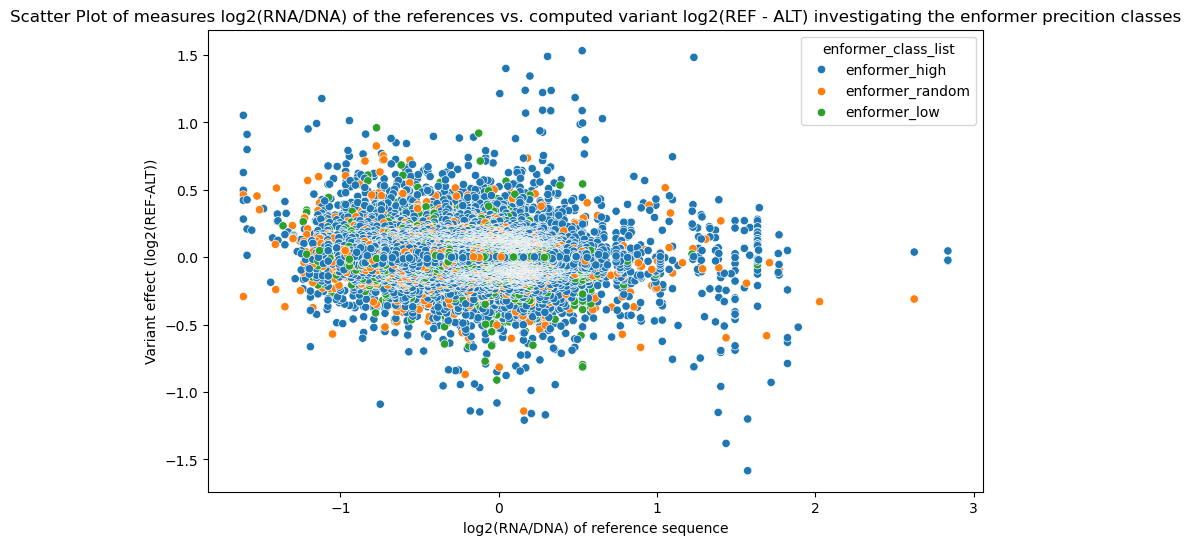

In [190]:
# Plot Ref_mean vs variant log2fc
merged_bcMPRAlm_exploded_enformer_class = merged_bcMPRAlm_rare_variants.explode('enformer_class_list')
merged_bcMPRAlm_exploded_enformer_class['is_enformer_high'] = merged_bcMPRAlm_exploded_enformer_class['enformer_class_list'].apply(is_enformer_high)
merged_bcMPRAlm_exploded_enformer_class['is_enformer_low'] = merged_bcMPRAlm_exploded_enformer_class['enformer_class_list'].apply(is_enformer_low)
plt.figure(figsize=(10, 6))
# sns.scatterplot(data=merged_bcMPRAlm_exploded_enformer_class, x='REF_mean_log2', y='variant_log2FC', hue='is_enformer_high')
# sns.scatterplot(data=merged_bcMPRAlm_exploded_enformer_class, x='REF_mean_log2', y='variant_log2FC', hue='is_enformer_low')
sns.scatterplot(data=merged_bcMPRAlm_exploded_enformer_class, x='REF_mean_log2', y='variant_log2FC', hue='enformer_class_list')

# Add labels and title
plt.xlabel('log2(RNA/DNA) of reference sequence')
plt.ylabel('Variant effect (log2(REF-ALT))')
plt.title('Scatter Plot of measures log2(RNA/DNA) of the references vs. computed variant log2(REF - ALT) investigating the enformer precition classes')

# Show the plot
plt.show()

Look at the bins and what the proportion looks like for the enformer predictions

/tmp/ipykernel_53984/991727544.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = merged_bcMPRAlm_exploded_enformer_class.groupby(['REF_mean_log2_bin', 'enformer_class_list']).size().unstack(fill_value=0)


<Figure size 1000x600 with 0 Axes>

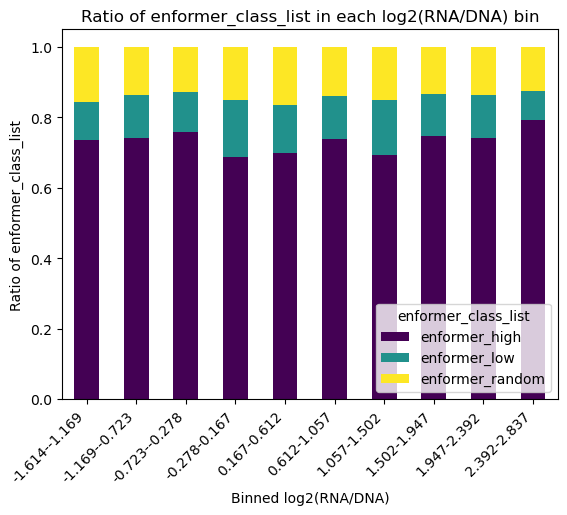

In [191]:
# Calculate the range of REF_mean_log2
min_value = merged_bcMPRAlm_exploded_enformer_class['REF_mean_log2'].min()
max_value = merged_bcMPRAlm_exploded_enformer_class['REF_mean_log2'].max()
# max_value = 2

# Define the number of bins
num_bins = 10

# Prepare bin edges
bin_edges = np.linspace(min_value, max_value, num_bins + 1)
bin_edges
# Prepare bin labels
bin_labels = [f'{round(bin_edges[i],3)}-{round(bin_edges[i+1], 3)}' for i in range(len(bin_edges) - 1)]
bin_labels
# # Create bins for REF_mean_log2 with specified labels
merged_bcMPRAlm_exploded_enformer_class['REF_mean_log2_bin'] = pd.qcut(merged_bcMPRAlm_exploded_enformer_class['REF_mean_log2'], q=num_bins, labels=bin_labels)

# merged_bcMPRAlm_exploded_enformer_class['REF_mean_log2_bin'] = pd.cut(merged_bcMPRAlm_exploded_enformer_class['REF_mean_log2'], bins=bin_edges, labels=bin_labels, right=False)

# Sample code to compute ratio of 'enformer_class_list' within each 'REF_mean_log2_bin'
bin_group = merged_bcMPRAlm_exploded_enformer_class.groupby(['REF_mean_log2_bin', 'enformer_class_list']).size().unstack(fill_value=0)
bin_group = bin_group.div(bin_group.sum(axis=1), axis=0)

# Plot the stacked bar plot
plt.figure(figsize=(10, 6))
ax = bin_group.plot(kind='bar', stacked=True, colormap='viridis')

# Add labels and title
plt.xlabel('Binned log2(RNA/DNA)')
plt.ylabel('Ratio of enformer_class_list')
plt.title('Ratio of enformer_class_list in each log2(RNA/DNA) bin')

# Show the plot
plt.legend(title='enformer_class_list', loc='lower right')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


# # Annotate the number of observations in each group
# for index, row in bin_group.iterrows():
#     ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')


plt.show()

# Reset index to make 'REF_mean_log2_bin' a regular column
# bin_group.reset_index(inplace=True)

# # Create the bar plot
# plt.figure(figsize=(10, 6))
# ax = sns.barplot(data=bin_group, x='REF_mean_log2_bin', y='ratio_significant', palette='viridis')

# # Add labels and title
# plt.xlabel('Binned log2(RNA/DNA)')
# plt.ylabel('Ratio of Significant Variants')
# plt.title('Ratio of Significant Variants in each log2(RNA/DNA) bin')
# Rotate x-axis labels by 45 degrees


# # Show the plot
# plt.show()

#### More precisely on enformer high

In [192]:
merged_bcMPRAlm_exploded_enformer_class['is_enformer_high'].value_counts()

is_enformer_high
yes    14126
no      5132
Name: count, dtype: int64

In [193]:
def plot_enformer_high_for_df(df, title='All variants'):
    # Calculate the range of REF_mean_log2
    min_value = df['REF_mean_log2'].min()
    max_value = df['REF_mean_log2'].max()
    # max_value = 2

    # Define the number of bins
    num_bins = 10

    # Prepare bin edges
    bin_edges = np.linspace(min_value, max_value, num_bins + 1)
    bin_edges
    # Prepare bin labels
    bin_labels = [f'{round(bin_edges[i],3)}-{round(bin_edges[i+1], 3)}' for i in range(len(bin_edges) - 1)]
    bin_labels
    # # Create bins for REF_mean_log2 with specified labels
    df['REF_mean_log2_bin'] = pd.qcut(df['REF_mean_log2'], q=num_bins, labels=bin_labels)


    # Group by the bins and count the number of significant and non-significant variants
    bin_group = df.groupby(['REF_mean_log2_bin', 'is_enformer_high']).size().unstack(fill_value=0)

    # Calculate the ratio of significant variants in each bin
    bin_group['ratio_enformer_high'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])


    # Reset index to make 'REF_mean_log2_bin' a regular column
    bin_group.reset_index(inplace=True)

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=bin_group, x='REF_mean_log2_bin', y='ratio_enformer_high', palette='viridis')

    # Add labels and title
    plt.xlabel('Binned log2(RNA/DNA)')
    plt.ylabel('Ratio of Enformer high prediction')
    plt.title(f'Ratio of Enformer high prediction in each log2(RNA/DNA) bin ({title})')
    # Rotate x-axis labels by 45 degrees
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


    # Annotate the number of observations in each group
    for index, row in bin_group.iterrows():
        ax.text(index, row['ratio_enformer_high'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')


    plt.show()

/tmp/ipykernel_53984/1489573940.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = df.groupby(['REF_mean_log2_bin', 'is_enformer_high']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/1489573940.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group, x='REF_mean_log2_bin', y='ratio_enformer_high', palette='viridis')
/tmp/ipykernel_53984/1489573940.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


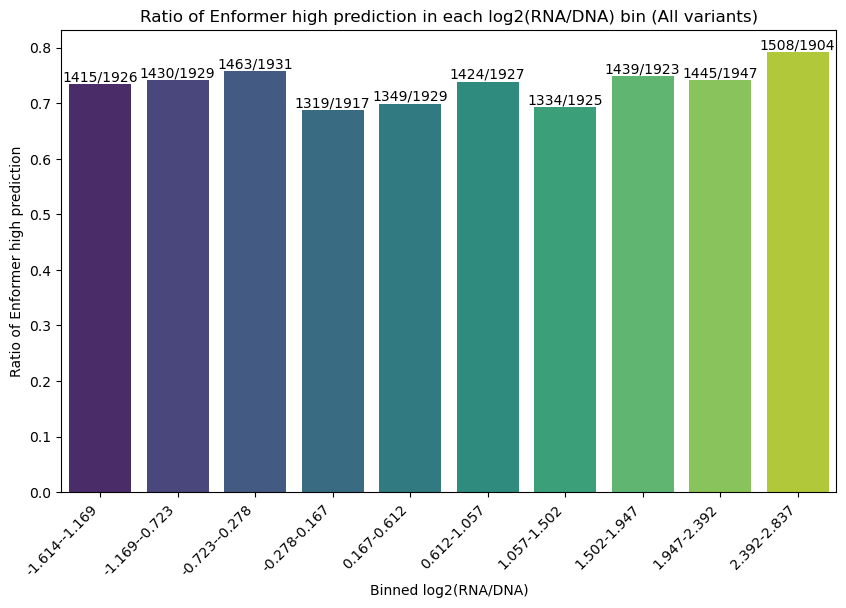

/tmp/ipykernel_53984/1489573940.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['REF_mean_log2_bin'] = pd.qcut(df['REF_mean_log2'], q=num_bins, labels=bin_labels)
/tmp/ipykernel_53984/1489573940.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = df.groupby(['REF_mean_log2_bin', 'is_enformer_high']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/1489573940.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same 

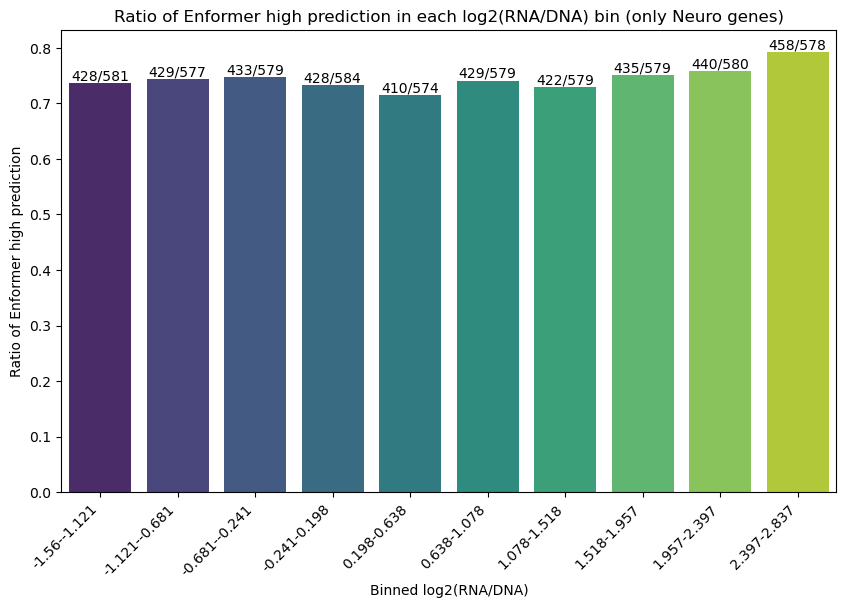

/tmp/ipykernel_53984/1489573940.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['REF_mean_log2_bin'] = pd.qcut(df['REF_mean_log2'], q=num_bins, labels=bin_labels)
/tmp/ipykernel_53984/1489573940.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = df.groupby(['REF_mean_log2_bin', 'is_enformer_high']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/1489573940.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same 

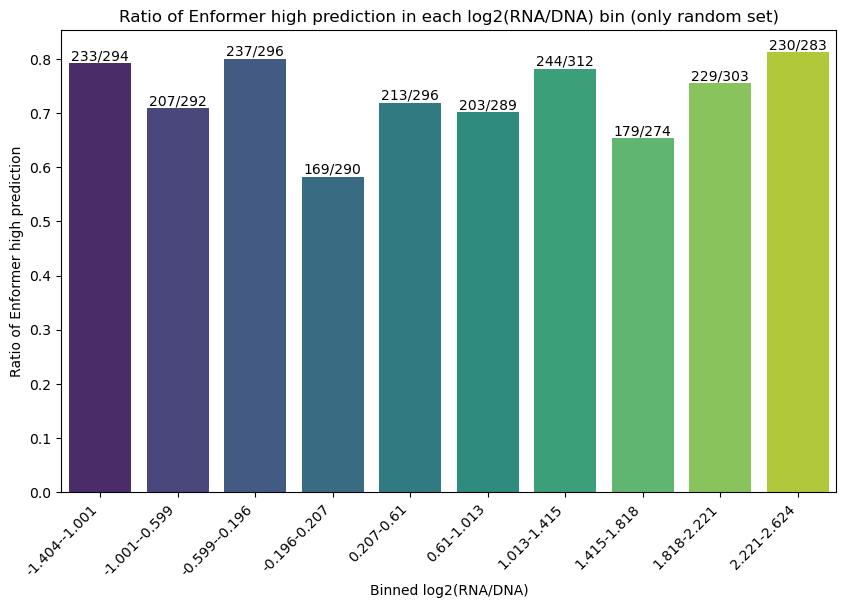

In [194]:
plot_enformer_high_for_df(merged_bcMPRAlm_exploded_enformer_class)
plot_enformer_high_for_df(merged_bcMPRAlm_exploded_enformer_class.loc[merged_bcMPRAlm_exploded_enformer_class['gene_set_list'].apply(lambda x: True if 'neuro' in x else False)], 'only Neuro genes')
plot_enformer_high_for_df(merged_bcMPRAlm_exploded_enformer_class.loc[merged_bcMPRAlm_exploded_enformer_class['gene_set_list'].apply(lambda x: True if 'random' in x else False)], 'only random set')

In [195]:
merged_bcMPRAlm_exploded_enformer_class.loc[merged_bcMPRAlm_exploded_enformer_class['gene_set_list'].apply(lambda x: True if 'neuro' in x else False)]['gene_set_list'].value_counts()

gene_set_list
[neuro]             5511
[cardiac, neuro]     232
[cava, neuro]         47
Name: count, dtype: int64

In [196]:
merged_bcMPRAlm_exploded_enformer_class['gene_set_list'].value_counts()
# merged_bcMPRAlm_exploded_enformer_class['variant_type_list'].value_counts()

gene_set_list
[neuro]             5511
[cardiac]           5244
[cava]              5203
[random]            2929
[cardiac, neuro]     232
[cava, cardiac]       92
[cava, neuro]         47
Name: count, dtype: int64

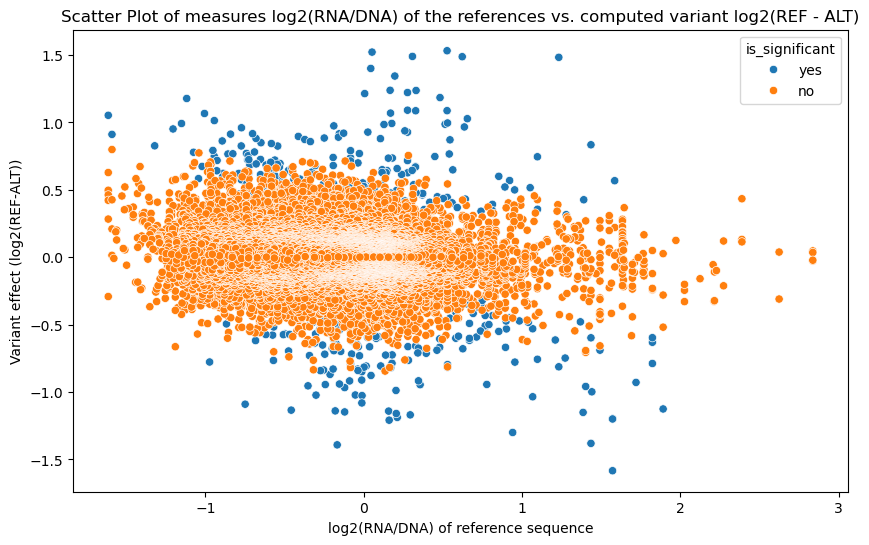

In [197]:
# Plot Ref_mean vs variant log2fc
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_bcMPRAlm_snakeflow_info, x='REF_mean_log2', y='variant_log2FC', hue='is_significant')

# Add labels and title
plt.xlabel('log2(RNA/DNA) of reference sequence')
plt.ylabel('Variant effect (log2(REF-ALT))')
plt.title('Scatter Plot of measures log2(RNA/DNA) of the references vs. computed variant log2(REF - ALT)')

# Show the plot
plt.show()

#### Binning and showing significant proportion

/tmp/ipykernel_53984/343877469.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = merged_bcMPRAlm_snakeflow_info.groupby(['REF_mean_log2_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/343877469.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group, x='REF_mean_log2_bin', y='ratio_significant', palette='viridis')
/tmp/ipykernel_53984/343877469.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


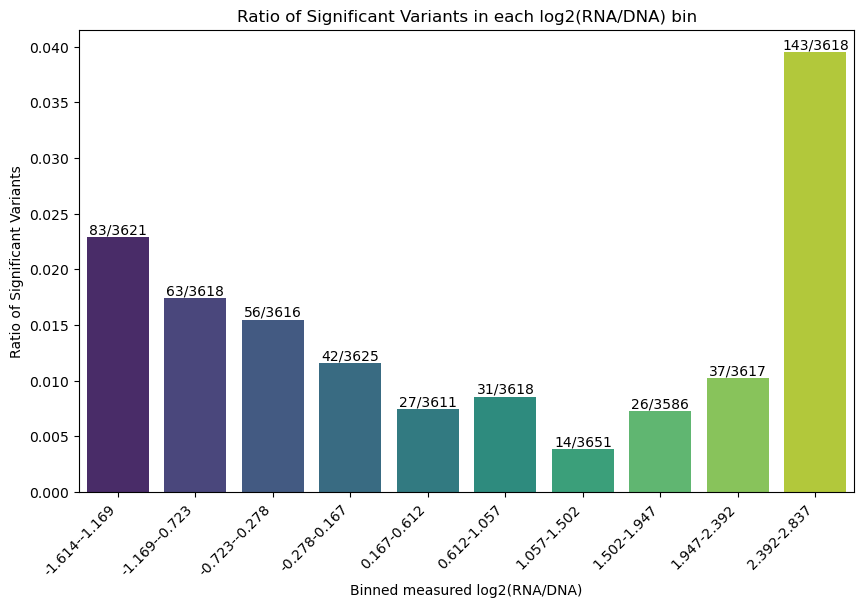

In [198]:
# Calculate the range of REF_mean_log2
min_value = merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].min()
max_value = merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].max()
# max_value = 2

# Define the number of bins
num_bins = 10

# Prepare bin edges
bin_edges = np.linspace(min_value, max_value, num_bins + 1)
bin_edges
# Prepare bin labels
bin_labels = [f'{round(bin_edges[i],3)}-{round(bin_edges[i+1], 3)}' for i in range(len(bin_edges) - 1)]
bin_labels
# # Create bins for REF_mean_log2 with specified labels
merged_bcMPRAlm_snakeflow_info['REF_mean_log2_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info['REF_mean_log2'], q=num_bins, labels=bin_labels)

# merged_bcMPRAlm_snakeflow_info['REF_mean_log2_bin'] = pd.cut(merged_bcMPRAlm_snakeflow_info['REF_mean_log2'], bins=bin_edges, labels=bin_labels, right=False)

# Group by the bins and count the number of significant and non-significant variants
bin_group = merged_bcMPRAlm_snakeflow_info.groupby(['REF_mean_log2_bin', 'is_significant']).size().unstack(fill_value=0)

# Calculate the ratio of significant variants in each bin
bin_group['ratio_significant'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])

# Reset index to make 'REF_mean_log2_bin' a regular column
bin_group.reset_index(inplace=True)

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=bin_group, x='REF_mean_log2_bin', y='ratio_significant', palette='viridis')

# Add labels and title
plt.xlabel('Binned measured log2(RNA/DNA)')
plt.ylabel('Ratio of Significant Variants')
plt.title('Ratio of Significant Variants in each log2(RNA/DNA) bin')
# Rotate x-axis labels by 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


# Annotate the number of observations in each group
for index, row in bin_group.iterrows():
    ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

# if storing:
#     plt.savefig(os.path.join(plot_directory, f'significant_ratio_per_binned_dnase_{name_addition}{column_name}.png'), dpi=300, bbox_inches='tight')

# plt.savefig(os.path.join(plot_directory, f'significant_ratio_per_binned_measured_log2FC_all_results.png'), dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [199]:
plot_directory = "/home/kisa/coding/80K_MPRA/ESHG_plots"

#### Add effect direction to plot

In [273]:
def merge_bin_description(row, column_name):
    """Expect row to have REF_mean_log2_bin, pos, neg columns"""
    return f"{row[column_name + '_bin']} (+: {row['pos']}, -: {row['neg']})"

In [218]:
# bin_group_effect_direction_reset = bin_group_effect_direction.reset_index().reset_index()[['REF_mean_log2_bin', 'pos', 'neg']]
# bin_group_effect_direction_reset

In [217]:
# bin_group_effect_direction_reset['REF_mean_log2_bin'] + [" (pos: "] + bin_group_effect_direction_reset['pos'] + [", neg: "] + bin_group_effect_direction_reset['neg'] + [")"]

In [221]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'chr_pos_ref_alt',
       'sequence_DNase_max', 'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_varian

In [227]:
bin_group_effect_direction


effect_direction,REF_mean_log2_bin,neg,pos,merged_bin_description
0,-1.614--1.169,10,73,"-1.614--1.169 (pos: 73, neg: 10)"
1,-1.169--0.723,21,42,"-1.169--0.723 (pos: 42, neg: 21)"
2,-0.723--0.278,32,24,"-0.723--0.278 (pos: 24, neg: 32)"
3,-0.278-0.167,22,20,"-0.278-0.167 (pos: 20, neg: 22)"
4,0.167-0.612,18,9,"0.167-0.612 (pos: 9, neg: 18)"
5,0.612-1.057,17,14,"0.612-1.057 (pos: 14, neg: 17)"
6,1.057-1.502,9,5,"1.057-1.502 (pos: 5, neg: 9)"
7,1.502-1.947,13,13,"1.502-1.947 (pos: 13, neg: 13)"
8,1.947-2.392,24,13,"1.947-2.392 (pos: 13, neg: 24)"
9,2.392-2.837,85,58,"2.392-2.837 (pos: 58, neg: 85)"


In [230]:
merged_bin_group

,REF_mean_log2_bin,no,yes,ratio_significant,neg,pos,merged_bin_description
0,-1.614--1.169,3538,83,0.022922,10,73,"-1.614--1.169 (pos: 73, neg: 10)"
1,-1.169--0.723,3555,63,0.017413,21,42,"-1.169--0.723 (pos: 42, neg: 21)"
2,-0.723--0.278,3560,56,0.015487,32,24,"-0.723--0.278 (pos: 24, neg: 32)"
3,-0.278-0.167,3583,42,0.011586,22,20,"-0.278-0.167 (pos: 20, neg: 22)"
4,0.167-0.612,3584,27,0.007477,18,9,"0.167-0.612 (pos: 9, neg: 18)"
5,0.612-1.057,3587,31,0.008568,17,14,"0.612-1.057 (pos: 14, neg: 17)"
6,1.057-1.502,3637,14,0.003835,9,5,"1.057-1.502 (pos: 5, neg: 9)"
7,1.502-1.947,3560,26,0.007250,13,13,"1.502-1.947 (pos: 13, neg: 13)"
8,1.947-2.392,3580,37,0.010229,24,13,"1.947-2.392 (pos: 13, neg: 24)"
9,2.392-2.837,3475,143,0.039525,85,58,"2.392-2.837 (pos: 58, neg: 85)"


/tmp/ipykernel_53984/2812258089.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group = merged_bcMPRAlm_snakeflow_info.groupby(['REF_mean_log2_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/2812258089.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby(['REF_mean_log2_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_53984/2812258089.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` 

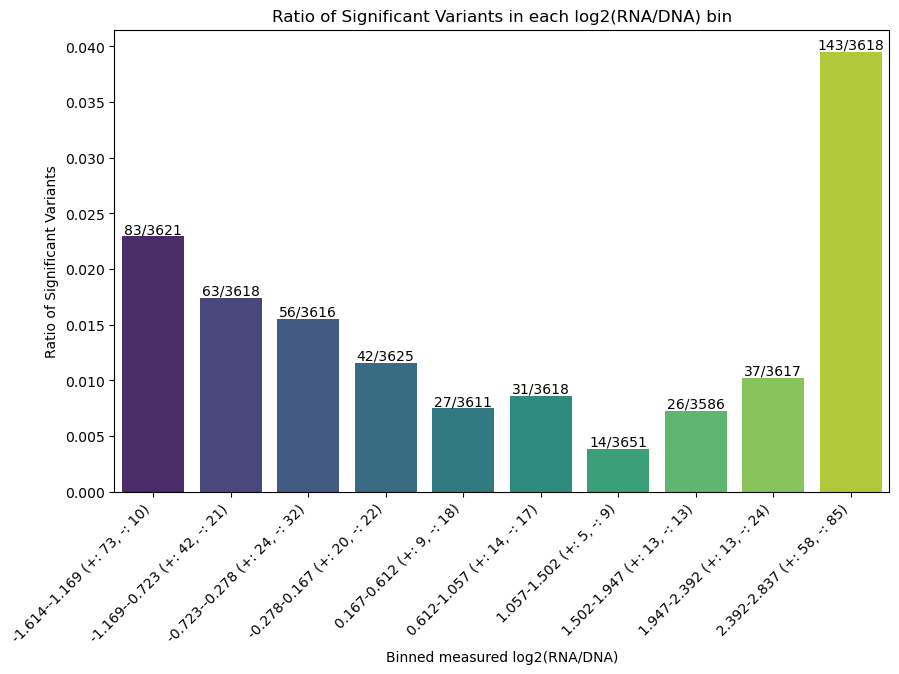

In [275]:
# Calculate the range of REF_mean_log2
min_value = merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].min()
max_value = merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].max()
# max_value = 2

# Define the number of bins
num_bins = 10

# Prepare bin edges
bin_edges = np.linspace(min_value, max_value, num_bins + 1)
bin_edges
# Prepare bin labels
bin_labels = [f'{round(bin_edges[i],3)}-{round(bin_edges[i+1], 3)}' for i in range(len(bin_edges) - 1)]
bin_labels
# # Create bins for REF_mean_log2 with specified labels
merged_bcMPRAlm_snakeflow_info['REF_mean_log2_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info['REF_mean_log2'], q=num_bins, labels=bin_labels)

# merged_bcMPRAlm_snakeflow_info['REF_mean_log2_bin'] = pd.cut(merged_bcMPRAlm_snakeflow_info['REF_mean_log2'], bins=bin_edges, labels=bin_labels, right=False)

# Group by the bins and count the number of significant and non-significant variants
bin_group = merged_bcMPRAlm_snakeflow_info.groupby(['REF_mean_log2_bin', 'is_significant']).size().unstack(fill_value=0)

# only significant:
significant_merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['adj.P.Val'] < 0.05]

# Calculate the ratio of significant variants in each bin
bin_group['ratio_significant'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])

# group for getting the number of pos and neg
bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby(['REF_mean_log2_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
# bin_group['ratio_'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])
bin_group_effect_direction['merged_bin_description'] = bin_group_effect_direction.apply(lambda x: merge_bin_description(x, 'REF_mean_log2'), axis=1)

# Reset index to make 'REF_mean_log2_bin' a regular column
bin_group.reset_index(inplace=True)

# merge bin_group_effect_direction and bin_group
bin_group = bin_group.merge(bin_group_effect_direction, on="REF_mean_log2_bin", how='left')

# Create the bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=bin_group, x='merged_bin_description', y='ratio_significant', palette='viridis')

# Add labels and title
plt.xlabel('Binned measured log2(RNA/DNA)')
plt.ylabel('Ratio of Significant Variants')
plt.title('Ratio of Significant Variants in each log2(RNA/DNA) bin')
# Rotate x-axis labels by 45 degrees
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


# Annotate the number of observations in each group
for index, row in bin_group.iterrows():
    ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

# if storing:
#     plt.savefig(os.path.join(plot_directory, f'significant_ratio_per_binned_dnase_{name_addition}{column_name}.png'), dpi=300, bbox_inches='tight')

# plt.savefig(os.path.join(plot_directory, f'significant_ratio_per_binned_measured_log2FC_all_results.png'), dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

In [ ]:
# make plot function out of it

In [276]:
def plot_binned_columns_significants_ratios_pos_neg(merged_bcMPRAlm_snakeflow_info, column_name, x_label, y_label, plot_title, storing=False, name_addition=''):
    # Calculate the range of column_name
    min_value_seq = merged_bcMPRAlm_snakeflow_info[column_name].min()
    max_value_seq = merged_bcMPRAlm_snakeflow_info[column_name].max()

    # Define the number of bins
    num_bins_seq = 10

    # Prepare bin edges
    bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

    # Prepare bin labels
    bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

    # Create bins for column_name with specified labels
    merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)

    # Group by the bins and count the number of significant and non-significant variants
    bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)

    # Calculate the ratio of significant variants in each bin
    bin_group_seq['ratio_significant'] = bin_group_seq['yes'] / (bin_group_seq['yes'] + bin_group_seq['no'])

    # only significant:
    significant_merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['adj.P.Val'] < 0.05]

    # group for getting the number of pos and neg
    bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
    # bin_group['ratio_'] = bin_group['yes'] / (bin_group['yes'] + bin_group['no'])
    bin_group_effect_direction['merged_bin_description'] = bin_group_effect_direction.apply(lambda x: merge_bin_description(x, column_name), axis=1)

    # Reset index to make column_name + '_bin' a regular column
    bin_group_seq.reset_index(inplace=True)

    # merge bin_group_effect_direction and bin_group
    bin_group_seq = bin_group_seq.merge(bin_group_effect_direction, on=column_name + '_bin', how='left')

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=bin_group_seq, x='merged_bin_description', y='ratio_significant', palette='viridis')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(plot_title)

    # x limit
    plt.ylim(0,0.044)

    # Rotate x-axis labels by 45 degrees
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Annotate the number of observations in each group
    for index, row in bin_group_seq.iterrows():
        ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

    if storing:
        plt.savefig(os.path.join(plot_directory, f'pos_neg_significant_ratio_per_binned_dnase_{column_name}{name_addition}.png'), dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()


In [246]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'chr_pos_ref_alt',
       'sequence_DNase_max', 'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_varian

/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_53984/463937198.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

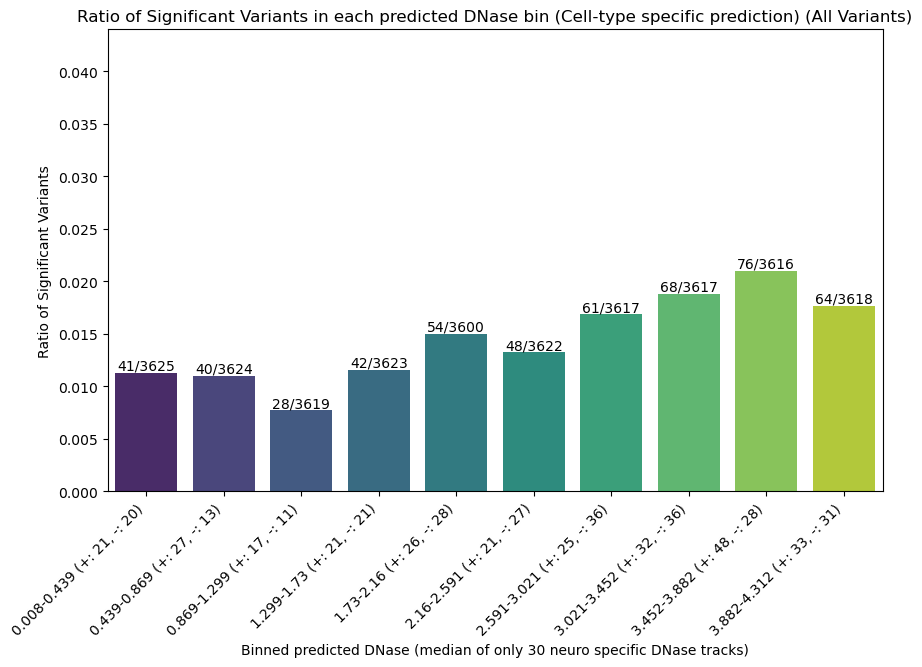

/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_53984/463937198.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

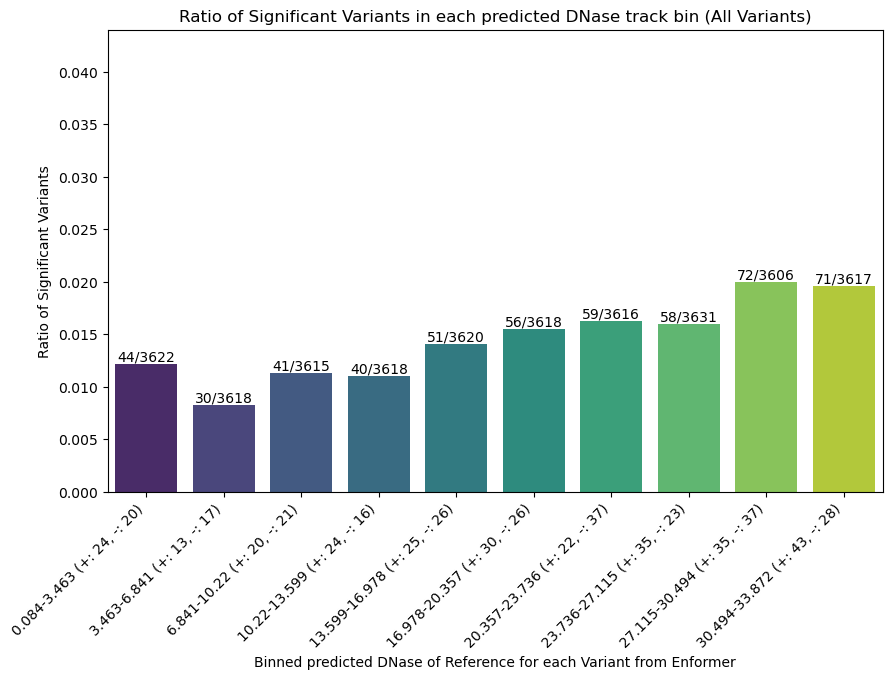

/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_53984/463937198.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

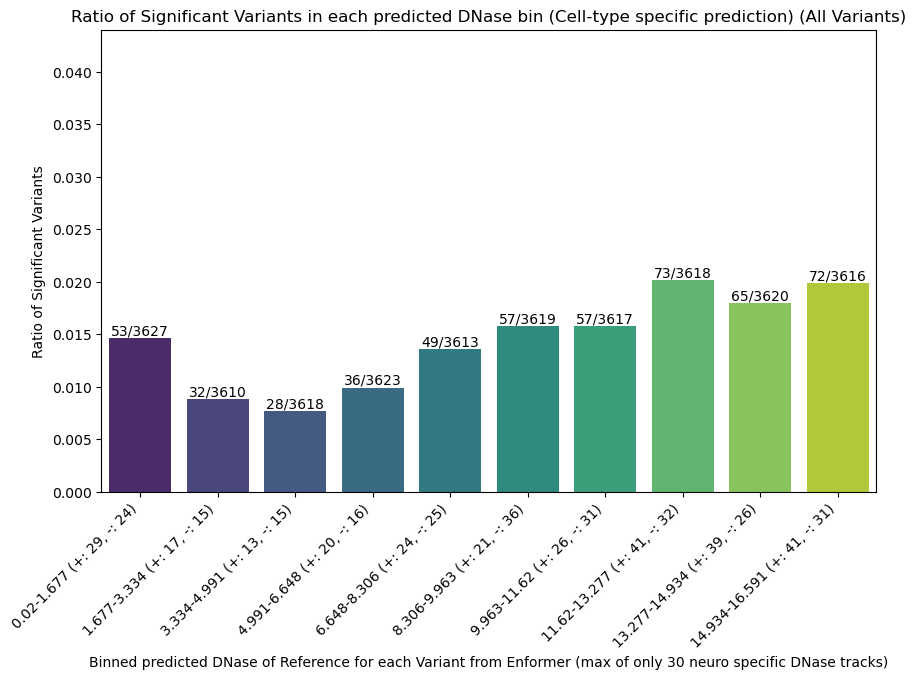

/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_53984/463937198.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

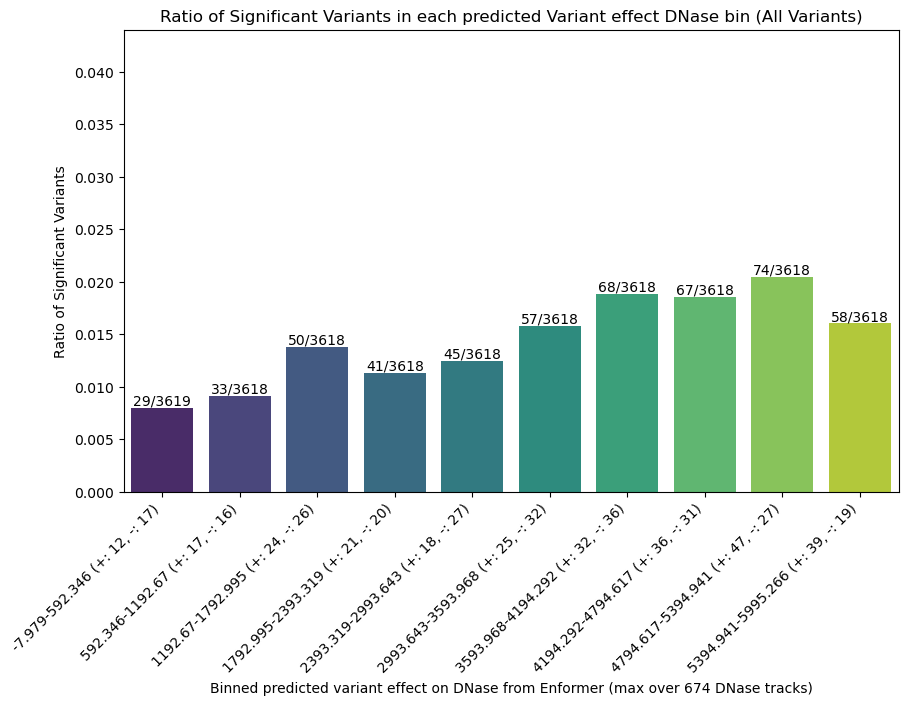

/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_53984/463937198.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

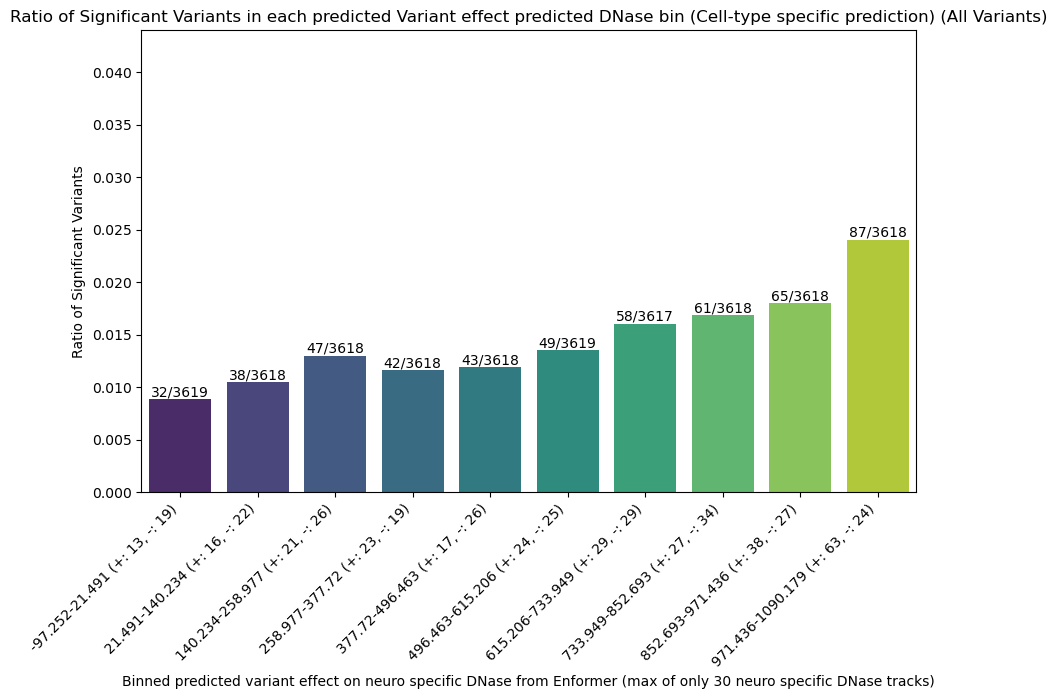

/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_effect_direction = significant_merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'effect_direction']).size().unstack(fill_value=0).reset_index()
/tmp/ipykernel_53984/463937198.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

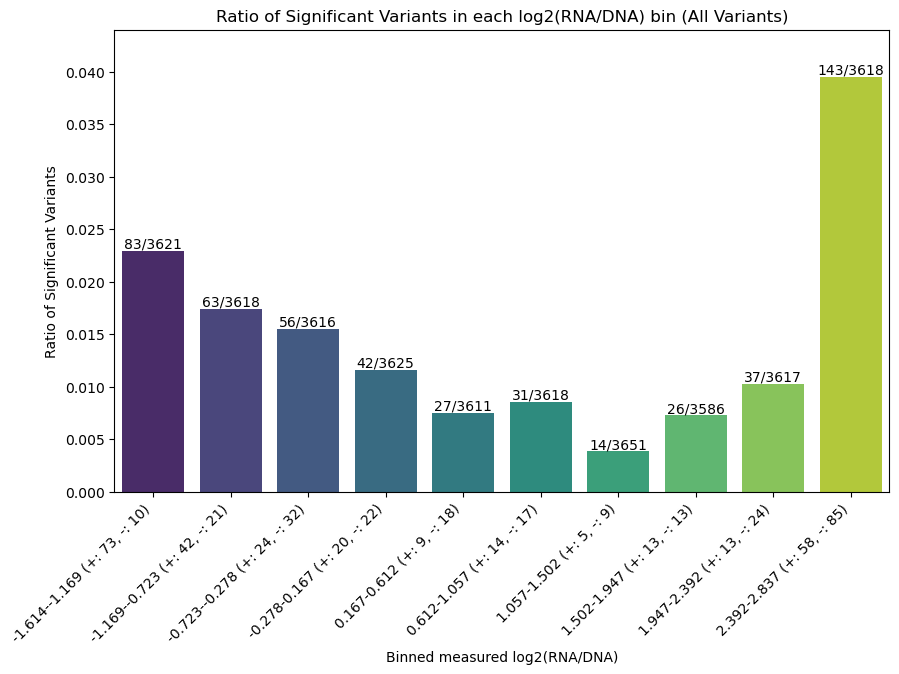

In [277]:
plot_binned_columns_significants_ratios_pos_neg(merged_bcMPRAlm_snakeflow_info, 'neuro_specific_DNase_median', 'Binned predicted DNase (median of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction) (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios_pos_neg(merged_bcMPRAlm_snakeflow_info, 'sequence_DNase_max', 'Binned predicted DNase of Reference for each Variant from Enformer', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase track bin (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios_pos_neg(merged_bcMPRAlm_snakeflow_info, 'neuro_specific_DNase_max', 'Binned predicted DNase of Reference for each Variant from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction) (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios_pos_neg(merged_bcMPRAlm_snakeflow_info, 'variant_specific_DNase_max', 'Binned predicted variant effect on DNase from Enformer (max over 674 DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted Variant effect DNase bin (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios_pos_neg(merged_bcMPRAlm_snakeflow_info, 'neuro_specific_variant_DNase_max', 'Binned predicted variant effect on neuro specific DNase from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted Variant effect predicted DNase bin (Cell-type specific prediction) (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios_pos_neg(merged_bcMPRAlm_snakeflow_info, 'REF_mean_log2', 'Binned measured log2(RNA/DNA)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each log2(RNA/DNA) bin (All Variants)', storing=True, name_addition='_all_results_')

#### only neuro variants

In [259]:
only_neuro_merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['gene_set_list'].apply(lambda x: hf.is_element_of(x, 'neuro'))]

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

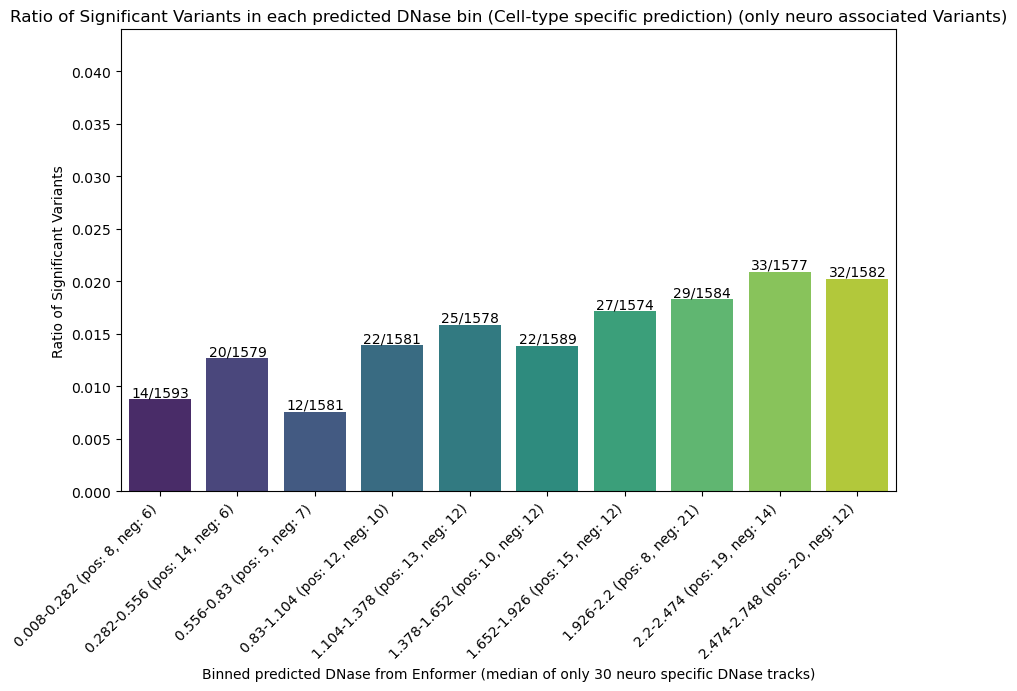

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

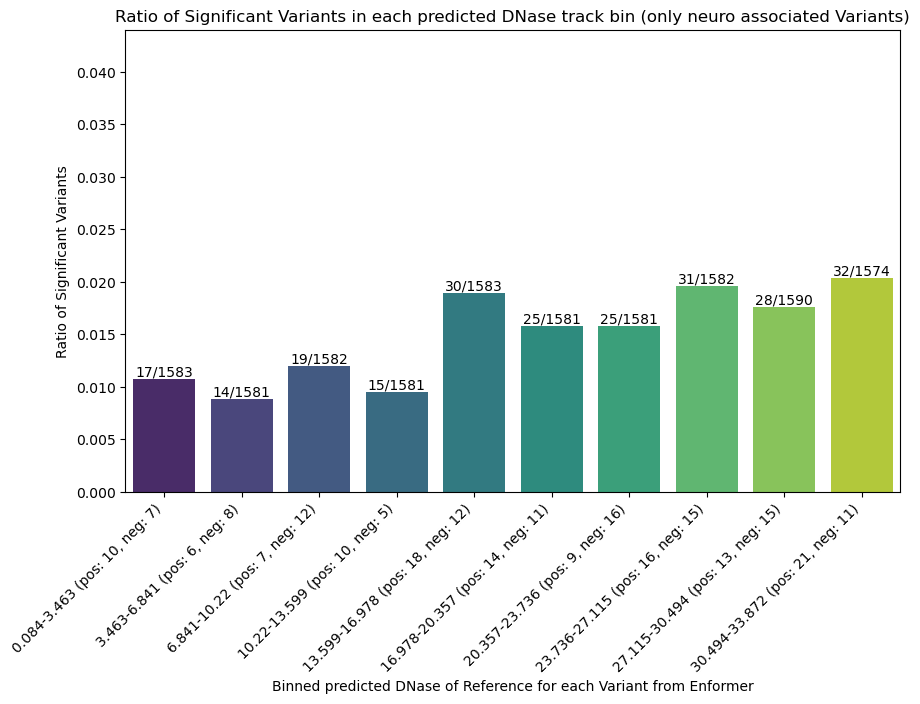

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

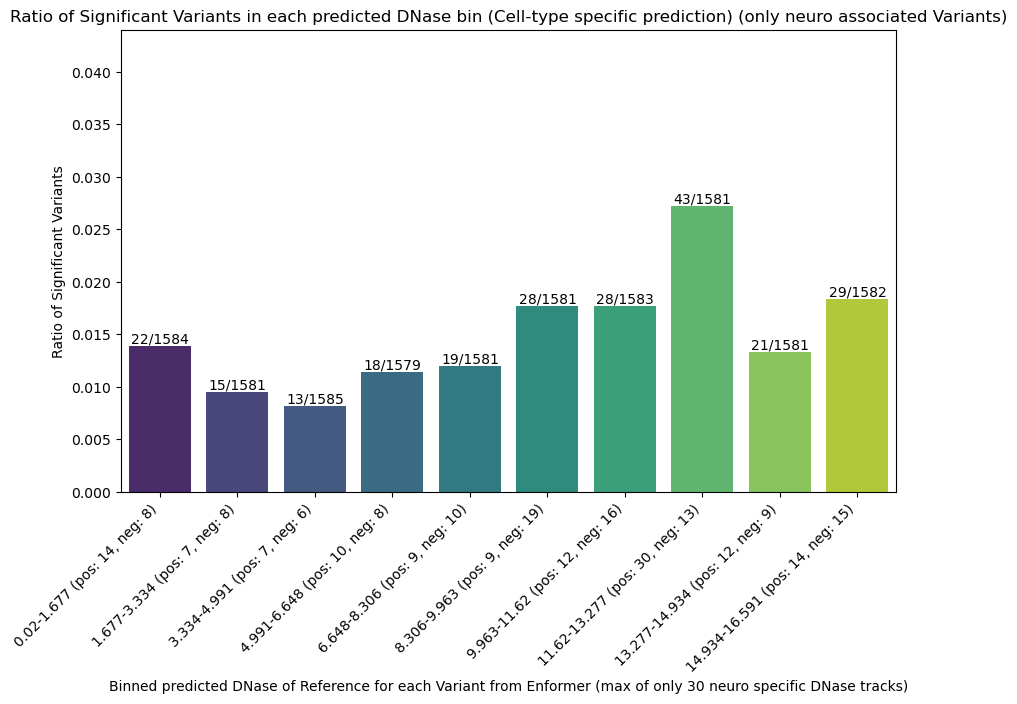

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

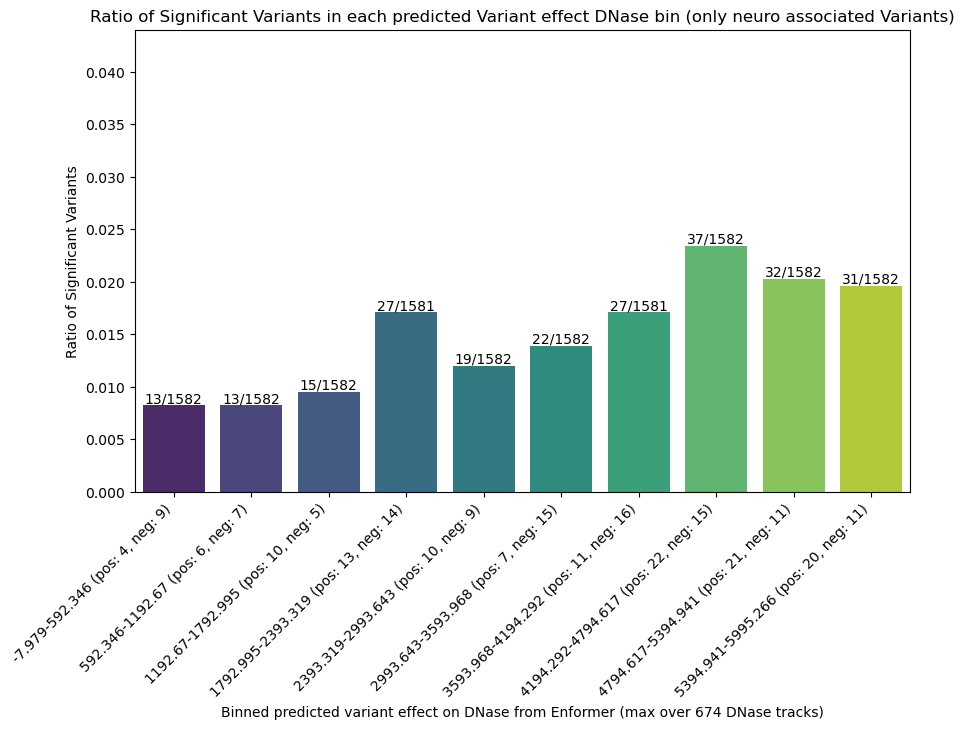

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

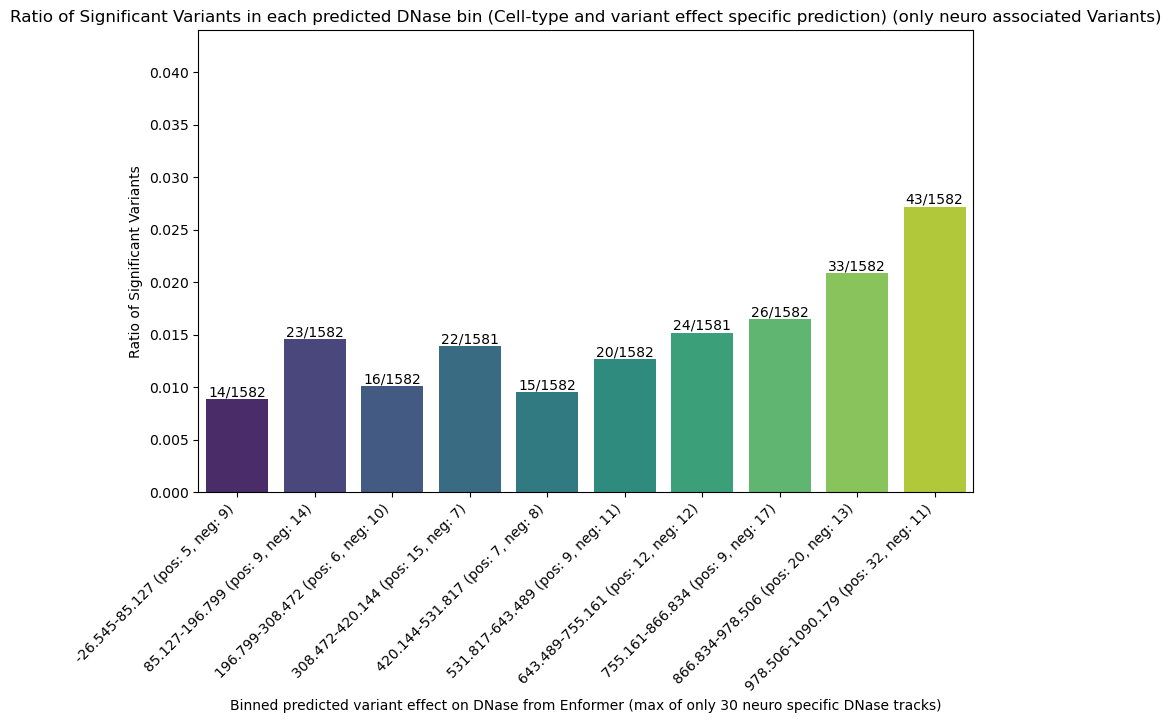

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

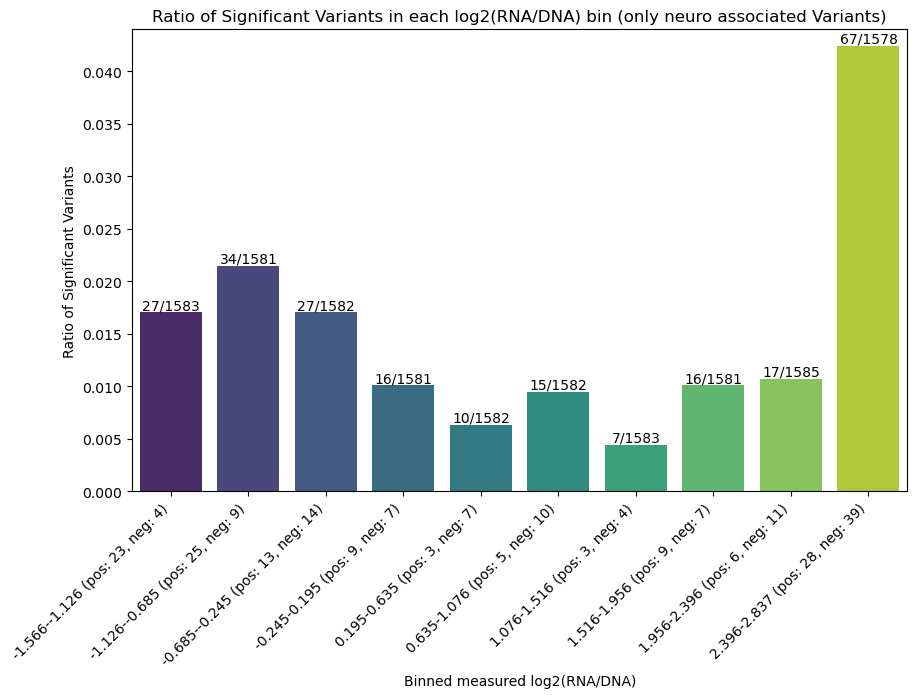

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

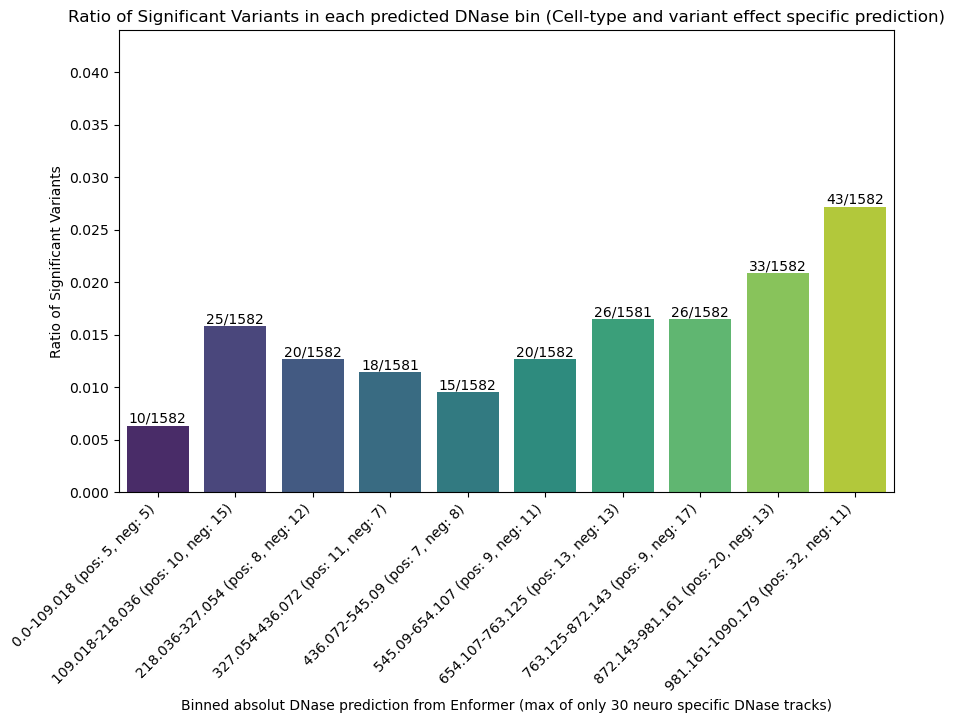

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

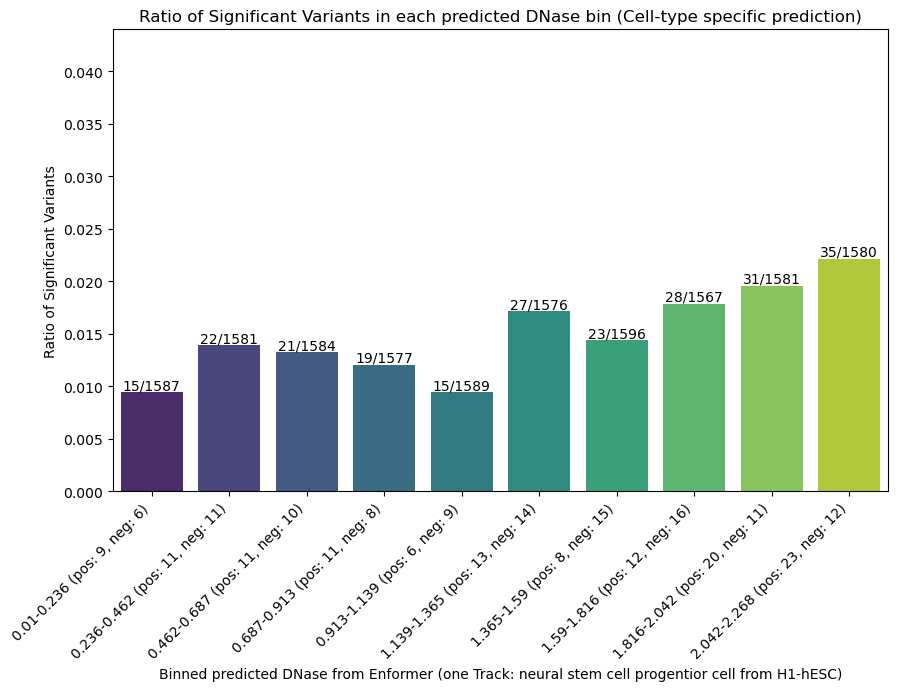

/tmp/ipykernel_53984/463937198.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_53984/463937198.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_53984/463937198.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to Tru

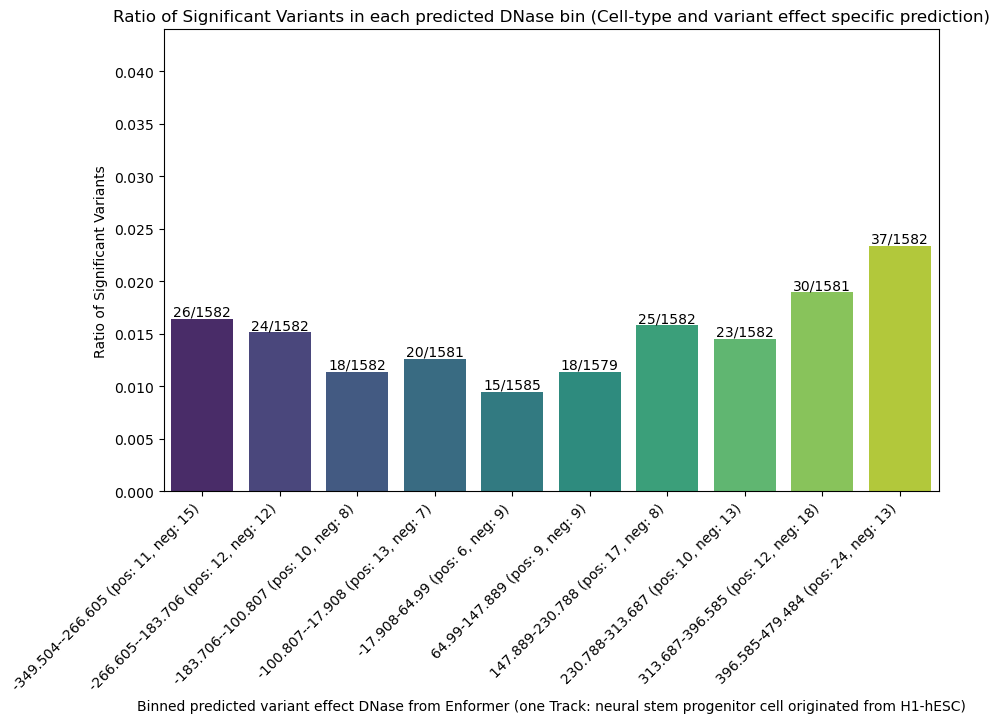

In [263]:
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'neuro_specific_DNase_median', 'Binned predicted DNase from Enformer (median of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction) (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'sequence_DNase_max', 'Binned predicted DNase of Reference for each Variant from Enformer', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase track bin (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'neuro_specific_DNase_max', 'Binned predicted DNase of Reference for each Variant from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction) (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'variant_specific_DNase_max', 'Binned predicted variant effect on DNase from Enformer (max over 674 DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted Variant effect DNase bin (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'neuro_specific_variant_DNase_max', 'Binned predicted variant effect on DNase from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type and variant effect specific prediction) (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'REF_mean_log2', 'Binned measured log2(RNA/DNA)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each log2(RNA/DNA) bin (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'neuro_specific_variant_abs_DNase_max', 'Binned absolut DNase prediction from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type and variant effect specific prediction)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'Binned predicted DNase from Enformer (one Track: neural stem cell progentior cell from H1-hESC)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios_pos_neg(only_neuro_merged_bcMPRAlm_snakeflow_info, 'variant_DNASE:neural stem progenitor cell originated from H1-hESC', 'Binned predicted variant effect DNase from Enformer (one Track: neural stem progenitor cell originated from H1-hESC)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type and variant effect specific prediction)', storing=True, name_addition='_only_neuro_')

#### Similar idea now using the sequence predictions of the references
##### Plot different predictions and measurements correlation to significants ratios
- dnase_columns = ['sequence_DNase_max', 'sequence_max_col',
       'neuro_specific_DNase_median', 'neuro_specific_DNase_max',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'REF_DNASE:neural stem progenitor cell originated from H1-hESC',
       'variant_DNASE:neural stem progenitor cell originated from H1-hESC']

In [ ]:
def plot_binned_columns_significants_ratios(merged_bcMPRAlm_snakeflow_info, column_name, x_label, y_label, plot_title, storing=False, name_addition=''):
    # Calculate the range of column_name
    min_value_seq = merged_bcMPRAlm_snakeflow_info[column_name].min()
    max_value_seq = merged_bcMPRAlm_snakeflow_info[column_name].max()

    # Define the number of bins
    num_bins_seq = 10

    # Prepare bin edges
    bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

    # Prepare bin labels
    bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

    # Create bins for column_name with specified labels
    merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)

    # Group by the bins and count the number of significant and non-significant variants
    bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)

    # Calculate the ratio of significant variants in each bin
    bin_group_seq['ratio_significant'] = bin_group_seq['yes'] / (bin_group_seq['yes'] + bin_group_seq['no'])

    # Reset index to make column_name + '_bin' a regular column
    bin_group_seq.reset_index(inplace=True)

    # Create the bar plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=bin_group_seq, x=column_name + '_bin', y='ratio_significant', palette='viridis')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(plot_title)

    # x limit
    plt.ylim(0,0.044)

    # Rotate x-axis labels by 45 degrees
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # Annotate the number of observations in each group
    for index, row in bin_group_seq.iterrows():
        ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

    if storing:
        plt.savefig(os.path.join(plot_directory, f'significant_ratio_per_binned_dnase_{column_name}{name_addition}.png'), dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()


/tmp/ipykernel_113873/2348402480.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2348402480.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group_seq, x=column_name + '_bin', y='ratio_significant', palette='viridis')
/tmp/ipykernel_113873/2348402480.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


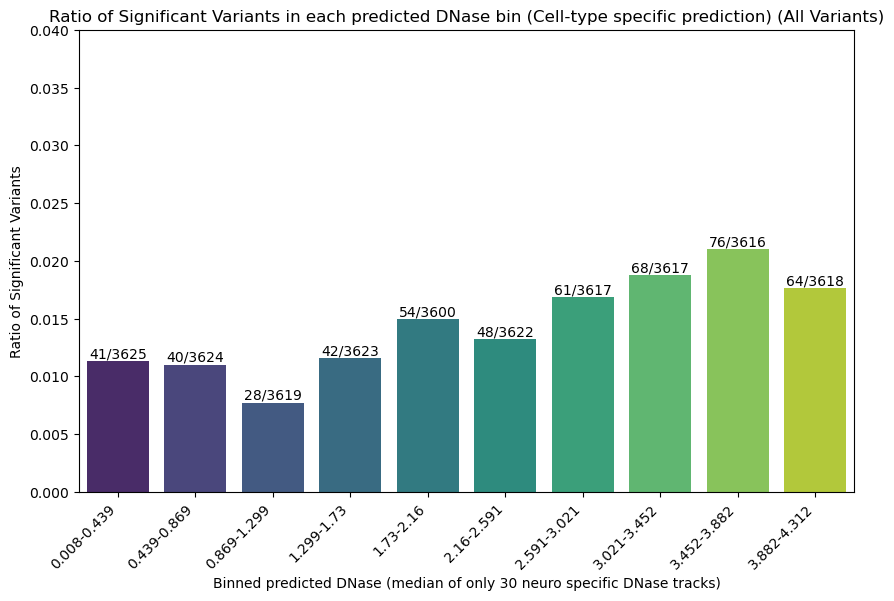

/tmp/ipykernel_113873/2348402480.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2348402480.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group_seq, x=column_name + '_bin', y='ratio_significant', palette='viridis')
/tmp/ipykernel_113873/2348402480.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


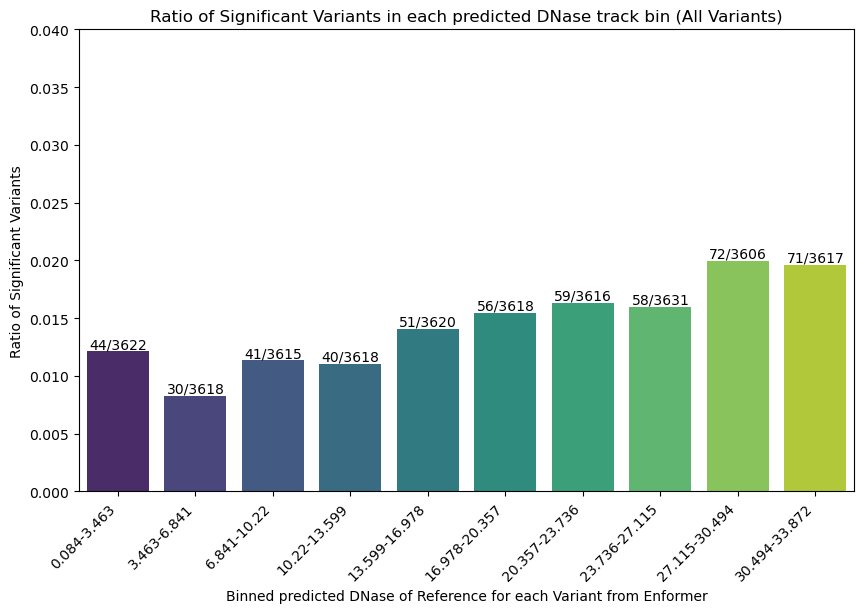

/tmp/ipykernel_113873/2348402480.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2348402480.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group_seq, x=column_name + '_bin', y='ratio_significant', palette='viridis')
/tmp/ipykernel_113873/2348402480.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


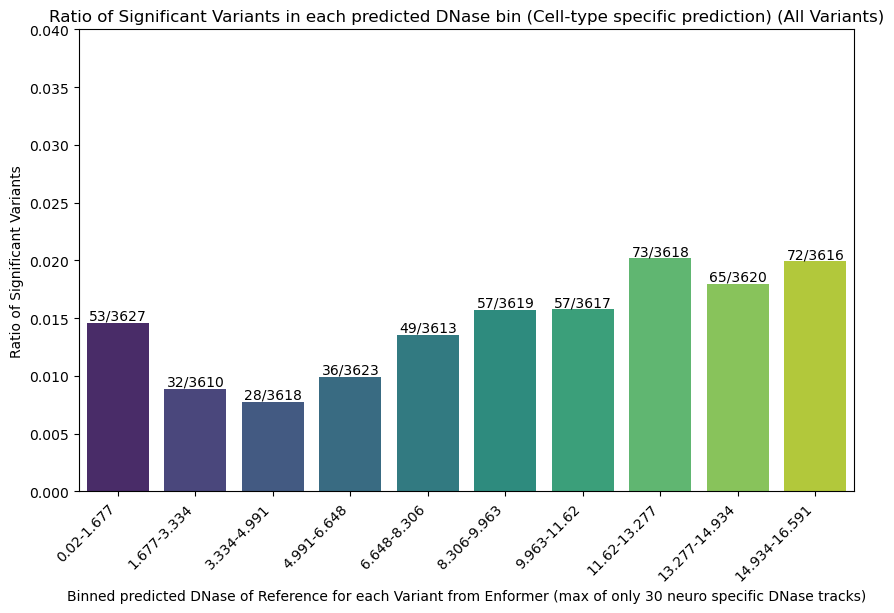

/tmp/ipykernel_113873/2348402480.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2348402480.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group_seq, x=column_name + '_bin', y='ratio_significant', palette='viridis')
/tmp/ipykernel_113873/2348402480.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


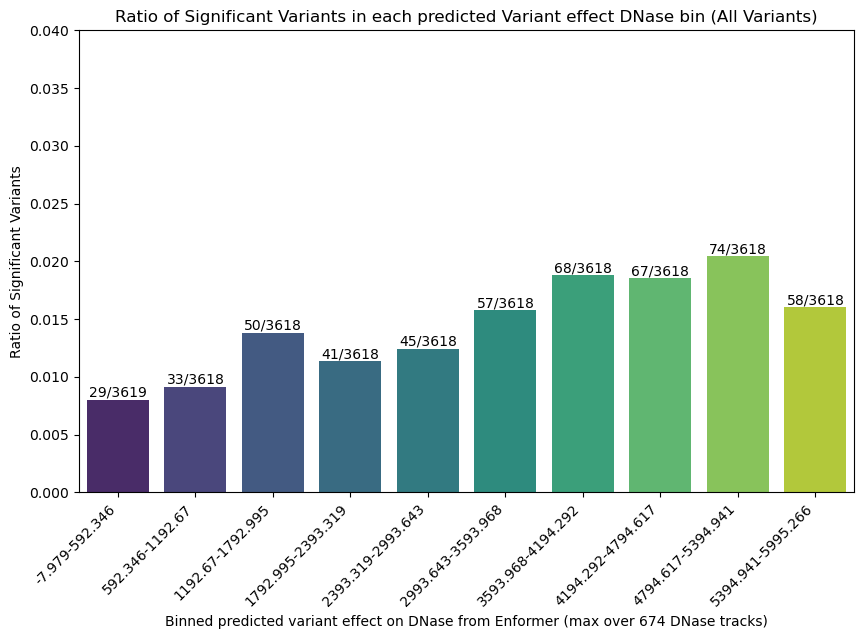

/tmp/ipykernel_113873/2348402480.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2348402480.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group_seq, x=column_name + '_bin', y='ratio_significant', palette='viridis')
/tmp/ipykernel_113873/2348402480.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


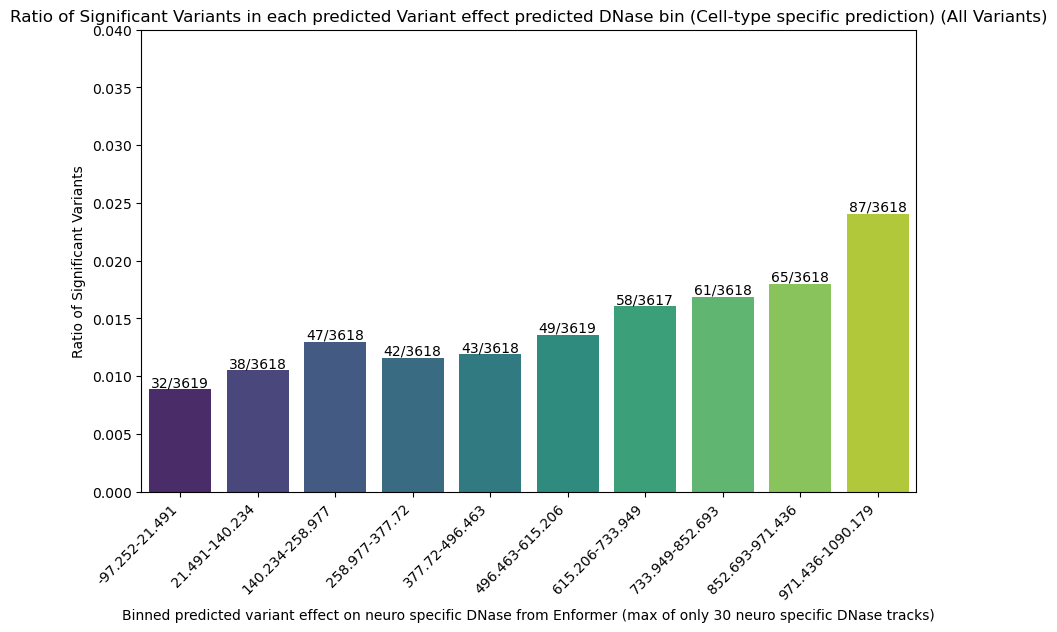

/tmp/ipykernel_113873/2348402480.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2348402480.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=bin_group_seq, x=column_name + '_bin', y='ratio_significant', palette='viridis')
/tmp/ipykernel_113873/2348402480.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


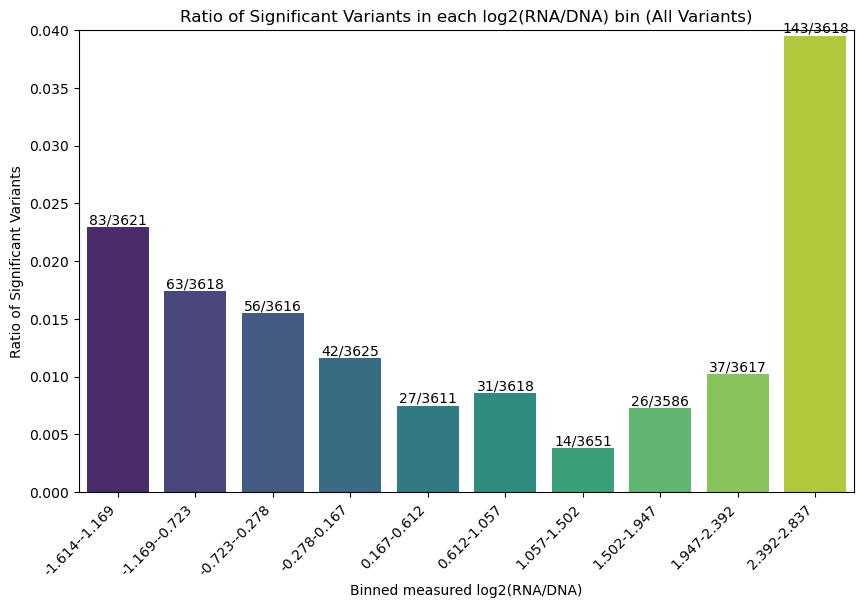

In [ ]:
plot_binned_columns_significants_ratios(merged_bcMPRAlm_snakeflow_info, 'neuro_specific_DNase_median', 'Binned predicted DNase (median of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction) (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios(merged_bcMPRAlm_snakeflow_info, 'sequence_DNase_max', 'Binned predicted DNase of Reference for each Variant from Enformer', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase track bin (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios(merged_bcMPRAlm_snakeflow_info, 'neuro_specific_DNase_max', 'Binned predicted DNase of Reference for each Variant from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction) (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios(merged_bcMPRAlm_snakeflow_info, 'variant_specific_DNase_max', 'Binned predicted variant effect on DNase from Enformer (max over 674 DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted Variant effect DNase bin (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios(merged_bcMPRAlm_snakeflow_info, 'neuro_specific_variant_DNase_max', 'Binned predicted variant effect on neuro specific DNase from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted Variant effect predicted DNase bin (Cell-type specific prediction) (All Variants)', storing=True, name_addition='_all_results_')
plot_binned_columns_significants_ratios(merged_bcMPRAlm_snakeflow_info, 'REF_mean_log2', 'Binned measured log2(RNA/DNA)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each log2(RNA/DNA) bin (All Variants)', storing=True, name_addition='_all_results_')

##### Modiefied version: adding positive and negative counts to the plot

In [ ]:
def plot_binned_columns_significants_ratios_modified(merged_bcMPRAlm_snakeflow_info, column_name, x_label, y_label, plot_title, storing=False, name_addition=''):
    # Calculate the range of column_name
    min_value_seq = merged_bcMPRAlm_snakeflow_info[column_name].min()
    max_value_seq = merged_bcMPRAlm_snakeflow_info[column_name].max()

    # significant
    # significant_bcMPRAlm_snakeflow = merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['adj.P'] < 0.05]

    # Define the number of bins
    num_bins_seq = 10

    # Prepare bin edges
    bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

    # Group by the bins and count the number of positive and negative values in variant_log2FC column
    # log2FC_counts = merged_bcMPRAlm_snakeflow_info.groupby(pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins, precision=3))['variant_log2FC'].apply(lambda x: pd.Series([(x > 0).sum(), (x < 0).sum()], index=['positive_count', 'negative_count'])).unstack(fill_value=0)
    # print(log2FC_counts)
    # # Prepare bin labels using log2FC_counts
    # bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}\n(pos: {pos}, neg: {neg})' for i, (pos, neg) in zip(log2FC_counts['positive_count'], log2FC_counts['negative_count'])]


    # old
    # # Prepare bin labels
    # bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

    # Create bins for column_name with specified labels
    merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
    print(merged_bcMPRAlm_snakeflow_info)
    # # Group by the bins and count the number of significant and non-significant variants
    # bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)

    # # Calculate the ratio of significant variants in each bin
    # bin_group_seq['ratio_significant'] = bin_group_seq['yes'] / (bin_group_seq['yes'] + bin_group_seq['no'])

    # # Reset index to make column_name + '_bin' a regular column
    # bin_group_seq.reset_index(inplace=True)

    # # Create the bar plot
    # plt.figure(figsize=(10, 6))
    # ax = sns.barplot(data=bin_group_seq, x=column_name + '_bin', y='ratio_significant', palette='viridis')

    # # Add labels and title
    # plt.xlabel(x_label)
    # plt.ylabel(y_label)
    # plt.title(plot_title)

    # # x limit
    # plt.ylim(0,0.044)

    # # Rotate x-axis labels by 45 degrees
    # ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    # # Annotate the number of observations in each group
    # for index, row in bin_group_seq.iterrows():
    #     ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

    # if storing:
    #     # plt.savefig(os.path.join(plot_directory, f'significant_ratio_per_binned_dnase_{column_name}{name_addition}.png'), dpi=300, bbox_inches='tight')

    # # Show the plot
    # plt.show()


In [ ]:
plot_binned_columns_significants_ratios_modified(merged_bcMPRAlm_snakeflow_info, 'REF_mean_log2', 'Binned measured log2(RNA/DNA)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each log2(RNA/DNA) bin (All Variants)', storing=True, name_addition='_all_results_')

       variant_log2FC   AveExpr          t       P.Value     adj.P.Val  \
0            1.482729  1.893987  19.158362  2.947206e-66  1.081448e-61   
1            1.521560  0.992996  13.599182  1.398939e-35  2.566633e-31   
2            1.489524  0.944281  13.279882  6.660143e-34  8.146243e-30   
3            0.870725  0.957196  12.290067  3.299979e-32  3.027235e-28   
4            1.027577  1.135585  12.214664  6.337828e-31  4.651206e-27   
...               ...       ...        ...           ...           ...   
36176       -0.000170 -0.383716  -0.002306  9.981607e-01  9.993533e-01   
36177        0.001108  0.266076   0.016283  9.870124e-01  9.966272e-01   
36178        0.000085  0.148052   0.001246  9.990063e-01  9.995732e-01   
36179        0.000085  0.148052   0.001246  9.990063e-01  9.995732e-01   
36180       -0.000690 -0.413355  -0.009081  9.927565e-01  9.985144e-01   

                B                                         variant_id  \
0      138.643345  cardiac_neuro_cava_r

##### Neuro specific results

In [ ]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

In [ ]:
merged_bcMPRAlm_snakeflow_info['gene_set_list']

0          [neuro]
1          [neuro]
2         [random]
3           [cava]
4           [cava]
           ...    
36176    [cardiac]
36177      [neuro]
36178    [cardiac]
36179    [cardiac]
36180      [neuro]
Name: gene_set_list, Length: 36181, dtype: object

In [ ]:
only_neuro_merged_bcMPRAlm_snakeflow_info = merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['gene_set_list'].apply(lambda x: hf.is_element_of(x, 'neuro'))]

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

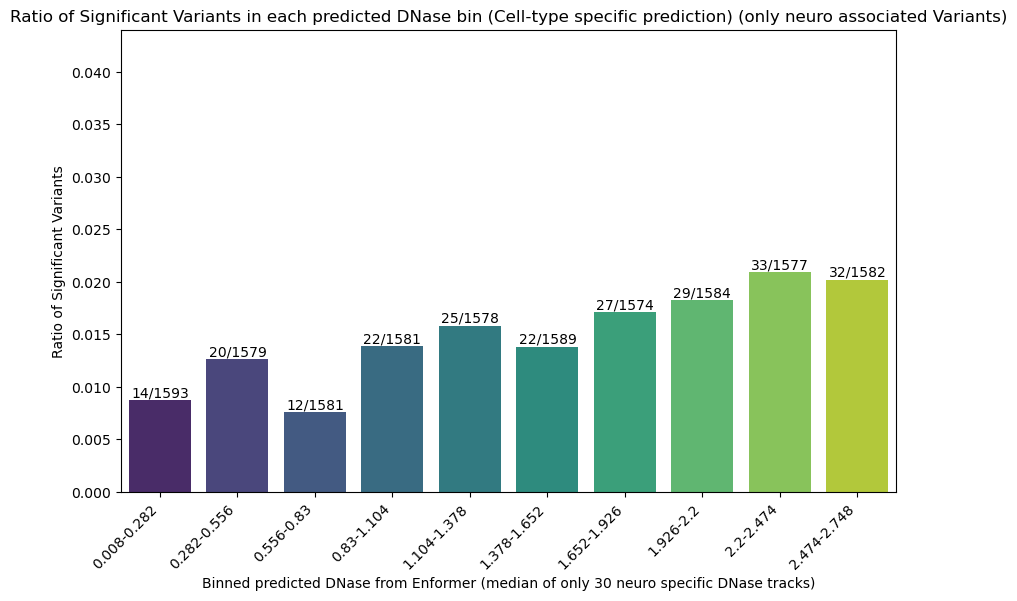

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

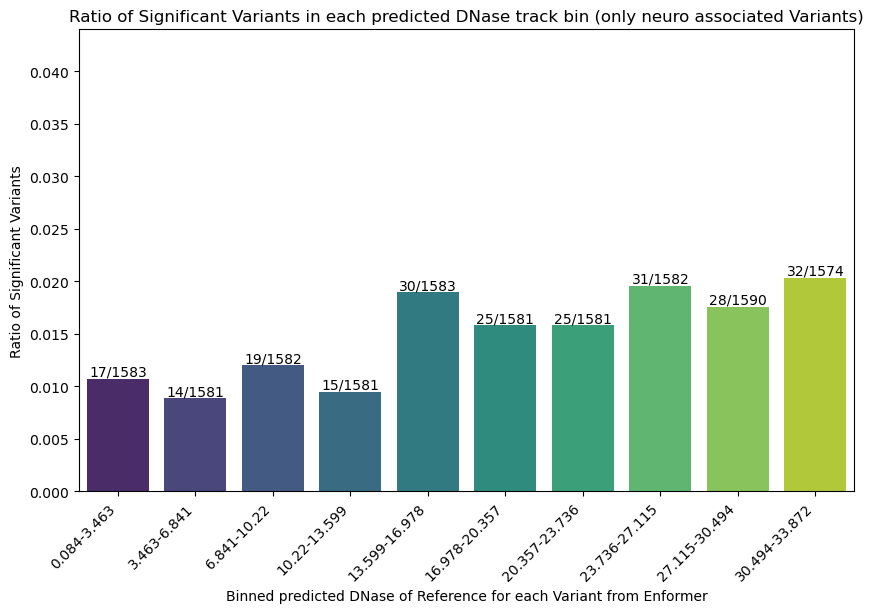

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

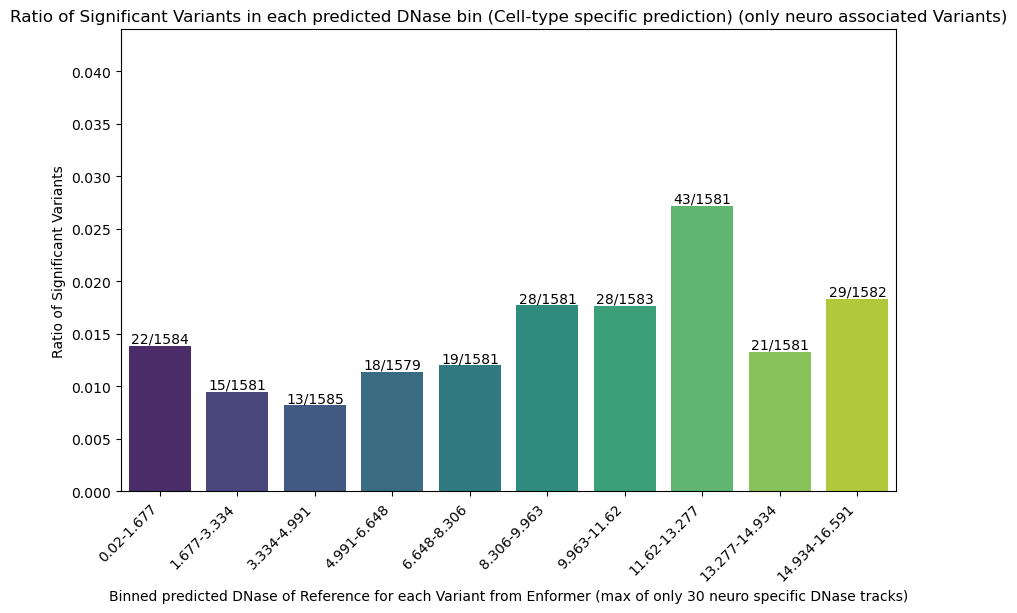

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

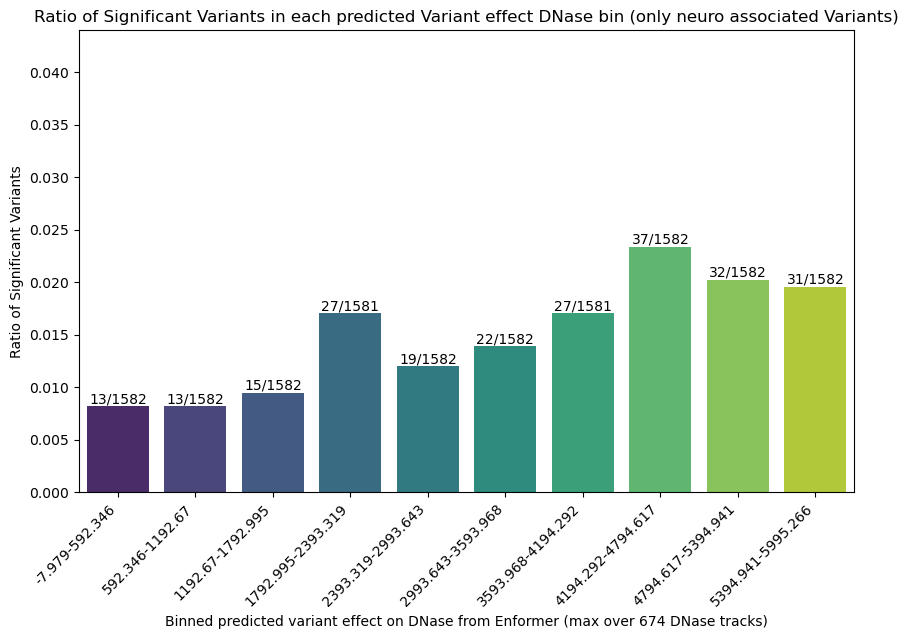

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

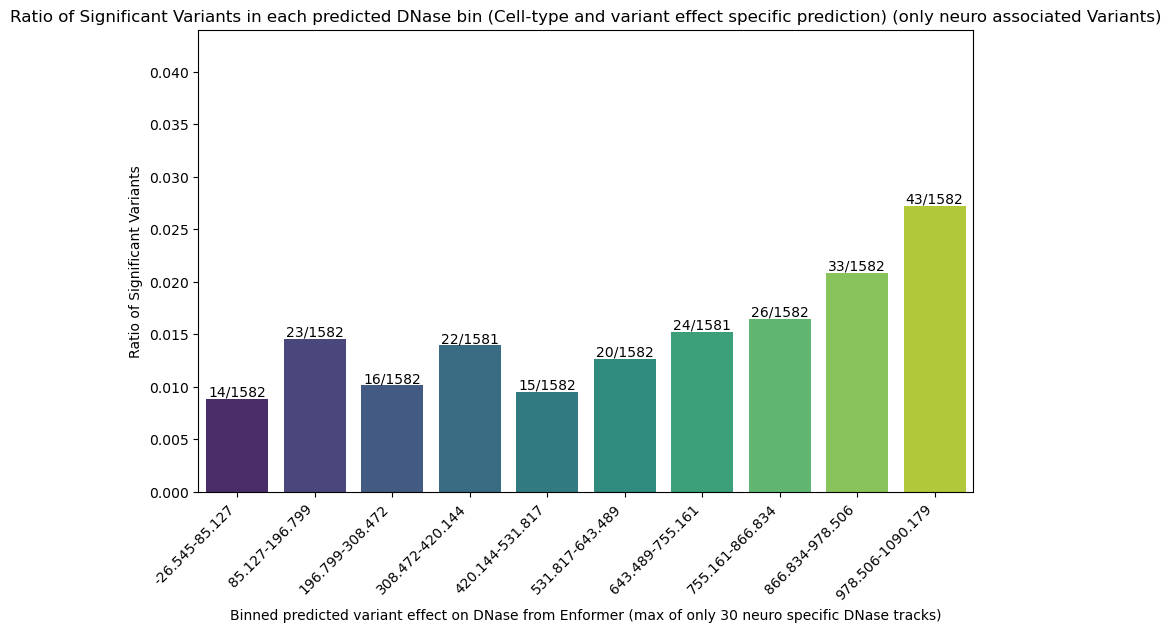

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

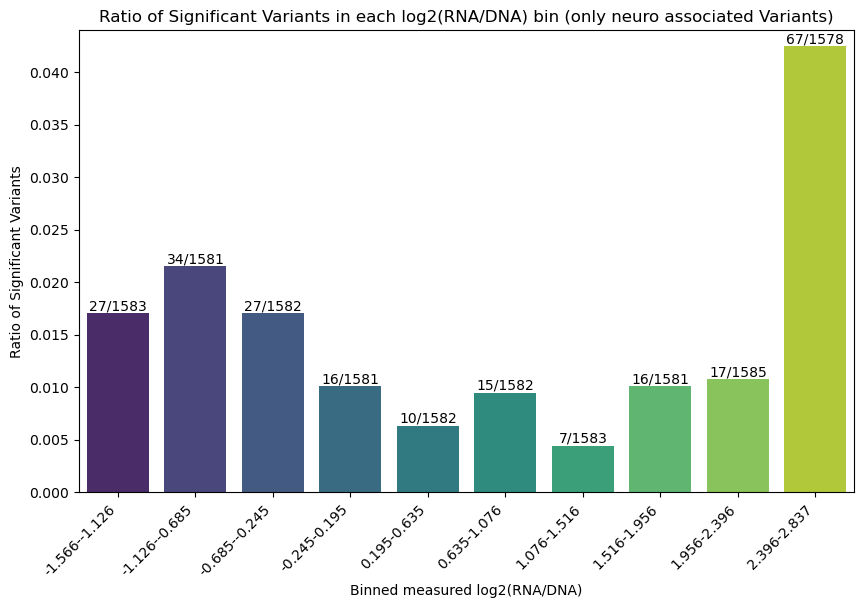

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

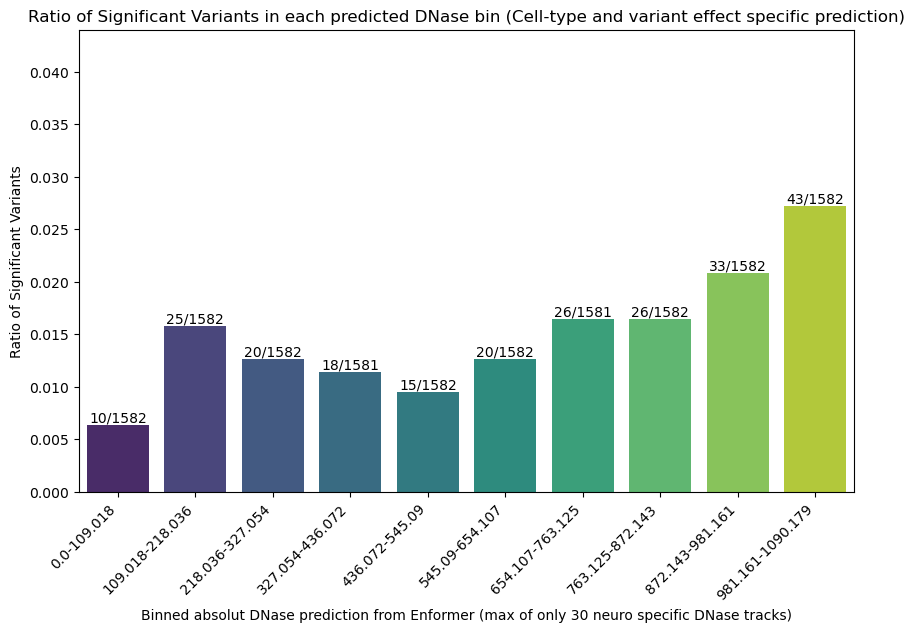

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

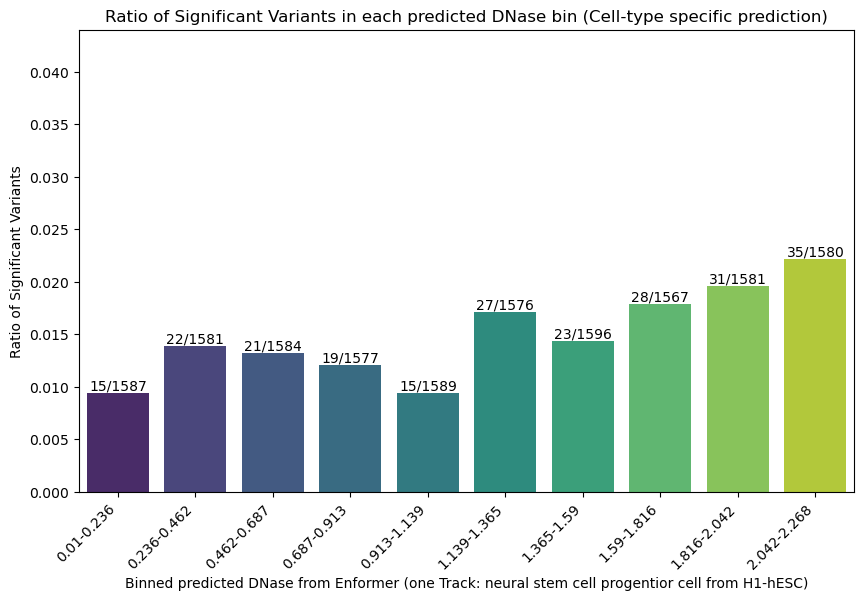

/tmp/ipykernel_113873/2626433438.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_bcMPRAlm_snakeflow_info[column_name + '_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info[column_name], q=num_bins_seq, labels=bin_labels_seq)
/tmp/ipykernel_113873/2626433438.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby([column_name + '_bin', 'is_significant']).size().unstack(fill_value=0)
/tmp/ipykernel_113873/2626433438.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wi

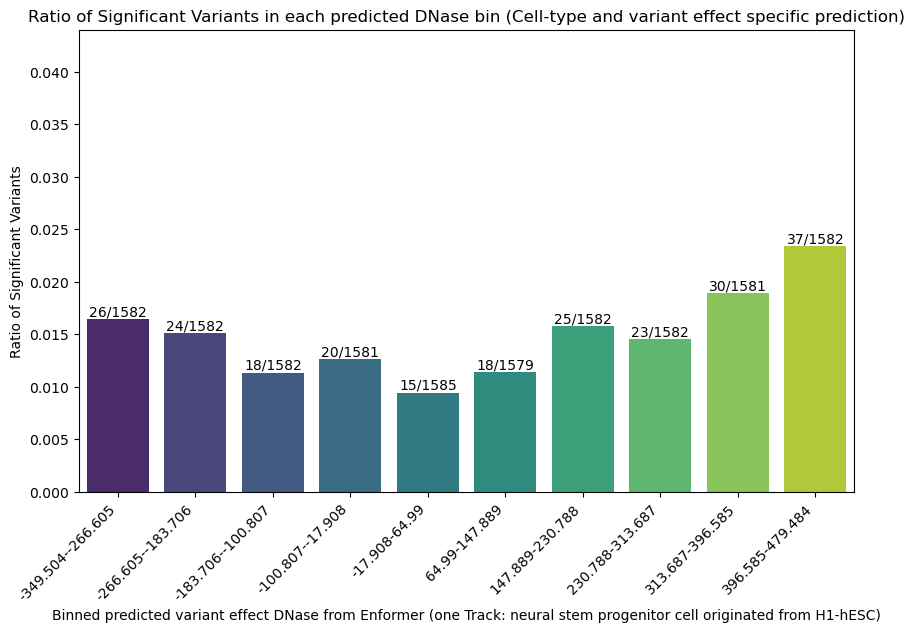

In [ ]:
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'neuro_specific_DNase_median', 'Binned predicted DNase from Enformer (median of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction) (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'sequence_DNase_max', 'Binned predicted DNase of Reference for each Variant from Enformer', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase track bin (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'neuro_specific_DNase_max', 'Binned predicted DNase of Reference for each Variant from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction) (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'variant_specific_DNase_max', 'Binned predicted variant effect on DNase from Enformer (max over 674 DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted Variant effect DNase bin (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'neuro_specific_variant_DNase_max', 'Binned predicted variant effect on DNase from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type and variant effect specific prediction) (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'REF_mean_log2', 'Binned measured log2(RNA/DNA)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each log2(RNA/DNA) bin (only neuro associated Variants)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'neuro_specific_variant_abs_DNase_max', 'Binned absolut DNase prediction from Enformer (max of only 30 neuro specific DNase tracks)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type and variant effect specific prediction)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'Binned predicted DNase from Enformer (one Track: neural stem cell progentior cell from H1-hESC)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction)', storing=True, name_addition='_only_neuro_')
plot_binned_columns_significants_ratios(only_neuro_merged_bcMPRAlm_snakeflow_info, 'variant_DNASE:neural stem progenitor cell originated from H1-hESC', 'Binned predicted variant effect DNase from Enformer (one Track: neural stem progenitor cell originated from H1-hESC)', 'Ratio of Significant Variants', 'Ratio of Significant Variants in each predicted DNase bin (Cell-type and variant effect specific prediction)', storing=True, name_addition='_only_neuro_')

In [ ]:
# # Calculate the range of sequence_DNase_max
# min_value_seq = merged_bcMPRAlm_snakeflow_info['sequence_DNase_max'].min()
# max_value_seq = merged_bcMPRAlm_snakeflow_info['sequence_DNase_max'].max()

# # Define the number of bins
# num_bins_seq = 10

# # Prepare bin edges
# bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

# # Prepare bin labels
# bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

# # Create bins for sequence_DNase_max with specified labels
# merged_bcMPRAlm_snakeflow_info['sequence_DNase_max_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info['sequence_DNase_max'], q=num_bins_seq, labels=bin_labels_seq)

# # Group by the bins and count the number of significant and non-significant variants
# bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby(['sequence_DNase_max_bin', 'is_significant']).size().unstack(fill_value=0)

# # Calculate the ratio of significant variants in each bin
# bin_group_seq['ratio_significant'] = bin_group_seq['yes'] / (bin_group_seq['yes'] + bin_group_seq['no'])

# # Reset index to make 'sequence_DNase_max_bin' a regular column
# bin_group_seq.reset_index(inplace=True)

# # Create the bar plot
# plt.figure(figsize=(10, 6))
# ax = sns.barplot(data=bin_group_seq, x='sequence_DNase_max_bin', y='ratio_significant', palette='viridis')

# # Add labels and title
# plt.xlabel('Binned predicted DNase')
# plt.ylabel('Ratio of Significant Variants')
# plt.title('Ratio of Significant Variants in each predicted DNase bin')

# # Rotate x-axis labels by 45 degrees
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # Annotate the number of observations in each group
# for index, row in bin_group_seq.iterrows():
#     ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')



# # Show the plot
# plt.show()


Neuro specific

In [ ]:
# # Calculate the range of neuro_specific_DNase_median
# min_value_seq = merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median'].min()
# max_value_seq = merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median'].max()

# # Define the number of bins
# num_bins_seq = 10

# # Prepare bin edges
# bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

# # Prepare bin labels
# bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

# # Create bins for neuro_specific_DNase_median with specified labels
# merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median'], q=num_bins_seq, labels=bin_labels_seq)

# # Group by the bins and count the number of significant and non-significant variants
# bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby(['neuro_specific_DNase_median_bin', 'is_significant']).size().unstack(fill_value=0)

# # Calculate the ratio of significant variants in each bin
# bin_group_seq['ratio_significant'] = bin_group_seq['yes'] / (bin_group_seq['yes'] + bin_group_seq['no'])

# # Reset index to make 'neuro_specific_DNase_median_bin' a regular column
# bin_group_seq.reset_index(inplace=True)

# # Create the bar plot
# plt.figure(figsize=(10, 6))
# ax = sns.barplot(data=bin_group_seq, x='neuro_specific_DNase_median_bin', y='ratio_significant', palette='viridis')

# # Add labels and title
# plt.xlabel('Binned predicted DNase (median of only 30 neuro specific DNase tracks)')
# plt.ylabel('Ratio of Significant Variants')
# plt.title('Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction)')

# # Rotate x-axis labels by 45 degrees
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # Annotate the number of observations in each group
# for index, row in bin_group_seq.iterrows():
#     ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

# # Show the plot
# plt.show()


#### For neuro specific DNase max (best performing for enrichment)

In [ ]:
# # Calculate the range of neuro_specific_DNase_max
# min_value_seq = merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_max'].min()
# max_value_seq = merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_max'].max()

# # Define the number of bins
# num_bins_seq = 10

# # Prepare bin edges
# bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

# # Prepare bin labels
# bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

# # Create bins for neuro_specific_DNase_max with specified labels
# merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_max_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_max'], q=num_bins_seq, labels=bin_labels_seq)

# # Group by the bins and count the number of significant and non-significant variants
# bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby(['neuro_specific_DNase_max_bin', 'is_significant']).size().unstack(fill_value=0)

# # Calculate the ratio of significant variants in each bin
# bin_group_seq['ratio_significant'] = bin_group_seq['yes'] / (bin_group_seq['yes'] + bin_group_seq['no'])

# # Reset index to make 'neuro_specific_DNase_max_bin' a regular column
# bin_group_seq.reset_index(inplace=True)

# # Create the bar plot
# plt.figure(figsize=(10, 6))
# ax = sns.barplot(data=bin_group_seq, x='neuro_specific_DNase_max_bin', y='ratio_significant', palette='viridis')

# # Add labels and title
# plt.xlabel('Binned predicted DNase (max of only 30 neuro specific DNase tracks)')
# plt.ylabel('Ratio of Significant Variants')
# plt.title('Ratio of Significant Variants in each predicted DNase bin (Cell-type specific prediction)')

# # Rotate x-axis labels by 45 degrees
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # Annotate the number of observations in each group
# for index, row in bin_group_seq.iterrows():
#     ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

# # Show the plot
# plt.show()


##### Investigate the correlation of DNase (predicted) and Ref log2FC (not done yet)

In [ ]:
# # Calculate the range of neuro_specific_DNase_median
# min_value_seq = merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median'].min()
# max_value_seq = merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median'].max()

# # Define the number of bins
# num_bins_seq = 10

# # Prepare bin edges
# bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

# # Prepare bin labels
# bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

# # Create bins for neuro_specific_DNase_median with specified labels
# merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median_bin'] = pd.qcut(merged_bcMPRAlm_snakeflow_info['neuro_specific_DNase_median'], q=num_bins_seq, labels=bin_labels_seq)

# # # Group by the bins and count the number of significant and non-significant variants
# # bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby(['neuro_specific_DNase_median_bin', 'is_significant']).size().unstack(fill_value=0)

# # # Calculate the ratio of significant variants in each bin
# # bin_group_seq['ratio_significant'] = bin_group_seq['yes'] / (bin_group_seq['yes'] + bin_group_seq['no'])

# # Reset index to make 'neuro_specific_DNase_median_bin' a regular column
# bin_group_seq.reset_index(inplace=True)

# # Create the bar plot
# plt.figure(figsize=(10, 6))
# ax = sns.scatterplot(data=merged_bcMPRAlm_snakeflow_info, x='REF_mean_log2', y='neuro_specific_DNase_median_bin', palette='viridis')

# # Add labels and title
# plt.xlabel('Binned predicted DNase (median of only 30 neuro specific DNase tracks) ')
# plt.ylabel('Log2(RNA/DNA) of Reference sequence')
# plt.title('Correlation between cell-type specific DNase prediction and log2(RNA/DNA)')

# # Rotate x-axis labels by 45 degrees
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # # Annotate the number of observations in each group
# # for index, row in bin_group_seq.iterrows():
# #     ax.text(index, row['ratio_significant'], f"{row['yes']}/{row['yes'] + row['no']}", color='black', ha='center', va='bottom')

# # Show the plot
# plt.show()


In [ ]:
# import pandas as pd
# import numpy as np
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Calculate the range of neuro_specific_DNase_median
# min_value_seq = merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].min()
# max_value_seq = merged_bcMPRAlm_snakeflow_info['REF_mean_log2'].max()

# # Define the number of bins
# num_bins_seq = 10

# # Prepare bin edges
# bin_edges_seq = np.linspace(min_value_seq, max_value_seq, num_bins_seq + 1)

# # Prepare bin labels
# bin_labels_seq = [f'{round(bin_edges_seq[i], 3)}-{round(bin_edges_seq[i+1], 3)}' for i in range(len(bin_edges_seq) - 1)]

# # Create bins for REF_mean_log2 with specified labels
# merged_bcMPRAlm_snakeflow_info['REF_mean_log2_bin'] = pd.qcut(
#     merged_bcMPRAlm_snakeflow_info['REF_mean_log2'], q=num_bins_seq, labels=bin_labels_seq
# )

# # Group by the bins and calculate the median values
# bin_group_seq = merged_bcMPRAlm_snakeflow_info.groupby('REF_mean_log2_bin').agg({
#     'REF_mean_log2': 'median',
#     'neuro_specific_DNase_median': 'median'
# }).reset_index()

# # Create the scatter plot
# plt.figure(figsize=(10, 6))
# ax = sns.scatterplot(data=bin_group_seq, x='neuro_specific_DNase_median', y='REF_mean_log2', palette='viridis')

# # Add labels and title
# plt.ylabel('Binned predicted DNase (median of only 30 neuro specific DNase tracks)')
# plt.xlabel('Log2(RNA/DNA) of Reference sequence')
# plt.title('Correlation between cell-type specific DNase prediction and log2(RNA/DNA)')

# # Rotate x-axis labels by 45 degrees
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# # Show the plot
# plt.show()


In [ ]:
# Old code from bin analysis
# # sort by logFC
# logFC_sorted = merged_bcMPRAlm_snakeflow_info[['variant_log2FC', 'variant_id', 'enformer_class', 'variant_type', 'gene_set', 'DNase_max']].sort_values(by='logFC', ascending=True)
# matched_significant_results['abs_logFC'] = matched_significant_results['logFC'].abs()
# # sort by logFC (absolut value)
# abs_logFC_sorted = matched_significant_results[['logFC', 'variant_id', 'enformer_class', 'variant_type', 'gene_set', 'DNase_max', 'abs_logFC']].sort_values(by='abs_logFC', ascending=True)
# abs_bins = [abs_logFC_sorted.iloc[i*abs_logFC_sorted.shape[0]//10:(i+1)*abs_logFC_sorted.shape[0]//10] for i in range(10)]

# # make equally distant bins of the logFC and plot  number of enformer_high occurences per bin as histogram
# bins = [logFC_sorted.iloc[i*logFC_sorted.shape[0]//10:(i+1)*logFC_sorted.shape[0]//10] for i in range(10)]
# # # barplot of numbers of enformer_high occurnces in enformer_class column per bin
# # [bins[i].describe for i in range(10)]
# # # 495 -0.270634  cardiac_neuro_cava_random:BCL10|ENSG0000014286...
# # #  569  0.268013  cardiac_neuro_cava_random:PHACTR1|ENSG00000112...
# # # This means significant logFC is from -0.27 and from 0.27


KeyError: "['enformer_class', 'variant_type', 'gene_set'] not in index"

#### Investigate variant type distribution of neuro specific variant list

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def is_element_of(column_list, pattern):
    """Check for the pattern in the column_list"""
    return pattern in column_list


def plot_variant_type_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton']):
    """Plot the variant type proportion of significant variants"""

    if gene_set != None:
        matched_df = matched_df.loc[matched_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set))]

    if gene_set == None:
        gene_set = 'All'

    # get the significant df
    significant_variants_df = matched_df.loc[matched_df['adj.P.Val'] < 0.05]

    # Calculate the counts for all variants
    total_variant_counts = matched_df['variant_type'].value_counts()

    # Calculate the counts for significant variants
    significant_variant_counts = significant_variants_df['variant_type'].value_counts()
    significant_variant_counts
    # Calculate the ratios
    ratios = {key: significant_variant_counts[key] / total_variant_counts[key] for key in total_variant_counts.index}

    # Create a DataFrame for plotting
    df_plot = pd.DataFrame(list(ratios.items()), columns=['Variant Type', 'Proportion'])

    # Add total counts and significant counts to the DataFrame for annotation
    df_plot['Total Variants'] = df_plot['Variant Type'].map(total_variant_counts)
    df_plot['Significant Variants'] = df_plot['Variant Type'].map(significant_variant_counts)
    print(df_plot)
    # Sort the DataFrame by the 'Proportion' column if the order is not given
    if x_axis_order == None:
        df_plot = df_plot.sort_values(by='Proportion')

    # Define a custom color palette
    palette = {
        'common': '#db2486',
        'rare': '#db2486',
        'ultra-rare': '#70acc0',
        'singleton': '#70acc0'
    }
    # # Define a custom color palette
    # palette = {
    #     'common': '#1f77b4',
    #     'rare': '#1f77b4',
    #     'singleton': '#ff7f0e',
    #     'ultra-rare': '#2ca02c'
    # }

    # Plot
    plt.figure(figsize=(8, 6))  # Adjust figure size for better fit
    ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
    plt.title(f'Proportion of Significant Variants by Type ({gene_set})')
    plt.ylabel('Proportion of Variants')
    plt.xlabel('Variant Type')
    plt.ylim(0, max(df_plot['Proportion']) * 1.1)  # Slightly higher than the max ratio for better visualization

    # Adjust the bar width
    for patch in ax.patches:
        current_width = patch.get_width()
        diff = current_width - 0.2  # Here 0.2 is the desired width
        patch.set_width(0.2)
        patch.set_x(patch.get_x() + diff * .5)

    # Annotate bars with the "number_significant/total_number"
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()
        # consider x_axis_order
        variant_type = x_axis_order[i]
        # get index
        variant_type_idx_list = df_plot.loc[df_plot['Variant Type'] == variant_type].index.values
        variant_type_idx = variant_type_idx_list[0]
        ax.text(
            patch.get_x() + patch.get_width() / 2,  # x coordinate
            height,  # y coordinate
            # f'{df_plot["Significant Variants"].iloc[i]}/{df_plot["Total Variants"].iloc[i]}',  # annotation text
            f'{df_plot.iloc[variant_type_idx]["Significant Variants"]}/{df_plot.iloc[variant_type_idx]["Total Variants"]}',  # annotation text
            ha='center',  # horizontal alignment
            va='bottom'  # vertical alignment
        )

    plt.show()

In [ ]:
merged_bcMPRAlm_snakeflow_info['variant_type'].value_counts()

variant_type
singleton     9684
ultra-rare    9572
common        9377
rare          7548
Name: count, dtype: int64

In [ ]:
x_axis_order

make variant_type_list to an element wise column

In [ ]:
def get_element_from_list(element_list):
    if isinstance(element_list,list):
        if len(element_list) == 1:
            return element_list[0]
        else:
            print(f'Not only one element in {element_list}')
    return element_list

In [ ]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

  Variant Type  Proportion  Total Variants  Significant Variants
0    singleton    0.016729            9684                   162
1   ultra-rare    0.015984            9572                   153
2       common    0.011624            9377                   109
3         rare    0.012984            7548                    98


/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


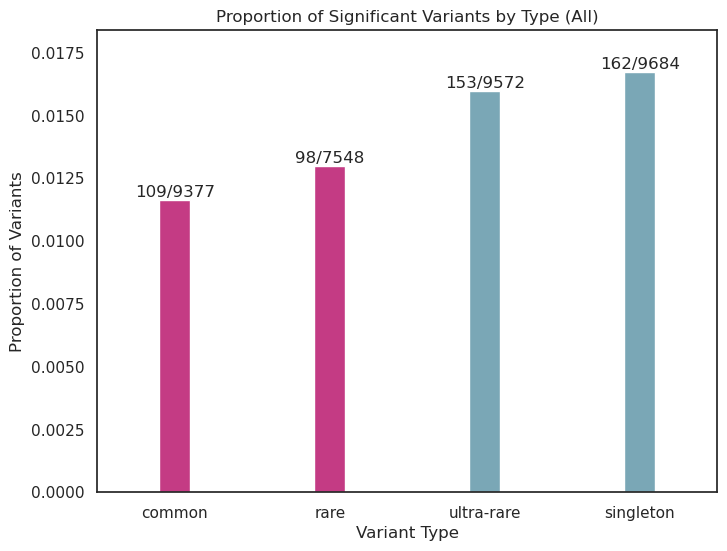

  Variant Type  Proportion  Total Variants  Significant Variants
0       common    0.011833            5493                    65
1         rare    0.014988            4537                    68
2    singleton    0.016123            2915                    47
3   ultra-rare    0.019492            2873                    56


/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


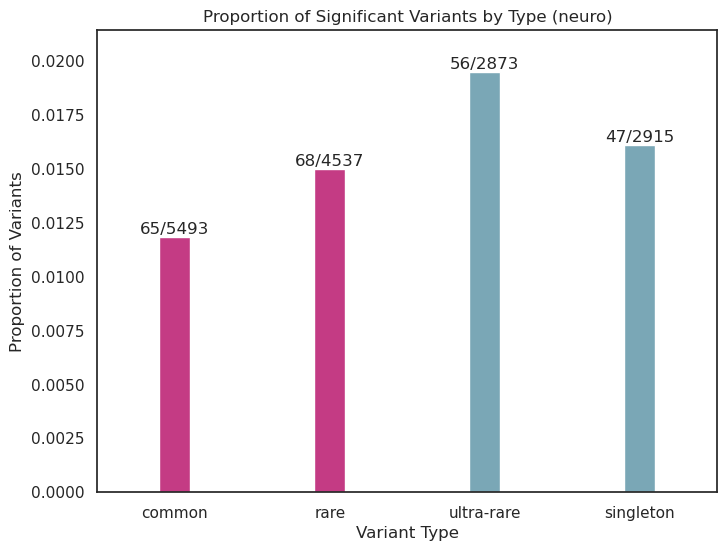

  Variant Type  Proportion  Total Variants  Significant Variants
0       common    0.010934            3201                    35
1    singleton    0.016112            2793                    45
2   ultra-rare    0.013338            2774                    37
3         rare    0.009016            2551                    23


/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


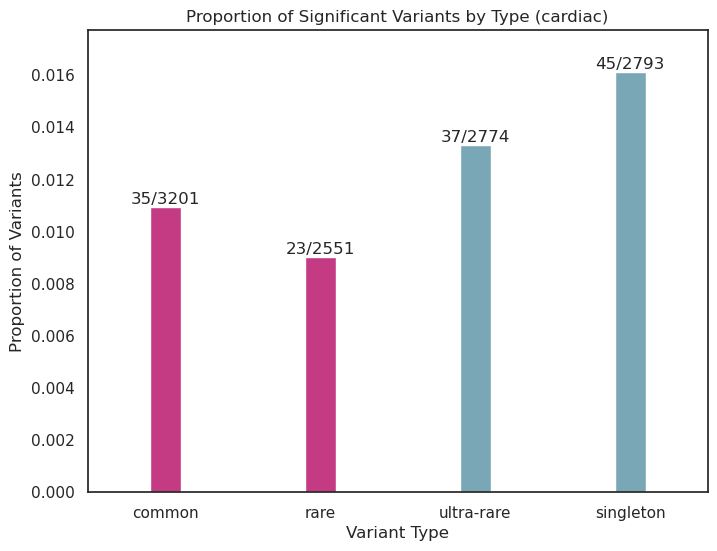

  Variant Type  Proportion  Total Variants  Significant Variants
0    singleton    0.018195            2693                    49
1   ultra-rare    0.015483            2648                    41
2       common    0.012640             712                     9
3         rare    0.013725             510                     7


/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


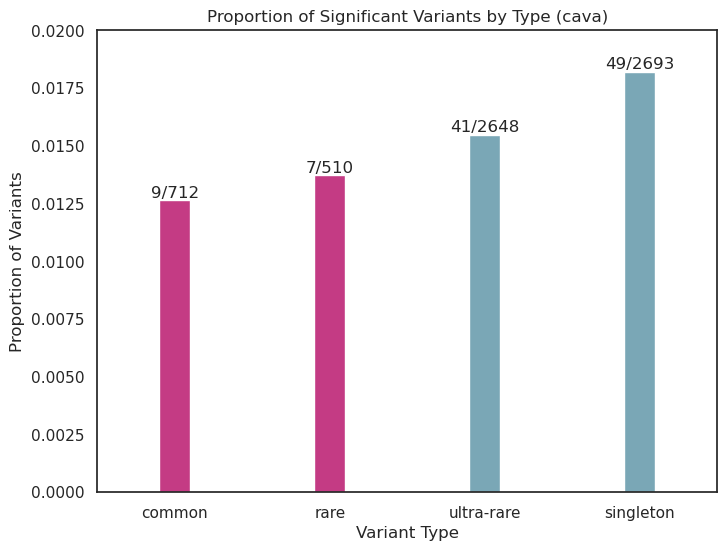

  Variant Type  Proportion  Total Variants  Significant Variants
0    singleton    0.016271            1475                    24
1   ultra-rare    0.014443            1454                    21
2       common    0.013652             293                     4
3         rare    0.016598             241                     4


/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_113873/1156413866.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variant Type', y='Proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


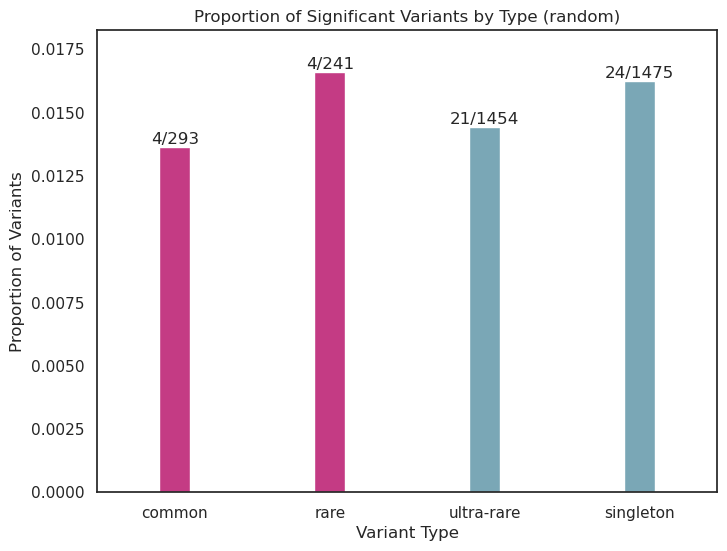

In [ ]:
# merged_bcMPRAlm_snakeflow_info.head()
# print(merged_bcMPRAlm_snakeflow_info['variant_type_list'].value_counts())
# merged_bcMPRAlm_snakeflow_info['variant_type'] = merged_bcMPRAlm_snakeflow_info['variant_type_list'].apply(get_element_from_list)
plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info)
plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, 'neuro')
plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, 'cardiac')
plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, 'cava')
plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, 'random')
# # exploding variant info required?
# # # Explode the list of tuples into separate rows
# merged_bcMPRAlm_exploded = merged_bcMPRAlm_snakeflow_info.explode('enformer_variant_info')

# # # Split the tuples into separate columns
# merged_bcMPRAlm_exploded[['gene_set', 'variant_type', 'enformer_class']] = pd.DataFrame(merged_bcMPRAlm_exploded['enformer_variant_info'].tolist(), index=merged_bcMPRAlm_exploded.index)

# print(merged_bcMPRAlm_exploded['variant_type'].value_counts())


##### Investigate the ratio of effect direction within the significants

##### Investigate positive vs negative effects

In [ ]:
def get_effect_direction(variant_log2):
    if variant_log2 > 0:
        return 'pos'
    elif variant_log2 < 0:
        return 'neg'
    return np.nan

In [ ]:
merged_bcMPRAlm_snakeflow_info['effect_direction'] = merged_bcMPRAlm_snakeflow_info['variant_log2FC'].apply(get_effect_direction)
merged_bcMPRAlm_snakeflow_info['effect_direction'].value_counts()

effect_direction
neg    18505
pos    17676
Name: count, dtype: int64

#### Effect direction within significants ratio plot

In [ ]:
value_counts_example = merged_bcMPRAlm_snakeflow_info['variant_type'].value_counts().reset_index()
value_counts_example

,variant_type,count
0,singleton,9684
1,ultra-rare,9572
2,common,9377
3,rare,7548


In [ ]:
effect_example.div(effect_example.sum(axis=1), axis=0)


effect_direction,neg,pos
variant_type,,
common,0.507198,0.492802
rare,0.514838,0.485162
singleton,0.520446,0.479554
ultra-rare,0.503865,0.496135


In [ ]:
effect_example = merged_bcMPRAlm_snakeflow_info.groupby(['variant_type', 'effect_direction']).size().unstack(fill_value=0)
effect_proportion_example = effect_example.div(effect_example.sum(axis=1), axis=0)


,variant_type,count,neg,pos
0,singleton,9684,0.520446,0.479554
1,ultra-rare,9572,0.503865,0.496135
2,common,9377,0.507198,0.492802
3,rare,7548,0.514838,0.485162


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def is_element_of(column_list, pattern):
    """Check for the pattern in the column_list"""
    return pattern in column_list


def plot_variant_type_effect_direction_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton']):
    """Plot the variant type proportion of significant variants"""

    if gene_set != None:
        matched_df = matched_df.loc[matched_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set))]

    if gene_set == None:
        gene_set = 'All'

    # get the significant df
    significant_variants_df = matched_df.loc[matched_df['adj.P.Val'] < 0.05]

    # Calculate the counts for all variants
    total_variant_counts = matched_df['variant_type'].value_counts()

    # Calculate the counts for significant variants
    significant_variant_counts = significant_variants_df['variant_type'].value_counts()
    significant_variant_counts

    # Group by variant_type and effect_direction and count the occurrences
    effect_counts = significant_variants_df.groupby(['variant_type', 'effect_direction']).size().unstack(fill_value=0)
    # print(effect_counts)
    # Calculate the proportions of positive and negative effects within each variant type
    effect_proportions = effect_counts.div(effect_counts.sum(axis=1), axis=0)
    # print(effect_proportions)
    # Add total counts and significant counts to the DataFrame for annotation
    total_variant_counts = matched_df['variant_type'].value_counts()
    # print(effect_proportions)
    # # Plot
    # plt.figure(figsize=(10, 6))  # Adjust figure size for better fit
    # effect_proportions[['pos', 'neg']].plot(kind='bar', stacked=True, color=colors)
    # colors = ['#db2486', '#70acc0']  # Colors for 'pos' and 'neg'


    # Calculate the ratios
    ratios = {key: significant_variant_counts[key] / total_variant_counts[key] for key in total_variant_counts.index}

    # Create a DataFrame for plotting
    df_plot = pd.DataFrame(list(ratios.items()), columns=['variant_type', 'sig_proportion'])

    # Add total counts and significant counts to the DataFrame for annotation
    df_plot['Total Variants'] = df_plot['variant_type'].map(total_variant_counts)
    df_plot['Significant Variants'] = df_plot['variant_type'].map(significant_variant_counts)
    df_plot_proportions = df_plot.merge(effect_proportions, on='variant_type', how='left')
    print(df_plot_proportions)
    # Sort the DataFrame by the 'sig_proportion' column if the order is not given
    if x_axis_order == None:
        df_plot = df_plot.sort_values(by='sig_proportion')

    # Define a custom color palette
    palette = {
        'common': '#db2486',
        'rare': '#db2486',
        'ultra-rare': '#70acc0',
        'singleton': '#70acc0'
    }

    # Plot
    plt.figure(figsize=(8, 6))  # Adjust figure size for better fit
    ax = sns.barplot(x='variant_type', y='sig_proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
    plt.title(f'Proportion of Significant Variants by Type ({gene_set})')
    plt.ylabel('Proportion of Variants')
    plt.xlabel('Variant Type')
    plt.ylim(0, max(df_plot['sig_proportion']) * 1.1)  # Slightly higher than the max ratio for better visualization

    # Adjust the bar width
    for patch in ax.patches:
        current_width = patch.get_width()
        diff = current_width - 0.2  # Here 0.2 is the desired width
        patch.set_width(0.2)
        patch.set_x(patch.get_x() + diff * .5)

    # Annotate bars with the "number_significant/total_number"
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()
        # consider x_axis_order
        variant_type = x_axis_order[i]
        # get index
        variant_type_idx_list = df_plot.loc[df_plot['Variant Type'] == variant_type].index.values
        variant_type_idx = variant_type_idx_list[0]
        ax.text(
            patch.get_x() + patch.get_width() / 2,  # x coordinate
            height,  # y coordinate
            f'{df_plot.iloc[variant_type_idx]["Significant Variants"]}/{df_plot.iloc[variant_type_idx]["Total Variants"]}',  # annotation text
            ha='center',  # horizontal alignment
            va='bottom'  # vertical alignment
        )

    plt.show()

  variant_type  sig_proportion  Total Variants  Significant Variants  \
0    singleton        0.016729            9684                   162   
1   ultra-rare        0.015984            9572                   153   
2       common        0.011624            9377                   109   
3         rare        0.012984            7548                    98   

        neg       pos  
0  0.462963  0.537037  
1  0.450980  0.549020  
2  0.550459  0.449541  
3  0.479592  0.520408  


/tmp/ipykernel_113873/2540741929.py:69: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='variant_type', y='sig_proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)
/tmp/ipykernel_113873/2540741929.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='variant_type', y='sig_proportion', data=df_plot, palette=palette, order=x_axis_order, ci=None)


KeyError: 'Variant Type'

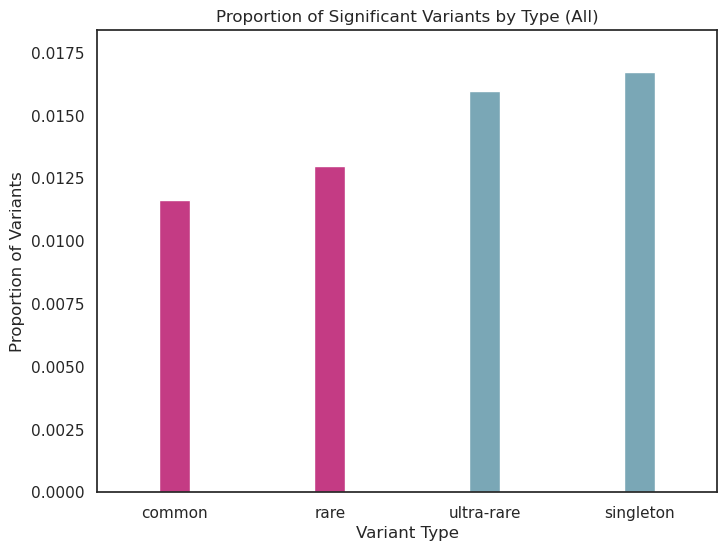

In [ ]:
plot_variant_type_effect_direction_barplot(merged_bcMPRAlm_snakeflow_info)

##### Effect direction over all variants

In [ ]:
merged_bcMPRAlm_snakeflow_info['variant_type'].value_counts()

variant_type
singleton     9684
ultra-rare    9572
common        9377
rare          7548
Name: count, dtype: int64

In [ ]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

In [ ]:
merged_bcMPRAlm_snakeflow_info.loc[merged_bcMPRAlm_snakeflow_info['adj.P.Val'] < 0.05]['variant_type'].value_counts()

variant_type
singleton     162
ultra-rare    153
common        109
rare           98
Name: count, dtype: int64

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# def plot_variant_type_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton']):
#     """Plot the variant type proportion of significant variants"""
#     if gene_set is not None:
#         matched_df = matched_df.loc[matched_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set))]

#     if gene_set is None:
#         gene_set = 'All'

#     # get the significant df
#     significant_variants_df = matched_df.loc[matched_df['adj.P.Val'] < 0.05]

#     # Calculate the counts for all variants
#     total_variant_counts = matched_df['variant_type'].value_counts()

#     # Calculate the counts for significant variants grouped by variant type and effect direction
#     effect_counts = significant_variants_df.groupby(['variant_type', 'effect_direction']).size().unstack(fill_value=0)

#     # Calculate the proportions
#     effect_proportions = effect_counts.div(effect_counts.sum(axis=1), axis=0).reset_index()

#     # Melt the DataFrame for easier plotting with seaborn
#     df_plot = effect_proportions.melt(id_vars='variant_type', value_vars=effect_proportions.columns[1:],
#                                       var_name='Effect Direction', value_name='Proportion')

#     # Add total counts and significant counts to the DataFrame for annotation
#     df_plot['Total Variants'] = df_plot['variant_type'].map(total_variant_counts)
#     df_plot['Significant Variants'] = df_plot.apply(lambda row: significant_variants_df[
#         (significant_variants_df['variant_type'] == row['variant_type']) &
#         (significant_variants_df['effect_direction'] == row['Effect Direction'])].shape[0], axis=1)

#     # Sort the DataFrame by the 'Proportion' column if the order is not given
#     if x_axis_order is None:
#         df_plot = df_plot.sort_values(by='Proportion')

#     # Define a custom color palette with darker colors for 'ultra-rare' and 'singleton'
#     palette = {
#         ('common', 'pos'): '#db2486',
#         ('common', 'neg'): '#e69f00',
#         ('rare', 'pos'): '#db2486',
#         ('rare', 'neg'): '#e69f00',
#         ('ultra-rare', 'pos'): '#507f99',  # darker shade for ultra-rare pos
#         ('ultra-rare', 'neg'): '#305f79',  # darker shade for ultra-rare neg
#         ('singleton', 'pos'): '#507f99',   # darker shade for singleton pos
#         ('singleton', 'neg'): '#305f79'    # darker shade for singleton neg
#     }

#     # Adjust the hue order to match the palette keys
#     hue_order = ['pos', 'neg']

#     # Plot
#     plt.figure(figsize=(10, 6))  # Adjust figure size for better fit
#     ax = sns.barplot(x='variant_type', y='Proportion', hue='Effect Direction', data=df_plot,
#                      hue_order=hue_order, palette=[palette[(vt, ed)] for vt in x_axis_order for ed in hue_order],
#                      order=x_axis_order, ci=None)

#     plt.title(f'Proportion of Significant Variants by Type and Effect Direction ({gene_set})')
#     plt.ylabel('Proportion of Variants')
#     plt.xlabel('Variant Type')
#     plt.ylim(0, 1.0)  # Proportions sum to 1

#     # Annotate bars with the "number_significant/total_number"
#     for i, patch in enumerate(ax.patches):
#         height = patch.get_height()
#         variant_type = df_plot['variant_type'].iloc[i // 2]
#         direction = df_plot['Effect Direction'].iloc[i % 2]
#         total_variants = df_plot[df_plot['variant_type'] == variant_type]['Total Variants'].values[0]
#         significant_variants = df_plot[
#             (df_plot['variant_type'] == variant_type) &
#             (df_plot['Effect Direction'] == direction)
#         ]['Significant Variants'].values[0]
#         ax.text(
#             patch.get_x() + patch.get_width() / 2,
#             height,
#             f'{significant_variants}/{total_variants}',
#             ha='center',
#             va='bottom'
#         )

#     plt.legend(title='Effect Direction')
#     plt.show()

# # Example usage
# # df = ... # Your DataFrame
# # plot_variant_type_barplot(df)

# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info)


In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# def plot_variant_type_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton']):
#     """Plot the variant type proportion of significant variants"""
#     if gene_set is not None:
#         matched_df = matched_df.loc[matched_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set))]

#     if gene_set is None:
#         gene_set = 'All'

#     # get the significant df
#     significant_variants_df = matched_df.loc[matched_df['adj.P.Val'] < 0.05]

#     # Calculate the counts for all variants
#     total_variant_counts = matched_df['variant_type'].value_counts()

#     # Calculate the counts for significant variants grouped by variant type and effect direction
#     effect_counts = significant_variants_df.groupby(['variant_type', 'effect_direction']).size().unstack(fill_value=0)

#     # Calculate the proportions
#     effect_proportions = effect_counts.div(effect_counts.sum(axis=1), axis=0).reset_index()

#     # Melt the DataFrame for easier plotting with seaborn
#     df_plot = effect_proportions.melt(id_vars='variant_type', value_vars=effect_proportions.columns[1:],
#                                       var_name='Effect Direction', value_name='Proportion')

#     # Add total counts and significant counts to the DataFrame for annotation
#     df_plot['Total Variants'] = df_plot['variant_type'].map(total_variant_counts)
#     df_plot['Significant Variants'] = df_plot.apply(lambda row: significant_variants_df[
#         (significant_variants_df['variant_type'] == row['variant_type']) &
#         (significant_variants_df['effect_direction'] == row['Effect Direction'])].shape[0], axis=1)

#     # Sort the DataFrame by the 'Proportion' column if the order is not given
#     if x_axis_order is None:
#         df_plot = df_plot.sort_values(by='Proportion')

#     # Define a custom color palette with darker colors for 'ultra-rare' and 'singleton'
#     palette = {
#         ('common', 'pos'): '#70acc0',
#         ('common', 'neg'): '#db2486',
#         ('rare', 'pos'): '#70acc0',
#         ('rare', 'neg'): '#db2486',
#         ('ultra-rare', 'pos'): '#507f99',  # darker shade for ultra-rare pos
#         ('ultra-rare', 'neg'): '#db2486',  # darker shade for ultra-rare neg
#         ('singleton', 'pos'): '#507f99',   # darker shade for singleton pos
#         ('singleton', 'neg'): '#db2486'    # darker shade for singleton neg
#     }
#     # 70acc0, e69f00

#     # Adjust the hue order to match the palette keys
#     hue_order = ['pos', 'neg']

#     # Plot
#     plt.figure(figsize=(10, 6))  # Adjust figure size for better fit
#     ax = sns.barplot(x='variant_type', y='Proportion', hue='Effect Direction', data=df_plot,
#                      hue_order=hue_order, palette=[palette[(vt, ed)] for vt in x_axis_order for ed in hue_order],
#                      order=x_axis_order, ci=None)

#     plt.title(f'Proportion of Significant Variants by Type and Effect Direction ({gene_set})')
#     plt.ylabel('Proportion of Variants')
#     plt.xlabel('Variant Type')
#     plt.ylim(0, 1.0)  # Proportions sum to 1

#     # Annotate bars with the "number_significant/total_number"
#     for i, patch in enumerate(ax.patches):
#         height = patch.get_height()
#         variant_type = df_plot['variant_type'].iloc[i // 2]
#         direction = df_plot['Effect Direction'].iloc[i % 2]
#         total_variants = df_plot[df_plot['variant_type'] == variant_type]['Total Variants'].values[0]
#         significant_variants = df_plot[
#             (df_plot['variant_type'] == variant_type) &
#             (df_plot['Effect Direction'] == direction)
#         ]['Significant Variants'].values[0]
#         print(significant_variants)
#         ax.text(
#             patch.get_x() + patch.get_width() / 2,
#             height,
#             f'{significant_variants}/{total_variants}',
#             ha='center',
#             va='bottom'
#         )

#     plt.legend(title='Effect Direction')
#     plt.show()

# # Example usage
# # df = ... # Your DataFrame
# # plot_variant_type_barplot(df)

# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info)



working version without different coloring for ultra-rare and singleton

In [ ]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# def plot_variant_type_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton']):
#     """Plot the variant type proportion of significant variants"""
#     if gene_set is not None:
#         matched_df = matched_df.loc[matched_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set))]

#     if gene_set is None:
#         gene_set = 'All'

#     # get the significant df
#     significant_variants_df = matched_df.loc[matched_df['adj.P.Val'] < 0.05]

#     # Calculate the counts for all variants
#     total_variant_counts = matched_df['variant_type'].value_counts()

#     # Calculate the counts for significant variants grouped by variant type and effect direction
#     effect_counts = significant_variants_df.groupby(['variant_type', 'effect_direction']).size().unstack(fill_value=0)

#     # Calculate the proportions
#     effect_proportions = effect_counts.div(effect_counts.sum(axis=1), axis=0).reset_index()

#     # Melt the DataFrame for easier plotting with seaborn
#     df_plot = effect_proportions.melt(id_vars='variant_type', value_vars=effect_proportions.columns[1:],
#                                       var_name='Effect Direction', value_name='Proportion')

#     # Add total counts and significant counts to the DataFrame for annotation
#     df_plot['Total Variants'] = df_plot['variant_type'].map(total_variant_counts)
#     df_plot['Significant Variants'] = df_plot.apply(lambda row: significant_variants_df[
#         (significant_variants_df['variant_type'] == row['variant_type']) &
#         (significant_variants_df['effect_direction'] == row['Effect Direction'])].shape[0], axis=1)

#     # Sort the DataFrame by the 'Proportion' column if the order is not given
#     if x_axis_order is None:
#         df_plot = df_plot.sort_values(by='Proportion')

#     # # Define a custom color palette
#     # palette = {
#     #     ('common', 'pos'): '#db2486',
#     #     ('common', 'neg'): '#e69f00',
#     #     ('rare', 'pos'): '#db2486',
#     #     ('rare', 'neg'): '#e69f00',
#     #     ('ultra-rare', 'pos'): '#70acc0',
#     #     ('ultra-rare', 'neg'): '#56b4e9',
#     #     ('singleton', 'pos'): '#70acc0',
#     #     ('singleton', 'neg'): '#56b4e9'
#     # }

#     palette = {
#         'pos': '#70acc0',  # positive effect
#         'neg': '#db2486'   # negative effect
#     }

#     # Plot
#     plt.figure(figsize=(10, 6))  # Adjust figure size for better fit
#     ax = sns.barplot(x='variant_type', y='Proportion', hue='Effect Direction', data=df_plot, palette=palette,
#                      order=x_axis_order, ci=None)

#     plt.title(f'Proportion of Significant Variants by Type and Effect Direction ({gene_set})')
#     plt.ylabel('Proportion of Variants')
#     plt.xlabel('Variant Type')
#     plt.ylim(0, 1.0)  # Proportions sum to 1

#     # Annotate bars with the "number_significant/total_number"
#     for i, patch in enumerate(ax.patches):
#         height = patch.get_height()
#         variant_type = patch.get_x() + patch.get_width() / 2.0
#         direction = df_plot['Effect Direction'].iloc[i % len(effect_counts.columns)]
#         variant = df_plot['variant_type'].iloc[i // len(effect_counts.columns)]
#         total_variants = df_plot[df_plot['variant_type'] == variant]['Total Variants'].values[0]
#         significant_variants = df_plot[(df_plot['variant_type'] == variant) &
#                                        (df_plot['Effect Direction'] == direction)]['Significant Variants'].values[0]
#         ax.text(
#             variant_type,
#             height,
#             f'{significant_variants}/{total_variants}',
#             ha='center',
#             va='bottom'
#         )

#     plt.legend(title='Effect Direction')
#     plt.show()


# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info)



In [ ]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'is_significant',
       'assignment_number', 'Region', 'REF_ID', 'ALT_ID', 'REF_ID_matchable',
       'ALT_ID_matchable', 'REF_mean_log2', 'REF_mean_n_obs_bc',
       'ALT_mean_log2', 'ALT_mean_n_obs_bc', 'sequence_DNase_max',
       'sequence_max_col', 'neuro_specific_DNase_median',
       'neuro_specific_DNase_max', 'chr_pos_ref_alt',
       'variant_specific_DNase_max', 'variant_specific_DNase_median',
       'variant_specific_abs_DNase_max', 'variant_specific_abs_DNase_median',
       'neuro_specific_variant_DNase_median',
       'neuro_specific_variant_DNase_max',
       'neuro_specific_variant_abs_DNase_median',
       'neuro_specific_variant_abs_DNase_max', 'variant_type',
       'REF_DNASE:neural stem progenitor cell originated from H1-hESC', 'id',
       'variant_DNASE:neural stem pr

In [ ]:
df

,variant_type,neg,pos,total_variants,sig_variants,sig_to_total_ratio,neg_bar,pos_bar
0,common,0.550459,0.449541,9377,109,0.011624,0.006399,0.005226
1,rare,0.479592,0.520408,7548,98,0.012984,0.006227,0.006757
2,singleton,0.462963,0.537037,9684,162,0.016729,0.007745,0.008984
3,ultra-rare,0.450980,0.549020,9572,153,0.015984,0.007209,0.008776


In [ ]:
data = {
    'variant_type': ['common', 'rare', 'singleton', 'ultra-rare'],
    'neg': [0.550459, 0.479592, 0.462963, 0.450980],
    'pos': [0.449541, 0.520408, 0.537037, 0.549020],
    'total_variants': [9377, 7548, 9684, 9572],
    'sig_variants': [109, 98, 162, 153]
}

df = pd.DataFrame(data)

# Compute the ratio of significant variants to total variants
df['sig_to_total_ratio'] = df['sig_variants'] / df['total_variants']

df['neg_bar'] = df['sig_to_total_ratio'] * df['neg']
df['pos_bar'] = df['sig_to_total_ratio'] * df['pos']

In [ ]:
df

,variant_type,neg,pos,total_variants,sig_variants,sig_to_total_ratio,neg_bar,pos_bar
0,common,0.550459,0.449541,9377,109,0.011624,0.006399,0.005226
1,rare,0.479592,0.520408,7548,98,0.012984,0.006227,0.006757
2,singleton,0.462963,0.537037,9684,162,0.016729,0.007745,0.008984
3,ultra-rare,0.450980,0.549020,9572,153,0.015984,0.007209,0.008776


<Axes: >

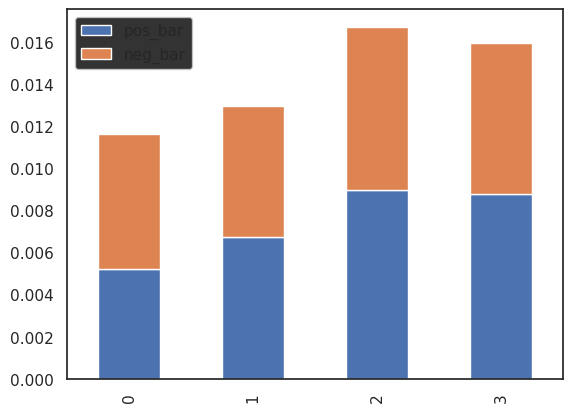

In [ ]:
df[['pos_bar', 'neg_bar']].plot(kind='bar', stacked=True)



  variant_type       neg       pos  total_variants  sig_variants  \
0       common  0.550459  0.449541            9377           109   
1         rare  0.479592  0.520408            7548            98   
2   ultra-rare  0.450980  0.549020            9572           153   
3    singleton  0.462963  0.537037            9684           162   

   sig_to_total_ratio  positive effect  negative effect  
0            0.011624         0.005226         0.006399  
1            0.012984         0.006757         0.006227  
2            0.015984         0.008776         0.007209  
3            0.016729         0.008984         0.007745  


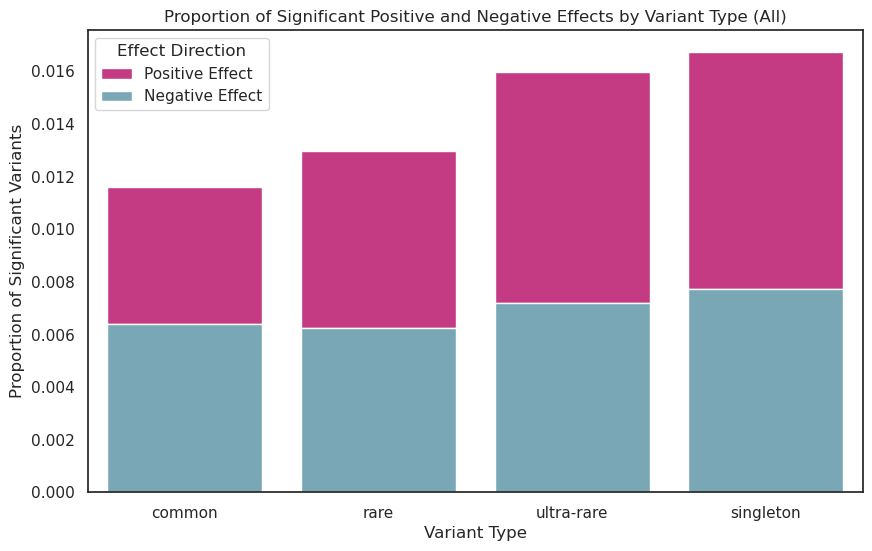

effect_direction,variant_type,neg,pos,Total Variants,Sig Variants
0,common,0.550459,0.449541,9377,109
1,rare,0.479592,0.520408,7548,98
2,singleton,0.462963,0.537037,9684,162
3,ultra-rare,0.450980,0.549020,9572,153


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def is_element_of(column_list, pattern):
    """Check for the pattern in the column_list"""
    return pattern in column_list

def plot_variant_type_variant_effect_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton']):
    """Plot the variant type proportion of significant variants with positive and negative effects"""

    if gene_set != None:
        matched_df = matched_df.loc[matched_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set))]

    if gene_set == None:
        gene_set = 'All'

    data = {
        'variant_type': ['common', 'rare', 'singleton', 'ultra-rare'],
        'neg': [0.550459, 0.479592, 0.462963, 0.450980],
        'pos': [0.449541, 0.520408, 0.537037, 0.549020],
        'total_variants': [9377, 7548, 9684, 9572],
        'sig_variants': [109, 98, 162, 153]
    }

    df = pd.DataFrame(data)

    # Compute the ratio of significant variants to total variants
    df['sig_to_total_ratio'] = df['sig_variants'] / df['total_variants']

    df['positive effect'] = df['sig_to_total_ratio'] * df['pos']
    df['negative effect'] = df['sig_to_total_ratio'] * df['neg']


    # sort df
    df_sorted = df.set_index('variant_type').loc[x_axis_order].reset_index()
    print(df_sorted)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))  # Adjust figure size for better fit
    colors = ['#70acc0', '#db2486']  # Colors for 'pos' and 'neg'
    # df_sorted[['positive effect', 'negative effect']].plot(kind='bar', stacked=True, color=colors)
    sns.barplot(x='variant_type', y='positive effect', data=df_sorted, color=colors[1], label='Positive Effect', bottom=df_sorted['negative effect'], ax=ax)
    sns.barplot(x='variant_type', y='negative effect', data=df_sorted, color=colors[0], label='Negative Effect', ax=ax)

    plt.title(f'Proportion of Significant Positive and Negative Effects by Variant Type ({gene_set})')
    plt.ylabel('Proportion of Significant Variants')
    plt.xlabel('Variant Type')
    # plt.ylim(0, 1.1)  # Slightly higher than 1 for better visualization

    # # Add annotations
    # ax = plt.gca()
    # for p in ax.patches:
    #     width = p.get_width()
    #     height = p.get_height()
    #     x, y = p.get_xy()
    #     ax.text(x + width/2,
    #             y + height/2,
    #             f'{height:.2f}',
    #             ha='center',
    #             va='center')

    plt.xticks(range(len(df_sorted)), df_sorted['variant_type'])


    # # Set the custom x-axis order if provided
    # if x_axis_order is not None:
    #     ax.set_xticklabels(x_axis_order)
    plt.legend(title='Effect Direction', loc='upper left', facecolor='white')
    # plt.legend(labels=['Positive Effect', 'Negative Effect'], title='Effect Direction', loc='upper left', facecolor='white')


    # # Annotate bars with the "number_significant/total_number"
    # patch_counter = 0
    # for i, patch in enumerate(ax.patches):
    #     if patch_counter >= effect_proportions.shape[0]:
    #         break
    #     # consider x_axis_order
    #     variant_type = x_axis_order[i]
    #     # get index
    #     variant_type_idx = df_sorted.loc[df_sorted['variant_type'] == variant_type].index.values[0]
    #     print(variant_type_idx)
    #     patch_counter += 1
    #     height = 0.001
    #     ax.text(
    #         patch.get_x() + patch.get_width() / 2,  # x coordinate
    #         height,  # y coordinate
    #         # f'{effect_proportions["Total Variants"].iloc[i]}',  # annotation text
    #         f'{df_sorted.iloc[variant_type_idx]["sig_variants"]}/{df_sorted.iloc[variant_type_idx]["total_variants"]}',  # annotation text
    #         ha='center',  # horizontal alignment
    #         va='top'  # vertical alignment
    #     )

    plt.savefig(os.path.join(plot_directory, f'significant_ratio_and_effect_direction.png'), dpi=300, bbox_inches='tight')
    plt.show()
    return effect_proportions

effect_proportions = plot_variant_type_variant_effect_barplot(merged_bcMPRAlm_snakeflow_info, gene_set=None)
effect_proportions
# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set='neuro')
# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set='random')
# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set='cardiac')
# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set='cava')

#### Working code

effect_direction variant_type       neg       pos  Total Variants  \
0                      common  0.550459  0.449541            9377   
1                        rare  0.479592  0.520408            7548   
2                   singleton  0.462963  0.537037            9684   
3                  ultra-rare  0.450980  0.549020            9572   

effect_direction  Sig Variants  
0                          109  
1                           98  
2                          162  
3                          153  
0
1
3
2


<Figure size 1000x600 with 0 Axes>

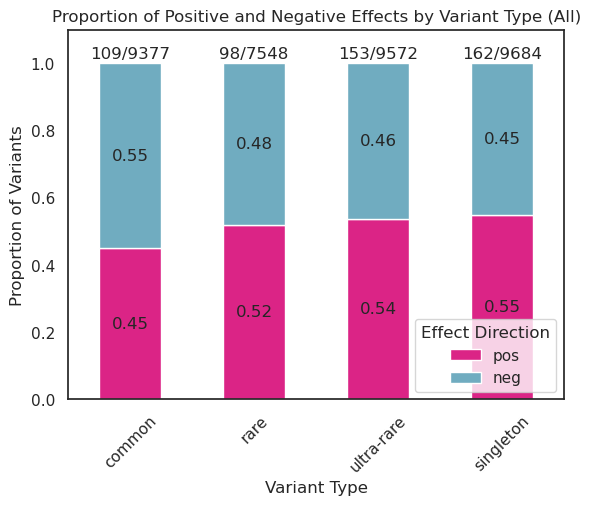

effect_direction,variant_type,neg,pos,Total Variants,Sig Variants
0,common,0.550459,0.449541,9377,109
1,rare,0.479592,0.520408,7548,98
2,singleton,0.462963,0.537037,9684,162
3,ultra-rare,0.450980,0.549020,9572,153


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def is_element_of(column_list, pattern):
    """Check for the pattern in the column_list"""
    return pattern in column_list

def plot_variant_type_barplot(matched_df, gene_set=None, x_axis_order=['common', 'rare', 'ultra-rare', 'singleton']):
    """Plot the variant type proportion of significant variants with positive and negative effects"""

    if gene_set != None:
        matched_df = matched_df.loc[matched_df['gene_set_list'].apply(lambda x: is_element_of(x, gene_set))]

    if gene_set == None:
        gene_set = 'All'

    # Get the significant df
    significant_variants_df = matched_df.loc[matched_df['adj.P.Val'] < 0.05]

    # Group by variant_type and effect_direction and count the occurrences
    effect_counts = significant_variants_df.groupby(['variant_type', 'effect_direction']).size().unstack(fill_value=0)
    # print(effect_counts)
    # Calculate the proportions of positive and negative effects within each variant type
    effect_proportions = effect_counts.div(effect_counts.sum(axis=1), axis=0).reset_index()
    # Add total counts and significant counts to the DataFrame for annotation
    total_variant_counts = matched_df['variant_type'].value_counts()
    effect_proportions['Total Variants'] = effect_proportions['variant_type'].map(total_variant_counts)
    significant_variant_counts = significant_variants_df['variant_type'].value_counts()
    effect_proportions['Sig Variants'] = effect_proportions['variant_type'].map(significant_variant_counts)
    # df_plot['Total Variants'] = df_plot['Variant Type'].map(total_variant_counts)
    # effect_proportions['Significant Variants'] = effect_proportions['variant_type'].map(significant_variant_counts)

    print(effect_proportions)
    # Plot
    plt.figure(figsize=(10, 6))  # Adjust figure size for better fit
    colors = ['#db2486', '#70acc0']  # Colors for 'pos' and 'neg'
    effect_proportions[['pos', 'neg']].plot(kind='bar', stacked=True, color=colors)
    plt.title(f'Proportion of Positive and Negative Effects by Variant Type ({gene_set})')
    plt.ylabel('Proportion of Variants')
    plt.xlabel('Variant Type')
    plt.ylim(0, 1.1)  # Slightly higher than 1 for better visualization

    # Add annotations
    ax = plt.gca()
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        ax.text(x + width/2,
                y + height/2,
                f'{height:.2f}',
                ha='center',
                va='center')



    # Set the custom x-axis order if provided
    if x_axis_order is not None:
        ax.set_xticklabels(x_axis_order, rotation=45)

    plt.legend(title='Effect Direction', loc='lower right', facecolor='white')


    # Annotate bars with the "number_significant/total_number"
    patch_counter = 0
    for i, patch in enumerate(ax.patches):
        if patch_counter >= effect_proportions.shape[0]:
            break
        # consider x_axis_order
        variant_type = x_axis_order[i]
        # get index
        variant_type_idx = effect_proportions.loc[effect_proportions['variant_type'] == variant_type].index.values[0]
        print(variant_type_idx)
        patch_counter += 1
        height = 1.05
        ax.text(
            patch.get_x() + patch.get_width() / 2,  # x coordinate
            height,  # y coordinate
            # f'{effect_proportions["Total Variants"].iloc[i]}',  # annotation text
            f'{effect_proportions.iloc[variant_type_idx]["Sig Variants"]}/{effect_proportions.iloc[variant_type_idx]["Total Variants"]}',  # annotation text
            ha='center',  # horizontal alignment
            va='top'  # vertical alignment
        )


    plt.show()
    return effect_proportions

effect_proportions = plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set=None)
effect_proportions
# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set='neuro')
# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set='random')
# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set='cardiac')
# plot_variant_type_barplot(merged_bcMPRAlm_snakeflow_info, gene_set='cava')

#### Next try with ChatGPT


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
data = {
    'variant_type': ['common', 'rare', 'singleton', 'ultra-rare'],
    'neg': [0.550459, 0.479592, 0.462963, 0.450980],
    'pos': [0.449541, 0.520408, 0.537037, 0.549020],
    'total_variants': [9377, 7548, 9684, 9572],
    'sig_variants': [109, 98, 162, 153]
}

df = pd.DataFrame(data)

# Compute the ratio of significant variants to total variants
df['sig_to_total_ratio'] = df['sig_variants'] / df['total_variants']

# Melt the dataframe to have a single column for neg and pos proportions
df_melted = df.melt(id_vars=['variant_type', 'sig_to_total_ratio'], value_vars=['neg', 'pos'],
                    var_name='Proportion Type', value_name='Proportion')

# Sort the DataFrame by the desired order
order = ['common', 'rare', 'ultra-rare', 'singleton']
df_melted['variant_type'] = pd.Categorical(df_melted['variant_type'], categories=order, ordered=True)
df_melted = df_melted.sort_values('variant_type')


In [ ]:
df_melted

,variant_type,sig_to_total_ratio,Proportion Type,Proportion,color
0,common,0.011624,neg,0.550459,#e69f00
4,common,0.011624,pos,0.449541,#db2486
1,rare,0.012984,neg,0.479592,#e69f00
5,rare,0.012984,pos,0.520408,#db2486
3,ultra-rare,0.015984,neg,0.450980,#305f79
7,ultra-rare,0.015984,pos,0.549020,#507f99
2,singleton,0.016729,neg,0.462963,#305f79
6,singleton,0.016729,pos,0.537037,#507f99


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sample data
data = {
    'variant_type': ['common', 'rare', 'singleton', 'ultra-rare'],
    'neg': [0.550459, 0.479592, 0.462963, 0.450980],
    'pos': [0.449541, 0.520408, 0.537037, 0.549020],
    'total_variants': [9377, 7548, 9684, 9572],
    'sig_variants': [109, 98, 162, 153]
}

df = pd.DataFrame(data)

# # Compute the ratio of significant variants to total variants
# df['sig_to_total_ratio'] = df['sig_variants'] / df['total_variants']

# # Melt the dataframe to have a single column for neg and pos proportions
# df_melted = df.melt(id_vars=['variant_type', 'sig_to_total_ratio'], value_vars=['neg', 'pos'],
#                     var_name='Proportion Type', value_name='Proportion')

# # Sort the DataFrame by the desired order
# order = ['common', 'rare', 'ultra-rare', 'singleton']
# df_melted['variant_type'] = pd.Categorical(df_melted['variant_type'], categories=order, ordered=True)
# df_melted = df_melted.sort_values('variant_type')

# # Define a custom color palette with darker colors for 'ultra-rare' and 'singleton'
# palette = {
#     'neg': {
#         'common': '#e69f00',
#         'rare': '#e69f00',
#         'ultra-rare': '#305f79',  # darker shade for ultra-rare neg
#         'singleton': '#305f79'    # darker shade for singleton neg
#     },
#     'pos': {
#         'common': '#db2486',
#         'rare': '#db2486',
#         'ultra-rare': '#507f99',  # darker shade for ultra-rare pos
#         'singleton': '#507f99'    # darker shade for singleton pos
#     }
# }

# # Function to map colors based on variant type and proportion type
# def get_color(row):
#     return palette[row['Proportion Type']][row['variant_type']]

# df_melted['color'] = df_melted.apply(get_color, axis=1)

# # Plot
# plt.figure(figsize=(10, 6))

# # Create a barplot with custom colors
# bars = sns.barplot(x='variant_type', y='sig_to_total_ratio', hue='Proportion Type', data=df_melted,
#                    dodge=False, palette=df_melted['color'].values, ci=None)

# plt.title('Ratio of Significant Variants to Total Variants by Type and Effect Direction')
# plt.ylabel('Ratio of Significant Variants to Total Variants')
# plt.xlabel('Variant Type')
# plt.ylim(0, max(df['sig_to_total_ratio']) * 1.1)  # Slightly higher than the max ratio for better visualization

# # Annotate bars with the "number_significant/total_number"
# for i, variant_type in enumerate(order):
#     # Get the y coordinate (height of the bar)
#     y = df.loc[df['variant_type'] == variant_type, 'sig_to_total_ratio'].values[0]

#     # Get the counts for the annotation
#     sig_variants = df.loc[df['variant_type'] == variant_type, 'sig_variants'].values[0]
#     total_variants = df.loc[df['variant_type'] == variant_type, 'total_variants'].values[0]

#     # Annotate
#     bars.text(
#         i,  # x coordinate
#         y,  # y coordinate
#         f'{sig_variants}/{total_variants}',  # annotation text
#         ha='center',  # horizontal alignment
#         va='bottom'  # vertical alignment
#     )

# plt.legend(title='Proportion Type')
# plt.show()


In [ ]:
merged_bcMPRAlm_snakeflow_info.columns

Index(['variant_log2FC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'B',
       'variant_id', 'INFO', 'AF', 'AC', 'enformer_variant_info', 'DNase_max',
       'enformer_class_list', 'gene_set_list', 'variant_type_list',
       'is_significant', 'assignment_number', 'Region', 'REF_ID', 'ALT_ID',
       'REF_ID_matchable', 'ALT_ID_matchable', 'REF_mean_log2',
       'REF_mean_n_obs_bc', 'ALT_mean_log2', 'ALT_mean_n_obs_bc',
       'sequence_DNase_max', 'sequence_max_col', 'neuro_specific_DNase_median',
       'is_rare', 'REF_mean_log2_bin', 'sequence_DNase_max_bin',
       'neuro_specific_DNase_median_bin', 'variant_type', 'effect_direction'],
      dtype='object')

##### Plot the violin plots of controls 
1. load mprasnakeflow info
2. make new label based on control vs tested 
3. plot ridge plot

In [49]:

neuro_controls = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK',  'C_negative_neuron_MK']
neuro_controls = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK']
neuro_controls = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK',  'C_negative_neuron_MK']
positive_controls = [control for control in neuro_controls if 'positive' in control.lower()]
negative_controls = [control for control in neuro_controls if 'negative' in control.lower()]

def is_pos_control(label):
    """returns if positive control"""
    return 'yes' if label in positive_controls else 'no'

def is_neg_control(label):
    """returns if positive control"""
    return 'yes' if label in negative_controls else 'no'

def is_tested_sequence(label):
    """returns if tested sequence"""
    return 'yes' if label == 'cardiac_neuro_cava_random' else 'no'

def is_tested_variant(row, header):
    if is_tested_sequence(row['label']):
        if has_variant_info_in_header(row[header]):
            return 'yes'
    else:
        return 'no'

def plotting_control_tested_column(row):
    if row['is_positive_control'] == 'yes':
        return 'positive control'
    elif row['is_negative_control'] == 'yes':
        return 'negative control'
    elif row['is_tested_variant'] == 'yes':
        return 'tested sequences'
    else:
        return np.nan

In [46]:
# read MPRAsnakeflow results
mprasnakeflow_count_df = pd.read_csv(config['files']['creating']['mprasnakeflow_resequencing_count_minthreshold'], sep='\t')

# merge the sequences over the replicates
total_dna_counts = mprasnakeflow_count_df[["dna_counts"]].sum().iloc[0]
total_rna_counts = mprasnakeflow_count_df[["rna_counts"]].sum().iloc[0]
combined_df = combine_replicates(mprasnakeflow_count_df, total_dna_counts, total_rna_counts)
# filter it
combined_filtered_df = combined_df.loc[combined_df['replicates'] == 3]
# tested_combined_filtered_df = combined_filtered_df.loc[combined_filtered_df['name'].str.startswith('cardiac_neuro_cava_random')]
combined_filtered_df['label'] = combined_filtered_df['name'].apply(hf.get_label)

/tmp/ipykernel_474412/608307881.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_filtered_df['label'] = combined_filtered_df['name'].apply(hf.get_label)


In [47]:
combined_filtered_df.head()

,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc,label
0,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1359,3366,12.862398,13.366456,1.039189,0.055457,453.000000,1122.000000,0.112556,0.117015,1.074407,0.102679,114,C_SLEA
1,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|103:...,3,1458,6650,13.799394,26.407289,1.913656,0.936331,486.000000,2216.666667,0.132854,0.254553,1.989397,0.983514,103,C_SLEA
2,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,824,2161,7.798835,8.581376,1.100341,0.137950,274.666667,720.333333,0.107339,0.117987,1.140071,0.186331,72,C_SLEA
3,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,1198,2928,11.338597,11.627149,1.025449,0.036255,399.333333,976.000000,0.117521,0.120830,1.065769,0.088221,96,C_SLEA
4,NGN2,C_SLEA:SLEA_hg18:chr2:210861483-210861650|10:V...,3,742,1840,7.022737,7.306678,1.040432,0.057182,247.333333,613.333333,0.124235,0.129395,1.075619,0.105127,56,C_SLEA


In [50]:
combined_filtered_df['is_positive_control'] = combined_filtered_df['label'].apply(is_pos_control)
combined_filtered_df['is_negative_control'] = combined_filtered_df['label'].apply(is_neg_control)
# combined_filtered_df['is_tested_sequence'] = combined_filtered_df['label'].apply(is_tested_sequence)
combined_filtered_df['is_tested_variant'] = combined_filtered_df.apply(lambda row: is_tested_variant(row, 'name'), axis=1)
combined_filtered_df['combined_plotting_column'] = combined_filtered_df.apply(plotting_control_tested_column, axis=1)
combined_filtered_df.head()
combined_filtered_df['is_positive_control'].value_counts()
combined_filtered_df['is_negative_control'].value_counts()

/tmp/ipykernel_474412/1171389295.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_filtered_df['is_positive_control'] = combined_filtered_df['label'].apply(is_pos_control)
/tmp/ipykernel_474412/1171389295.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_filtered_df['is_negative_control'] = combined_filtered_df['label'].apply(is_neg_control)
/tmp/ipykernel_474412/1171389295.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[

is_negative_control
no     67555
yes      278
Name: count, dtype: int64

/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.ti

NameError: name 'plot_directory' is not defined

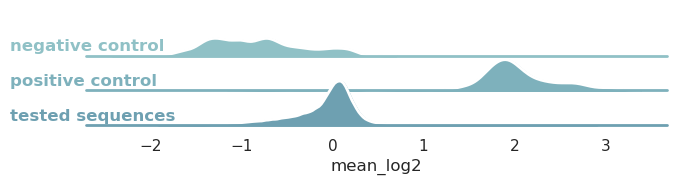

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# # Create the data
# rs = np.random.RandomState(1979)
# x = rs.randn(500)
# g = np.tile(list("ABCDEFGHIJ"), 50)
# df = pd.DataFrame(dict(x=x, g=g))
# m = df.g.map(ord)
# df["x"] += m
combined_filtered_df


# Initialize the FacetGrid object
pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
g = sns.FacetGrid(combined_filtered_df, row="combined_plotting_column", hue="combined_plotting_column", aspect=15, height=.5, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "mean_log2",
      bw_adjust=.5, clip_on=False,
      fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "mean_log2", clip_on=False, color="w", lw=2, bw_adjust=.5)

# passing color=None to refline() uses the hue mapping
g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)


# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
      ax = plt.gca()
      ax.text(-0.13, .2, label, fontweight="bold", color=color, ha="left", va="center", transform=ax.transAxes)


g.map(label, "mean_log2")

# Set the subplots to overlap
g.figure.subplots_adjust(hspace=-.25)

# Remove axes details that don't play well with overlap
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# save figure
plt.savefig(os.path.join(plot_directory, f'controls_vs_tested_sequences.png'), dpi=300, bbox_inches='tight')


In [ ]:
tested_combined_filtered_df.columns
neuro_controls = ['C_negative_neuron_NP', 'C_positive_neuron_NP', 'C_positive_neuron_MK',  'C_negative_neuron_MK', 'C_positive_neuron_CD']
print(positive_controls)
positive_controls = [control for control in neuro_controls if 'positive' in control.lower()]
negative_controls = [control for control in neuro_controls if 'negative' in control.lower()]
tested_combined_filtered_df.head()

['C_positive_neuron_NP', 'C_positive_neuron_MK', 'C_positive_neuron_CD']


,condition,name,replicates,dna_counts,rna_counts,dna_normalized,rna_normalized,ratio,log2,mean_dna_counts,mean_rna_counts,mean_dna_normalized,mean_rna_normalized,mean_ratio,mean_log2,mean_n_obs_bc
5031,NGN2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,3,514,542,4.864807,2.152293,0.442421,-1.176508,171.333333,180.666667,0.065751,0.029089,0.477339,-1.103574,73
5032,NGN2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,3,397,841,3.757448,3.339629,0.888802,-0.170066,132.333333,280.333333,0.115645,0.103014,0.918697,-0.123676,32
5033,NGN2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,3,960,1950,9.086021,7.743491,0.852242,-0.230665,320.000000,650.000000,0.095385,0.081132,0.880412,-0.184839,95
5034,NGN2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,3,537,1193,5.082493,4.737428,0.932107,-0.101432,179.000000,397.666667,0.118911,0.110827,0.966114,-0.051317,42
5035,NGN2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,3,211,401,1.997032,1.592379,0.797373,-0.326673,70.333333,133.666667,0.068492,0.054899,0.829968,-0.270851,29


In [ ]:
# function for plotting a specific list of labels as violin plot
def plot_subgroup_violin(labels_list, save_path=None, alternative_labels=None, colors=None):
    """Plot a violin plot just for a subset of labels
    @colors: dict of colors for each label
    """
    subset_rep_label_df = merged_bcMPRAlm_snakeflow_info[merged_bcMPRAlm_snakeflow_info["label"].isin(labels_list)]
    avg_seq_per_label = int(subset_rep_label_df.groupby("label").count()["name"].mean())

    fig, ax = plt.subplots(figsize=(10,8))
    ax.set_title(f'Log2 for {len(labels_list)} labels and average number of sequences per label is {avg_seq_per_label}')
    if colors:
        sns.violinplot(x=subset_rep_label_df["label"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df["label"], ax=ax, palette=colors)
    else:
        sns.violinplot(x=subset_rep_label_df["label"], y=subset_rep_label_df["log2"], hue=subset_rep_label_df["label"], ax=ax)

    if alternative_labels:
        # add alternative labels
        ax.set_xticklabels(alternative_labels)
    plt.xticks(rotation=90)
    ax.set_xlabel('Label')
    ax.set_ylabel('log2(RNA/DNA)')
    # add line at 0
    ax.axhline(y=0, color='black', linestyle='--')
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight') # bbox_inches='tight' to prevent cutting off labels


In [ ]:
# for keeping the colors
color_dict = {'GC_DNase_negative_blood': sns.color_palette()[0+4], 'GC_DNase_negative_blood_shuffeled': sns.color_palette()[1+4], 'GC_DNase_negative_brain': sns.color_palette()[2+4], 'GC_DNase_negative_brain_shuffeled': sns.color_palette()[3+4], 'GC_DNase_positive': sns.color_palette()[4+4], 'GC_DNase_positive_shuffeled': sns.color_palette()[5+4]}

# all DNase from encode
plot_subgroup_violin(['GC_DNase_positive', 'GC_DNase_positive_shuffeled'], "/data/gpfs-1/users/kisa11_c/work/coding/80K_analysis/02_controls/GC_DNase_positive_vs_shuffeled.png", None, color_dict)


#### Investigating if enformer numbers are fine
- explode the variant table of the prioritized df to get all the 35000 variants (makes sense)

In [ ]:
enformer_class_df = common_enformer_varaint_df.loc[~common_enformer_varaint_df['DNase_max'].isna()]

# Explode the list of tuples into separate rows
df_exploded = enformer_class_df.explode('enformer_variant_info')

# Split the tuples into separate columns
df_exploded[['gene_set', 'variant_type', 'enformer_class']] = pd.DataFrame(df_exploded['enformer_variant_info'].tolist(), index=df_exploded.index)

# Perform a simple groupby operation as an example (e.g., count occurrences)
grouped_df = df_exploded.groupby(['gene_set','variant_type']).size().reset_index(name='counts')

# Display the grouped DataFrame
print(grouped_df)
#   gene_set variant_type  counts
# 0  cardiac    singleton    5000
# 1  cardiac   ultra-rare    5000
# 2     cava    singleton    5000
# 3     cava   ultra-rare    5000
# 4    neuro    singleton    5000
# 5    neuro   ultra-rare    5000
# 6   random    singleton    2500
# 7   random   ultra-rare    2500

  gene_set variant_type  counts
0  cardiac    singleton    5000
1  cardiac   ultra-rare    5000
2     cava    singleton    5000
3     cava   ultra-rare    5000
4    neuro    singleton    5000
5    neuro   ultra-rare    5000
6   random    singleton    2500
7   random   ultra-rare    2500


#### Use this exploded dataframe to change the class of the enformer prediction: resample real random

In [ ]:
df_exploded

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,chr_pos_ref_alt,variant_type,gene_set,enformer_class
34954,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,1,PASS,AF=6.57168e-06;AC=1,4254.341000,392_DNASE:CD14-positive,"(cardiac, singleton, enformer_high)",[enformer_high],[cardiac],[singleton],6-43797164-G-A,singleton,cardiac,enformer_high
34955,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,1,PASS,AF=6.56866e-06;AC=1,4022.599600,"177_DNASE:CD8-positive,","(cardiac, singleton, enformer_high)",[enformer_high],[cardiac],[singleton],18-3059465-T-C,singleton,cardiac,enformer_high
34956,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,1,PASS,AF=6.57618e-06;AC=1,3591.831000,392_DNASE:CD14-positive,"(cardiac, singleton, enformer_high)",[enformer_high],[cardiac],[singleton],6-43797016-G-A,singleton,cardiac,enformer_high
34957,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1,PASS,AF=6.56763e-06;AC=1,2754.770500,401_DNASE:common myeloid,"(cardiac, singleton, enformer_high)",[enformer_high],"[cardiac, neuro]",[singleton],12-2616967-C-A,singleton,cardiac,enformer_high
34957,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1,PASS,AF=6.56763e-06;AC=1,2754.770500,401_DNASE:common myeloid,"(neuro, singleton, enformer_high)",[enformer_high],"[cardiac, neuro]",[singleton],12-2616967-C-A,singleton,neuro,enformer_high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69200,chr2,219219689,ANKZF1|ENSG00000163516.14|EH38E3401197|2-21921...,T,G,1,PASS,AF=1.97075e-05;AC=3,-0.586787,31_DNASE:iPS-NIHi11 mal,"(random, ultra-rare, enformer_low)",[enformer_low],[random],[ultra-rare],2-219219689-T-G,ultra-rare,random,enformer_low
69201,chr19,48747089,IZUMO1|ENSG00000182264.9|EH38E1960256|19-48747...,C,T,1,PASS,AF=1.31413e-05;AC=2,-0.961862,90_DNASE:HeLa-S3 G1b ph,"(random, ultra-rare, enformer_low)",[enformer_low],[random],[ultra-rare],19-48747089-C-T,ultra-rare,random,enformer_low
69202,chr2,210475933,CPS1|ENSG00000021826.18|EH38E3397490|2-2104759...,C,A,1,PASS,AF=2.62871e-05;AC=4,-0.964058,665_DNASE:testis male ad,"(random, ultra-rare, enformer_low)",[enformer_low],[random],[ultra-rare],2-210475933-C-A,ultra-rare,random,enformer_low
69203,chr2,210477091,CPS1|ENSG00000021826.18|EH38E3397493|2-2104770...,C,T,1,PASS,AF=7.60025e-05;AC=11,-1.122092,170_DNASE:iPS DF 4.7 mal,"(random, ultra-rare, enformer_low)",[enformer_low],[random],[ultra-rare],2-210477091-C-T,ultra-rare,random,enformer_low


In [ ]:
enformer_class_df['enformer_variant_info'].value_counts()

enformer_variant_info
[(cava, ultra-rare, enformer_high)]                                                                              3407
[(cava, singleton, enformer_high)]                                                                               3388
[(neuro, ultra-rare, enformer_high)]                                                                             3272
[(neuro, singleton, enformer_high)]                                                                              3266
[(cardiac, ultra-rare, enformer_high)]                                                                           3254
[(cardiac, singleton, enformer_high)]                                                                            3233
[(random, ultra-rare, enformer_high)]                                                                            1750
[(random, singleton, enformer_high)]                                                                             1750
[(cardiac, singleton, enformer_ran

In [ ]:
enformer_class_df = common_enformer_varaint_df.loc[~common_enformer_varaint_df['DNase_max'].isna()]
enformer_class_df['variant_type_list'].value_counts()
enformer_class_df['variant_type'] = enformer_class_df['variant_type_list'].apply(get_element_from_list)
print(enformer_class_df['variant_type'].value_counts())
enformer_class_df['gene_set_list'].value_counts()
# enformer_class_df['gene_set'] = enformer_class_df['gene_set_list'].apply(get_element_from_list)
# enformer_class_df['gene_set'].value_counts()

variant_type
ultra-rare    17130
singleton     17121
Name: count, dtype: int64


/tmp/ipykernel_2196/3208550915.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enformer_class_df['variant_type'] = enformer_class_df['variant_type_list'].apply(get_element_from_list)


gene_set_list
[cava]                    9703
[neuro]                   9470
[cardiac]                 9350
[random]                  5000
[cardiac, neuro]           431
[cardiac, cava]            198
[neuro, cava]               78
[cardiac, neuro, cava]      21
Name: count, dtype: int64

### Computing numbers of variant types and gene sets comparison of variant numbers based on significant vs in design comparison
- (In design)
- After MPRAlm 
- Significant

- in design:
    - variant_type
        - ulra-rare    12043
        - common       12016
        - singleton    11955
        - rare          9723
    - gene_set
        - [neuro]                   19039
        - [cardiac]                 12975
        - [cava]                     6956
        - [random]                   3991
        - [neuro, cardiac]           1364
        - [neuro, cava]               679
        - [cava, cardiac]             601
        - [neuro, cava, cardiac]      132
- after MPRAlm:
  - variant_type
    - singleton    9681
    - ulra-rare    9569
    - common       9374
    - rare         7544
- significant:
  -   variant_type  count
    -    singleton    162
    -    ulra-rare    152
    -       common    109
    -         rare     98


In [ ]:
common_enformer_varaint_df['AF'] = common_enformer_varaint_df['INFO'].apply(get_AF)
common_enformer_varaint_df['AC'] = common_enformer_varaint_df['INFO'].apply(get_AC)
# print(common_enformer_varaint_df.head())

# find highest AF with enformer class
enformer_class_df = common_enformer_varaint_df.loc[~common_enformer_varaint_df['DNase_max'].isna()]
enformer_common_variants = common_enformer_varaint_df.loc[common_enformer_varaint_df['DNase_max'].isna()]
print('Highest AF with enformer priorization: ', enformer_class_df.sort_values(by='AF', ascending=False).head(1)['AF'])
print('Lowest AF without enformer priorization: ', enformer_common_variants.sort_values(by='AF', ascending=True).head(1)['AF'])

Highest AF with enformer priorization:  59094    0.009957
Name: AF, dtype: float64
Lowest AF without enformer priorization:  8496    0.010002
Name: AF, dtype: float64


##### Merge the enformer priorization to the ultra-rare variants (AF < 0.01)
- make enformer class variant df with chrom pos ref alt unique

In [ ]:
enformer_class_df.head()

,CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,chr_pos_ref_alt,AF,AC
34954,chr6,43797164,VEGFA|ENSG00000112715.26|EH38E3709352|6-437971...,G,A,1,PASS,AF=6.57168e-06;AC=1,4254.3410,392_DNASE:CD14-positive,"[('cardiac', 'singleton', 'enformer_high')]",['enformer_high'],['cardiac'],['singleton'],6-43797164-G-A,0.000007,1
34955,chr18,3059465,MYOM1|ENSG00000101605.14|EH38E3253954|18-30594...,T,C,1,PASS,AF=6.56866e-06;AC=1,4022.5996,"177_DNASE:CD8-positive,","[('cardiac', 'singleton', 'enformer_high')]",['enformer_high'],['cardiac'],['singleton'],18-3059465-T-C,0.000007,1
34956,chr6,43797016,VEGFA|ENSG00000112715.26|EH38E3709352|6-437970...,G,A,1,PASS,AF=6.57618e-06;AC=1,3591.8310,392_DNASE:CD14-positive,"[('cardiac', 'singleton', 'enformer_high')]",['enformer_high'],['cardiac'],['singleton'],6-43797016-G-A,0.000007,1
34957,chr12,2616967,CACNA1C|ENSG00000151067.23|EH38E2998634|12-261...,C,A,1,PASS,AF=6.56763e-06;AC=1,2754.7705,401_DNASE:common myeloid,"[('cardiac', 'singleton', 'enformer_high'), ('...",['enformer_high'],"['cardiac', 'neuro']",['singleton'],12-2616967-C-A,0.000007,1
34958,chr7,151848098,PRKAG2|ENSG00000106617.15|EH38E2601935|7-15184...,A,C,1,PASS,AF=6.56978e-06;AC=1,2746.3271,392_DNASE:CD14-positive,"[('cardiac', 'singleton', 'enformer_high')]",['enformer_high'],['cardiac'],['singleton'],7-151848098-A-C,0.000007,1


In [ ]:
tested_vcf_interesting_cols['variant_type'].value_counts()

variant_type
ulra-rare    12043
common       12016
singleton    11955
rare          9723
Name: count, dtype: int64

In [ ]:
# how to group by with a list of elements?
# how to explode these elements?
# I could count with is_element function over all gene_set values


In [ ]:
# get ultra rare and find numbers of enformer classes
ultra_rare_design = tested_vcf_interesting_cols.loc[tested_vcf_interesting_cols['AF'] < 0.01]
# ultra_rare_design.head()
ultra_rare_design['chr_pos_ref_alt'] = ultra_rare_design['ID'].apply(get_chrom_pos_ref_alt_pattern)

design_variants_enformer_class = ultra_rare_design.merge(enformer_class_df, on='chr_pos_ref_alt', how='left')
print('Number of variants AF <= 1% with enformer class', design_variants_enformer_class.shape[0])
not_merged_enformer_design = design_variants_enformer_class.loc[design_variants_enformer_class['enformer_class_list'].isna()]
not_merged_enformer_design # empty

Number of variants AF <= 1% with enformer class 24098


/tmp/ipykernel_2196/888014018.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ultra_rare_design['chr_pos_ref_alt'] = ultra_rare_design['ID'].apply(get_chrom_pos_ref_alt_pattern)


,ID_x,INFO_x,semicolon_split_variant_id,AF_x,AC_x,gene_set,variant_type,chr_pos_ref_alt,CHROM,POS,...,FILTER,INFO_y,DNase_max,max_col,enformer_variant_info,enformer_class_list,gene_set_list,variant_type_list,AF_y,AC_y


### Reorganize the enformer class values

#### Variant type
- in design, after MPRAlm, significant

In [ ]:
def print_value_counts_variant_type(df, column):
    print(column)
    print(df[column].value_counts().reset_index())


def print_value_counts_gene_set(df, column, gene_set, df_type):
    print(f'{df_type}\t{gene_set}\t{df.loc[df[column].apply(lambda x: is_element_of(x, gene_set))].shape[0]}')


In [ ]:
print_value_counts(tested_vcf_interesting_cols, 'variant_type')
print_value_counts(bcMPRAlm_variant_info, 'variant_type')
print_value_counts(bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['adj.P.Val'] <= 0.05], 'variant_type')

variant_type
  variant_type  count
0    ulra-rare  12043
1       common  12016
2    singleton  11955
3         rare   9723
variant_type
  variant_type  count
0    singleton   9681
1    ulra-rare   9569
2       common   9374
3         rare   7544
variant_type
  variant_type  count
0    singleton    162
1    ulra-rare    152
2       common    109
3         rare     98


In [ ]:
tested_vcf_interesting_cols.variant_type.value_counts()

variant_type
ulra-rare    12043
common       12016
singleton    11955
rare          9723
Name: count, dtype: int64

In [ ]:
bcMPRAlm_variant_info.variant_type.value_counts()

variant_type
singleton    9681
ulra-rare    9569
common       9374
rare         7544
Name: count, dtype: int64

In [ ]:
bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['adj.P.Val'] <= 0.05].variant_type.value_counts()

variant_type
singleton    162
ulra-rare    152
common       109
rare          98
Name: count, dtype: int64

#### Gene sets numbers

In [ ]:
for elem in ['neuro', 'cardiac', 'cava', 'random']:
    print_value_counts_gene_set(tested_vcf_interesting_cols, 'gene_set', elem, 'in design')
    print_value_counts_gene_set(bcMPRAlm_variant_info, 'gene_set', elem, 'after MPRAlm')
    print_value_counts_gene_set(bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['adj.P.Val'] <= 0.05], 'gene_set', elem, 'significant')

NameError: name 'is_element_of' is not defined

In [ ]:
bcMPRAlm_variant_info.variant_type.value_counts()

# in design
# variant_type
# ulra-rare    12043
# common       12016
# singleton    11955
# rare          9723
bcMPRAlm_variant_info.gene_set.value_counts()
# gene_set
# [neuro]                   19039
# [cardiac]                 12975
# [cava]                     6956
# [random]                   3991
# [neuro, cardiac]           1364
# [neuro, cava]               679
# [cava, cardiac]             601
# [neuro, cava, cardiac]      132
# bcMPRAlm_variant_info.head()

gene_set
[neuro]             14997
[cardiac]           10167
[cava]               5729
[random]             3460
[neuro, cardiac]     1007
[neuro, cava]         405
[cava, cardiac]       403
Name: count, dtype: int64

### Rest API tries (not working) + max solution

#### variant vcf only holds AF need to add allele count as well using gnomad api (not working)

In [ ]:
# get chrom pos ref alt
bcMPRAlm_variant_info['chr_pos_ref_alt'] = bcMPRAlm_variant_info['variant_id'].apply(get_chrom_pos_ref_alt_pattern)
bcMPRAlm_variant_info['chr_pos_ref_alt'].to_list()

['5-14408059-A-G',
 '5-14259916-C-T',
 '2-219267001-T-C',
 '3-142578095-C-G',
 '16-68784390-A-G',
 '5-14408083-G-T',
 '22-42115774-T-C',
 '14-68160488-A-G',
 '11-35289966-C-T',
 '6-26200568-C-A',
 '1-231734633-A-G',
 '20-44320090-C-T',
 '1-156152803-G-A',
 '22-42115723-G-T',
 '6-26269112-G-T',
 '3-119305469-T-C',
 '2-24521257-G-A',
 '2-51080053-G-C',
 '17-62454069-C-A',
 '6-112217495-C-A',
 '1-155893774-A-G',
 '5-14220365-A-G',
 '1-2288508-G-A',
 '1-162145083-C-A',
 '8-11642458-G-A',
 '3-49025606-G-C',
 '12-110946320-A-C',
 '8-22998252-A-G',
 '8-89975337-T-C',
 '6-396321-C-T',
 '3-177151094-T-C',
 '16-78489369-T-A',
 '2-224528405-C-T',
 'X-31863206-G-T',
 '10-28594009-C-G',
 '7-76109162-T-G',
 '11-119266930-C-T',
 '11-47306237-C-G',
 '6-360502-G-A',
 '18-51009316-C-A',
 '7-88218304-G-T',
 '6-26200534-A-T',
 '5-54362150-G-C',
 '22-36196008-T-C',
 '19-49904314-T-C',
 '3-71252686-G-C',
 '18-58789253-A-G',
 '5-14190469-A-G',
 '3-71087444-G-T',
 '1-155893818-T-C',
 '1-162145085-A-G',
 '17-4

In [ ]:
bcMPRAlm_variant_info.loc[bcMPRAlm_variant_info['chr_pos_ref_alt'] == '5-14259916-C-T']['INFO'].to_list()

['Region=TRIO|ENSG00000038382.23|EH38E3627037_fwd_tile1-1;REF_ID=REF_TRIO|ENSG00000038382.23|EH38E3627037_fwd_tile1-1;ALT_ID=ALT_TRIO|ENSG00000038382.23|EH38E3627037_fwd_tile1-1_TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T;AF=0.0168281']

#### Using Lusi's code with gnomoad file (taking very long and post processing required)
-  awk -v FS='\t' -v OFS='\t'   'FNR==NR{{a[$1,$2,$3,$4]=$0;next}}{{if(b=a[$1,$2,$3,$4]){{print b,$5,$6}}}}' <( tabix -h input.gnomad -R  input.bin_file | bcftools  query -f '%CHROM\t%POS\t%REF\t%ALT\t%INFO/AC\t%INFO/AF\n' )   input.bin_file | bgzip -c> output
- gnomad = "/data/cephfs-2/unmirrored/groups/ag-kircher/CADD/projects/bravo3/gnomad/gnomad.genomes.r3.0.sites.vcf.bgz"
- input.bin_file  ist deine Datei (TAB delimited: a TAB-delimited file with CHROM, POS, and, optionally, POS_TO columns, where positions are 1-based and inclusive.)
- How to verify 1-based positions


awk -v FS='\t' -v OFS='\t'   'FNR==NR{{a[$1,$2,$3,$4]=$0;next}}{{if(b=a[$1,$2,$3,$4]){{print b,$5,$6}}}}' <( tabix -h /data/cephfs-2/unmirrored/groups/ag-kircher/CADD/projects/bravo3/gnomad/gnomad.genomes.r3.0.sites.vcf.bgz -R  /data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/resources/gnomad/variants_of_interest_80K.tsv | bcftools  query -f '%CHROM\t%POS\t%REF\t%ALT\t%INFO/AC\t%INFO/AF\n' )   /data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/resources/gnomad/variants_of_interest_80K.tsv | bgzip -c> /data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/resources/gnomad/tabix_output_interesting_variants_gnomadv3.0

In [ ]:
vcf_file

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,semicolon_split_variant_id
0,chr1,2179591,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,C,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778471_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
1,chr1,2191444,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778490_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
2,chr1,2192015,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,T,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778492_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
3,chr1,2192366,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,G,.,PASS,Region=SKI|ENSG00000157933.11|EH38E1311587_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
4,chr1,2193142,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778494_fwd...,cardiac_neuro_cava_random:SKI|ENSG00000157933....
...,...,...,...,...,...,...,...,...,...
46138,chrX,154545206,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,A,G,.,PASS,Region=G6PD|ENSG00000160211.20|EH38E3949733_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...
46139,chrX,154549923,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,T,G,.,PASS,Region=G6PD|ENSG00000160211.20|EH38E2774396_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...
46140,chrX,154552289,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,C,T,.,PASS,Region=G6PD|ENSG00000160211.20|EH38E3949745_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...
46141,chrX,154552371,cardiac_neuro_cava_random:G6PD|ENSG00000160211...,G,A,.,PASS,Region=G6PD|ENSG00000160211.20|EH38E3949745_re...,cardiac_neuro_cava_random:G6PD|ENSG00000160211...


In [ ]:
# write tsv of interest
# # Split the 'variant' column into multiple columns
# split_columns = vcf_file['chr_pos_ref_alt'].str.split('-', expand=True)

# # Assign the new columns to 'CHROM' and 'POS'
# vcf_file['CHROM'] = split_columns[0]
# vcf_file['POS'] = split_columns[1]

# Display the resulting DataFrame
gnomad_search = vcf_file[['#CHROM', 'POS']]
gnomad_search.columns = ['CHROM', 'POS']

# gnomad_search.to_csv('variants_of_interest_80K.tsv', sep="\t", index=False)

# # write to file
# vcf_file[['CHROM', 'POS']].to_csv('')

In [ ]:
!pip install requests graphql-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.9/202.9 kB 4.0 MB/s eta 0:00:00a 0:00:01


In [ ]:
import requests
from graphql import build_client_schema, print_schema, graphql_sync
from graphql.language import parse
from graphql.utilities import build_client_schema


# Function to batch a list into smaller lists of a given size
def batch_list(input_list, batch_size):
    for i in range(0, len(input_list), batch_size):
        yield input_list[i:i + batch_size]



# Function to construct the GraphQL query dynamically
def construct_graphql_query(variants, dataset):
    query = "{\n"
    for i, variant_id in enumerate(variants):
        query += f"""
  variant{i + 1}: variant(variantId: "{variant_id}", dataset: {dataset}) {{
    variantId
    chrom
    pos
    ref
    alt
    joint {{
      ac
    }}
  }}\n"""
    query += "}"
    return query

# List of variants (example)
# variants = [
#     {"chrom": "6", "pos": 112217495, "ref": "C", "alt": "A"},
#     {"chrom": "1", "pos": 55516888, "ref": "G", "alt": "A"},
#     {"chrom": "5", "pos": 14259916, "ref": "C", "alt": "T"}
# ]
variants = bcMPRAlm_variant_info['chr_pos_ref_alt'].to_list()
# Dataset ID
dataset = "gnomad_r4"

# GraphQL API endpoint
graphql_endpoint = "https://gnomad.broadinstitute.org/api"

# Batch size
batch_size = 25

# Process each batch
results = []
batch_count = 0
successful_batches = 0
for batch in batch_list(variants, batch_size):
    if (batch_count % 6 == 0) and (batch_count > 0):
      time.sleep(10)  # Sleep to avoid hitting rate limits
    graphql_query = construct_graphql_query(batch, dataset)
    try:
        # Send GraphQL request
        response = requests.post(graphql_endpoint, json={"query": graphql_query})
        response.raise_for_status()  # Check if the request was successful
        json_response = response.json()
        results.append(json_response)
        print(response)
        successful_batches += 1
    except requests.exceptions.HTTPError as http_err:
        print(f"HTTP error occurred: {http_err}")
    except requests.exceptions.RequestException as req_err:
        print(f"Request error occurred: {req_err}")
    except Exception as err:
        print(f"An error occurred: {err}")
    batch_count += 1
    if batch_count % 5 == 0:
      print('Number of successful batches: ', successful_batches)




# # Parse the response JSON
# response_json = response.json()

# # Extract variant data from the response
# variant_data = {}
# for variant_alias, variant_info in response_json["data"].items():
#     variant_data[variant_alias] = variant_info

# # Print variant data
# for variant_alias, variant_info in variant_data.items():
#     print(f"Variant: {variant_alias}")
#     print(variant_info)
#     print()

<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
Number of successful batches:  5
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
Number of successful batches:  10
HTTP error occurred: 429 Client Error: Too Many Requests for url: https://gnomad.broadinstitute.org/api
HTTP error occurred: 429 Client Error: Too Many Requests for url: https://gnomad.broadinstitute.org/api
<Response [200]>
<Response [200]>
<Response [200]>
Number of successful batches:  13
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
<Response [200]>
Number of successful batches:  18
<Response [200]>
<Response [200]>
HTTP error occurred: 429 Client Error: Too Many Requests for url: https://gnomad.broadinstitute.org/api
HTTP error occurred: 429 Client Error: Too Many Requests for url: https://gnomad.broadinstitute.org/api
HTTP error occurred: 429 Client Error: Too Many Requests for url: https://gnomad.broadinstitute.org/api
Numbe

KeyboardInterrupt: 

In [ ]:
results

[{'data': {'variant1': {'variantId': '5-14408059-A-G',
    'chrom': '5',
    'pos': 14408059,
    'ref': 'A',
    'alt': 'G',
    'joint': {'ac': 1}},
   'variant2': {'variantId': '5-14259916-C-T',
    'chrom': '5',
    'pos': 14259916,
    'ref': 'C',
    'alt': 'T',
    'joint': {'ac': 2556}},
   'variant3': {'variantId': '2-219267001-T-C',
    'chrom': '2',
    'pos': 219267001,
    'ref': 'T',
    'alt': 'C',
    'joint': {'ac': 1}},
   'variant4': {'variantId': '3-142578095-C-G',
    'chrom': '3',
    'pos': 142578095,
    'ref': 'C',
    'alt': 'G',
    'joint': {'ac': 7}},
   'variant5': {'variantId': '16-68784390-A-G',
    'chrom': '16',
    'pos': 68784390,
    'ref': 'A',
    'alt': 'G',
    'joint': {'ac': 1}},
   'variant6': {'variantId': '5-14408083-G-T',
    'chrom': '5',
    'pos': 14408083,
    'ref': 'G',
    'alt': 'T',
    'joint': {'ac': 1}},
   'variant7': {'variantId': '22-42115774-T-C',
    'chrom': '22',
    'pos': 42115774,
    'ref': 'T',
    'alt': 'C',
    '

In [ ]:
import requests
import pprint
import time

def fetch(jsondata, url="https://gnomad.broadinstitute.org/api"):
    headers = {"Content-Type": "application/json"}
    response = requests.post(url, json=jsondata, headers=headers)
    response.raise_for_status()  # Raises an HTTPError if the HTTP request returned an unsuccessful status code
    json_response = response.json()
    if "errors" in json_response:
        raise Exception(str(json_response["errors"]))
    return json_response

def get_variant_info(variant_ids, dataset="gnomad_r3"):
    query = """
    {
        variant(variantId: "%s", dataset: %s) {
            variantId
            genome {
                ac
                an
                af
            }
        }
    }
    """ % (variant_id, dataset)

    request_data = {
        "query": query,
        "variables": {}
    }

    response = fetch(request_data)
    return response["data"]["variant"]["genome"]

# Sanity check with a single variant ID
variant_id = '6-112217495-C-A'
variant_found_counter = 0
variant_missing_counter = 0
general_counter = 0
for variant_id in bcMPRAlm_variant_info['chr_pos_ref_alt'].to_list()[:10]:
    time.sleep(1)

    try:
        info = get_variant_info(variant_id)
        variant_found_counter += 1
        # pprint.pprint(f"Variant: {variant_id}, Info: {info}")
    except Exception as e:
        # pprint.pprint(f"Error fetching variant {variant_id}: {e}")
        print(e)
        variant_missing_counter += 1
        try:
            info = get_variant_info(variant_id)
            variant_found_counter += 1
        except Exception as e:

    general_counter += 1
print('Number of missing variants: ', variant_missing_counter)
print('Number of found variants: ', variant_found_counter)

print('Number of all variants looked for: ', len(bcMPRAlm_variant_info['chr_pos_ref_alt'].to_list()))


Number of missing variants:  0
Number of found variants:  10
Number of all variants looked for:  36168


In [ ]:
bcMPRAlm_variant_info['chr_pos_ref_alt'].to_list()[:4]

['5-14408059-A-G', '5-14259916-C-T', '2-219267001-T-C', '3-142578095-C-G']

In [ ]:
len(bcMPRAlm_variant_info['chr_pos_ref_alt'].to_list())

36168

#### Batch request

In [ ]:
import requests

def fetch(jsondata, url="https://gnomad.broadinstitute.org/api"):
    headers = {"Content-Type": "application/json"}
    response = requests.post(url, json=jsondata, headers=headers)
    response.raise_for_status()  # Raises an HTTPError if the HTTP request returned an unsuccessful status code
    json_response = response.json()
    if "errors" in json_response:
        raise Exception(str(json_response["errors"]))
    return json_response

def batch_query_variants(variant_ids):
    query_template = """
    {
        %s
    }
    """

    # Construct the GraphQL query for batch variant retrieval
    query_variants = '\n'.join([f'variant(variantId: "{variant_id}") {{ genome {{ ac an af }} }}' for variant_id in variant_ids])
    query = query_template % query_variants

    # Construct the request data
    request_data = {
        "query": query,
        "variables": {}
    }

    # Send the request and fetch the data
    try:
        response = fetch(request_data)
        return response["data"]
    except Exception as e:
        print(f"Error fetching variants: {e}")

# Example list of variant IDs (replace with your actual list)
variant_ids = ['6-112217495-C-A', '1-231734633-A-G']

# Batch query variants
results = batch_query_variants(variant_ids)

# # Process the results
# for variant_id, data in results.items():
#     if data:
#         genome_data = data["genome"]
#         print(f"Variant: {variant_id}")
#         print(f"Allele count: {genome_data['ac']}")
#         print(f"Allele number: {genome_data['an']}")
#         print(f"Allele frequency: {genome_data['af']}")
#         print("------------------------")
#     else:
#         print(f"No data found for variant: {variant_id}")


Error fetching variants: 400 Client Error: Bad Request for url: https://gnomad.broadinstitute.org/api


#### Older version of requests

In [ ]:
import requests
import pprint
prettyprint = pprint.PrettyPrinter(indent=2).pprint

def fetch(jsondata, url="https://gnomad.broadinstitute.org/api"):
    # The server gives a generic error message if the content type isn't
    # explicitly set
    headers = {"Content-Type": "application/json"}
    response = requests.post(url, json=jsondata, headers=headers)
    json = response.json()
    if "errors" in json:
        raise Exception(str(json["errors"]))
    return json

def get_variant_list(gene_id, dataset="gnomad_r2_1"):
    # Note that this is GraphQL, not JSON.
    fmt_graphql = """
    {
        gene(gene_id: "%s", reference_genome: GRCh38) {
          variants(dataset: %s) {
            consequence
            pos
            rsid
            variant_id: variantId
          }
        }
      }
    """
    # This part will be JSON encoded, but with the GraphQL part left as a
    # glob of text.
    req_variantlist = {
        "query": fmt_graphql % (gene_id, dataset),
        "variables": {}
        }
    response = fetch(req_variantlist)
    return response["data"]["gene"]["variants"]

prettyprint(get_variant_list("ENSG00000010610"))

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import requests
import pandas as pd
import pprint

prettyprint = pprint.PrettyPrinter(indent=2).pprint

def fetch(jsondata, url="https://gnomad.broadinstitute.org/api"):
    headers = {"Content-Type": "application/json"}
    response = requests.post(url, json=jsondata, headers=headers)
    json = response.json()
    if "errors" in json:
        raise Exception(str(json["errors"]))
    return json

def get_allele_counts(variant_id, dataset="gnomad_r3"):
    # GraphQL query to fetch allele counts for a specific variant
    fmt_graphql = """
    {
        variant(variantId: "%s", dataset: %s) {
          variantId
          genome {
            ac
            an
          }
          exome {
            ac
            an
          }
        }
    }
    """
    req_variant = {
        "query": fmt_graphql % (variant_id, dataset),
        "variables": {}
    }
    response = fetch(req_variant)
    return response["data"]["variant"]

def extract_allele_counts(variant_list):
    """Extract allele counts for a list of variants."""
    results = []
    for variant in variant_list:
        data = get_allele_counts(variant)
        allele_count_genome = data['genome']['ac'] if data['genome'] else None
        allele_num_genome = data['genome']['an'] if data['genome'] else None
        allele_count_exome = data['exome']['ac'] if data['exome'] else None
        allele_num_exome = data['exome']['an'] if data['exome'] else None
        results.append((variant, allele_count_genome, allele_num_genome, allele_count_exome, allele_num_exome))
    return results

# Example list of variants
variant_list = bcMPRAlm_variant_info['chr_pos_ref_alt'].head(1).to_list()

# Extract allele counts
allele_counts = extract_allele_counts(variant_list)

# Convert to DataFrame for easy manipulation and visualization
df_allele_counts = pd.DataFrame(allele_counts, columns=['Variant', 'Allele_Count_Genome', 'Allele_Num_Genome', 'Allele_Count_Exome', 'Allele_Num_Exome'])

# Save to CSV
# df_allele_counts.to_csv('gnomad_allele_counts.csv', index=False)

print(df_allele_counts)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
import requests
import pandas as pd
import pprint

prettyprint = pprint.PrettyPrinter(indent=2).pprint

def fetch(jsondata, url="https://gnomad.broadinstitute.org/api"):
    headers = {"Content-Type": "application/json"}
    response = requests.post(url, json=jsondata, headers=headers)
    json = response.json()
    if "errors" in json:
        raise Exception(str(json["errors"]))
    return json

def get_allele_counts(variant_id, dataset="gnomad_r2_1"):
    # GraphQL query to fetch allele counts for a specific variant
    fmt_graphql = """
    {
        variant(variantId: "%s", dataset: %s) {
          variantId
          genome {
            AC
            AN
          }
          exome {
            AC
            AN
          }
        }
    }
    """
    req_variant = {
        "query": fmt_graphql % (variant_id, dataset),
        "variables": {}
    }
    response = fetch(req_variant)
    return response["data"]["variant"]

def extract_allele_counts(variant_list):
    """Extract allele counts for a list of variants."""
    results = []
    for variant in variant_list:
        data = get_allele_counts(variant)
        allele_count_genome = data['genome']['AC'] if data['genome'] else None
        allele_num_genome = data['genome']['AN'] if data['genome'] else None
        allele_count_exome = data['exome']['AC'] if data['exome'] else None
        allele_num_exome = data['exome']['AN'] if data['exome'] else None
        results.append((variant, allele_count_genome, allele_num_genome, allele_count_exome, allele_num_exome))
    return results

# Example list of variants
variant_list = ['1-2177753-C-T', '2-172340278-G-A', 'X-10001-C-T']

# Extract allele counts
allele_counts = extract_allele_counts(variant_list)

# Convert to DataFrame for easy manipulation and visualization
df_allele_counts = pd.DataFrame(allele_counts, columns=['Variant', 'Allele_Count_Genome', 'Allele_Num_Genome', 'Allele_Count_Exome', 'Allele_Num_Exome'])

# Save to CSV
df_allele_counts.to_csv('gnomad_allele_counts.csv', index=False)

print(df_allele_counts)


Exception: [{'message': 'Cannot query field "AC" on type "VariantDetailsSequencingTypeData". Did you mean "ac", "af", or "an"?', 'locations': [{'line': 6, 'column': 13}]}, {'message': 'Cannot query field "AN" on type "VariantDetailsSequencingTypeData". Did you mean "ac", "af", or "an"?', 'locations': [{'line': 7, 'column': 13}]}, {'message': 'Cannot query field "AC" on type "VariantDetailsSequencingTypeData". Did you mean "ac", "af", or "an"?', 'locations': [{'line': 10, 'column': 13}]}, {'message': 'Cannot query field "AN" on type "VariantDetailsSequencingTypeData". Did you mean "ac", "af", or "an"?', 'locations': [{'line': 11, 'column': 13}]}]

In [ ]:
import requests
import pandas as pd

def get_gnomad_allele_count(variant):
    """Get allele count from gnomAD for a given variant."""
    base_url = "https://gnomad.broadinstitute.org/api/v1/variant/"
    response = requests.get(base_url + variant)
    if response.status_code == 200:
        data = response.json()
        allele_count = data['variant']['genome']['AC'] if 'genome' in data['variant'] else None
        return allele_count
    else:
        return None

def extract_allele_counts(variant_list):
    """Extract allele counts for a list of variants."""
    results = []
    for variant in variant_list:
        allele_count = get_gnomad_allele_count(variant)
        results.append((variant, allele_count))
    return results

# Example list of variants
variant_list = ['1-2177753-C-T', '2-172340278-G-A', 'X-10001-C-T']

# Extract allele counts
allele_counts = extract_allele_counts(variant_list)

# Convert to DataFrame for easy manipulation and visualization
df_allele_counts = pd.DataFrame(allele_counts, columns=['Variant', 'Allele_Count', 'Allele_Num'])

# Save to CSV
df_allele_counts.to_csv('gnomad_allele_counts.csv', index=False)

print(df_allele_counts)


           Variant Allele_Count Allele_Num
0    1-2177753-C-T         None       None
1  2-172340278-G-A         None       None
2      X-10001-C-T         None       None


In [ ]:
import requests
import pandas as pd

def get_gnomad_allele_count(variant):
    """Get allele count from gnomAD for a given variant."""
    base_url = "https://gnomad.broadinstitute.org/api"
    query = """
    {
      variant(dataset: gnomad_r2_1, variantId: "%s") {
        allele_count
        allele_num
      }
    }
    """ % variant
    response = requests.post(base_url, json={'query': query})
    data = response.json()
    return data

def extract_allele_counts(variant_list):
    """Extract allele counts for a list of variants."""
    results = []
    for variant in variant_list:
        result = get_gnomad_allele_count(variant)
        allele_count = result.get('data', {}).get('variant', {}).get('allele_count', None)
        allele_num = result.get('data', {}).get('variant', {}).get('allele_num', None)
        results.append((variant, allele_count, allele_num))
    return results

# Example list of variants
variant_list = ['1-2177753-C-T', '2-172340278-G-A', 'X-10001-C-T']

# Extract allele counts
allele_counts = extract_allele_counts(variant_list)

# Convert to DataFrame for easy manipulation and visualization
df_allele_counts = pd.DataFrame(allele_counts, columns=['Variant', 'Allele_Count', 'Allele_Num'])

# Save to CSV
df_allele_counts.to_csv('gnomad_allele_counts.csv', index=False)

print(df_allele_counts)


           Variant Allele_Count Allele_Num
0    1-2177753-C-T         None       None
1  2-172340278-G-A         None       None
2      X-10001-C-T         None       None


#### Found list of variants in the MPRAlm results which cannot be matched to any variants from the variant vcf
- 'cardiac_neuro_cava_random:HCN4|ENSG00000138622.4|EH38E1776818|15-73390350-T-C',
- 'cardiac_neuro_cava_random:BRCA2|ENSG00000139618.18|EH38E1665846|13-32424473-T-G',
- 'cardiac_neuro_cava_random:SMAD3|ENSG00000166949.17|EH38E3141606|15-67150258-C-T',
- 'cardiac_neuro_cava_random:HCN4|ENSG00000138622.4|EH38E1776818|15-73390367-G-T',
- 'cardiac_neuro_cava_random:CDKN2B|ENSG00000147883.12|EH38E2687344|9-22052735-T-C',
- 'cardiac_neuro_cava_random:PLPP3|ENSG00000162407.9|EH38E2813743|1-56482618-A-G'
- This is because ids in the variant.vcf have ids like: 'cardiac_neuro_cava_random:HCN4|ENSG00000138622.4|EH38E1776818|15-73390350-T-C;GC_Atrial_fib:rs6495062' (7 of these are tested specific)


In [ ]:
vcf_file.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO
0,chr1,2179591,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,C,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778471_fwd...
1,chr1,2191444,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778490_fwd...
2,chr1,2192015,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,T,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778492_fwd...
3,chr1,2192366,cardiac_neuro_cava_random:SKI|ENSG00000157933....,T,G,.,PASS,Region=SKI|ENSG00000157933.11|EH38E1311587_fwd...
4,chr1,2193142,cardiac_neuro_cava_random:SKI|ENSG00000157933....,G,A,.,PASS,Region=SKI|ENSG00000157933.11|EH38E2778494_fwd...


In [ ]:
bcMPRAlm_df.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B,variant_id
0,1.482729,1.893987,19.158362,2.947206e-66,1.081448e-61,138.643345,cardiac_neuro_cava_random:TRIO|ENSG00000038382...
1,1.521560,0.992996,13.599182,1.398939e-35,2.566633e-31,68.719277,cardiac_neuro_cava_random:TRIO|ENSG00000038382...
2,1.489524,0.944281,13.279882,6.660143e-34,8.146243e-30,64.966845,cardiac_neuro_cava_random:ANKZF1|ENSG000001635...
3,0.870725,0.957196,12.290067,3.299979e-32,3.027235e-28,62.207371,cardiac_neuro_cava_random:ATR|ENSG00000175054....
4,1.027577,1.135585,12.214664,6.337828e-31,4.651206e-27,59.078895,cardiac_neuro_cava_random:CDH1|ENSG00000039068...


##### Quality control the given gene lists
- Can all these genes be found in the MPRAlm results?
  - No, 3 genes are not found 
  - all gene list specific:  {'CHRM2', 'TSC2', 'RRAS'}
- Can all MPRAlm genes be found in the gene lists?
  - Yes
  - MPRAlm specific:  set()

In [ ]:
# find out if there are genes which are in the MPRAlm result but not in the gene lists
# get all genes from the gene lists (for loop)
# get gene_list files:
gene_list_dir = '/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'
gene_lists = os.listdir(gene_list_dir)
all_genes_gene_lists = get_all_gene_lists_genes(gene_lists)
print('Gene lists:')
print(f'Number of all genes: {len(all_genes_gene_lists)}')
print(f'Number of all genes (unique): {len(set(all_genes_gene_lists))}')

# get gene name from variant id
mpralm_gene_list = tested_bcMPRAlm_df['gene_name'].to_list()
print('MPRAlm results:')
print(f'Number of all genes: {len(mpralm_gene_list)}')
print(f'Number of all genes (unique): {len(set(mpralm_gene_list))}')

# check both sets: (the number of unique genes is higher in the MPRAlm results)

# Gene lists:
# Number of all genes: 543
# Number of all genes (unique): 525
# MPRAlm results:
# Number of all genes: 36168
# Number of all genes (unique): 522
# MPRAlm specific:  set()
# all gene list specific:  {'CHRM2', 'TSC2', 'RRAS'}

# Which genes make the difference?
mpralm_specific_genes = set(mpralm_gene_list)-set(all_genes_gene_lists)
print('MPRAlm specific: ', mpralm_specific_genes)
all_gene_list_specific = set(all_genes_gene_lists)-set(mpralm_gene_list)
print('all gene list specific: ', all_gene_list_specific)

Make enformer file not lose the common - rare information before it gatheres the information into the enformer variant info column
/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/notebooks/combine_enformer_mpralm.ipynb